# Analiza skupa podataka Hotel Booking

## 1. Uvod i cilj projekta

**Autori:**

* Milena Đukić 40/2020
* Angelina Lazarević 66/2022

U ovom projektu analizira se skup podataka **Hotel Booking**, koji sadrži informacije o rezervacijama u gradskom i resort hotelu. Svaki red predstavlja jednu rezervaciju, dok kolone opisuju njene karakteristike, kao što su period između rezervisanja i dolaska, dužina boravka, tip depozita, tržišni segment i prethodna istorija gosta.

Skup podataka preuzet je sa platforme Kaggle:

**Izvor:** [Hotel Booking – Kaggle](https://www.kaggle.com/datasets/mojtaba142/hotel-booking)

Podaci obuhvataju rezervacije sa planiranim dolaskom u periodu od 1. jula 2015. do 31. avgusta 2017. godine. Početni skup sadrži 119.390 redova i 36 kolona.

Kao ciljna promenljiva koristi se kolona `is_canceled`, koja označava da li je rezervacija otkazana ili nije. Problem predstavlja binarnu klasifikaciju, jer se predviđa jedna od dve moguće klase: rezervacija je otkazana ili rezervacija nije otkazana.

U toku rada biće izvršeni učitavanje i početni pregled podataka, analiza nedostajućih i neuobičajenih vrednosti, čišćenje podataka, eksplorativna analiza, statistička provera odabranih povezanosti, kreiranje novih promenljivih, priprema podataka za modeliranje i poređenje više algoritama mašinskog učenja.


## 2. Učitavanje i opis skupa podataka

### 2.1. Učitavanje biblioteka

Na početku učitavamo biblioteke koje su potrebne za rad sa podacima i osnovnu analizu dataset-a.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

pd.set_option("display.max_columns", None)

### 2.2. Učitavanje skupa podataka

Dataset se učitava iz foldera **data**. Koristi se CSV fajl **hotel_booking.csv**, koji sadrži podatke o hotelskim rezervacijama.


In [2]:
df = pd.read_csv("../data/hotel_booking.csv")

print("Podaci su uspešno učitani.")
print(f"Broj redova: {df.shape[0]}")
print(f"Broj kolona: {df.shape[1]}")

Podaci su uspešno učitani.
Broj redova: 119390
Broj kolona: 36


### 2.3. Osnovni pregled podataka

U ovom delu proveravamo osnovnu strukturu dataset-a: prvih nekoliko redova, nazive kolona, tipove podataka i osnovne informacije o podacima.


In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [4]:
print(df.columns.tolist())

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'name', 'email', 'phone-number', 'credit_card']


In [5]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### 2.4. Kratak zaključak početnog pregleda

Skup podataka sadrži **119390 redova i 36 kolona**, pri čemu svaki red predstavlja jednu hotelsku rezervaciju. Kolone obuhvataju informacije o hotelu, gostima, terminu boravka, načinu rezervisanja, prethodnim rezervacijama i statusu otkazivanja.

Početni pregled pokazuje da skup sadrži i numeričke i kategorijske promenljive. Uočeno je da pojedine numeričke kolone imaju veoma velike maksimalne vrednosti u odnosu na njihove medijane, što može ukazivati na prisustvo netipičnih ili ekstremnih vrednosti. Takođe, broj validnih vrednosti nije isti u svim kolonama, pa je potrebno detaljno proveriti nedostajuće podatke.

U narednim koracima biće analizirane nedostajuće vrednosti, zatim netipične i ekstremne vrednosti, nakon čega će biti urađena detaljnija eksplorativna analiza i ispitivanje odnosa sa ciljnom promenljivom `is_canceled`.


### 2.5. Opis svih kolona skupa podataka

U nastavku su opisane sve kolone početnog skupa. Opisi predstavljaju značenje promenljivih, a ne rezultate analize.

| Kolona | Opis |
|---|---|
| `hotel` | Tip hotela: gradski (`City Hotel`) ili odmarališni (`Resort Hotel`). |
| `is_canceled` | Ciljna promenljiva: 1 ako je rezervacija otkazana, 0 ako nije. |
| `lead_time` | Broj dana između kreiranja rezervacije i planiranog dolaska. |
| `arrival_date_year` | Godina planiranog dolaska. |
| `arrival_date_month` | Mesec planiranog dolaska. |
| `arrival_date_week_number` | Redni broj nedelje planiranog dolaska u godini. |
| `arrival_date_day_of_month` | Dan u mesecu planiranog dolaska. |
| `stays_in_weekend_nights` | Broj planiranih vikend-noćenja. |
| `stays_in_week_nights` | Broj planiranih noćenja radnim danima. |
| `adults` | Broj odraslih gostiju. |
| `children` | Broj dece. |
| `babies` | Broj beba. |
| `meal` | Rezervisani paket ishrane; oznake razlikuju pakete kao što su noćenje sa doručkom, polupansion, pun pansion ili bez definisanog paketa. |
| `country` | Oznaka države porekla gosta. |
| `market_segment` | Tržišni segment iz kog rezervacija potiče. |
| `distribution_channel` | Kanal preko kog je rezervacija stigla do hotela. |
| `is_repeated_guest` | Oznaka da li je gost već ranije evidentiran kao gost hotela. |
| `previous_cancellations` | Broj prethodnih rezervacija gosta koje su otkazane. |
| `previous_bookings_not_canceled` | Broj prethodnih rezervacija gosta koje nisu otkazane. |
| `reserved_room_type` | Tip sobe prvobitno rezervisan za gosta. |
| `assigned_room_type` | Tip sobe koji je gostu na kraju dodeljen. |
| `booking_changes` | Broj izmena rezervacije nakon njenog kreiranja. |
| `deposit_type` | Tip depozita: bez depozita, nepovratan ili povratan. |
| `agent` | Identifikaciona oznaka agenta preko kog je rezervacija napravljena. |
| `company` | Identifikaciona oznaka kompanije povezane sa rezervacijom. |
| `days_in_waiting_list` | Broj dana koje je rezervacija provela na listi čekanja. |
| `customer_type` | Tip klijenta/rezervacije prema načinu ugovaranja i grupisanju. |
| `adr` | Prosečna dnevna cena rezervacije (`Average Daily Rate`). |
| `required_car_parking_spaces` | Broj zahtevanih parking mesta. |
| `total_of_special_requests` | Ukupan broj posebnih zahteva gosta. |
| `reservation_status` | Konačni status rezervacije; predstavlja informaciju poznatu nakon ishoda i ne koristi se kao prediktor. |
| `reservation_status_date` | Datum poslednjeg evidentiranog statusa rezervacije; ne koristi se kao prediktor. |
| `name` | Ime gosta; direktni identifikator. |
| `email` | Adresa elektronske pošte gosta; direktni identifikator. |
| `phone-number` | Broj telefona gosta; direktni identifikator. |
| `credit_card` | Oznaka kreditne kartice; direktni identifikator. |


### 2.6. Početni pregled nedostajućih vrednosti (bez obrade)

Nedostajući podaci mogu biti zapisani kao prazna polja u originalnom CSV fajlu. Međutim, `pandas.read_csv()` ih pri standardnom učitavanju automatski prepoznaje i predstavlja kao `NaN` vrednosti. Zbog toga će se u ovom notebook-u svi nedostajući podaci proveravati pomoću metode `isna()`.


In [8]:
missing_counts = df.isna().sum()
missing_percentages = (missing_counts / len(df) * 100).round(3)

missing_summary = pd.DataFrame({
    "Broj nedostajućih vrednosti": missing_counts,
    "Procenat nedostajućih vrednosti": missing_percentages
})

missing_summary = missing_summary[
    missing_summary["Broj nedostajućih vrednosti"] > 0
].sort_values("Broj nedostajućih vrednosti", ascending=False)

missing_summary

,Broj nedostajućih vrednosti,Procenat nedostajućih vrednosti
company,112593,94.307
agent,16340,13.686
country,488,0.409
children,4,0.003


#### Ukupan broj redova sa najmanje jednom nedostajućom vrednošću

Ukupan broj nedostajućih polja predstavlja zbir svih `NaN` vrednosti u dataset-u. Sa druge strane, broj redova sa nedostajućim vrednostima pokazuje koliko rezervacija ima najmanje jedno polje bez podatka.


In [9]:
total_missing_values = df.isna().sum().sum()
rows_with_missing = df.isna().any(axis=1).sum()
rows_with_missing_percentage = (rows_with_missing / len(df) * 100).round(2)

print(f"Ukupan broj nedostajućih polja: {total_missing_values}")
print(f"Broj redova sa najmanje jednom NaN vrednošću: {rows_with_missing}")
print(f"Procenat redova sa najmanje jednom NaN vrednošću: {rows_with_missing_percentage}%")

Ukupan broj nedostajućih polja: 129425
Broj redova sa najmanje jednom NaN vrednošću: 119173
Procenat redova sa najmanje jednom NaN vrednošću: 99.82%


#### Zaključak početnog pregleda nedostajućih vrednosti

Nedostajuće vrednosti pronađene su u kolonama `children`, `country`, `agent` i `company`. Kolona `company` ima ubedljivo najveći procenat nedostajućih vrednosti, dok `agent` ima umeren broj nedostajućih zapisa. Kolone `country` i `children` imaju veoma mali procenat nedostajućih vrednosti.

Visok procenat redova sa najmanje jednom nedostajućom vrednošću najvećim delom je posledica kolone `company`. Zbog toga se ne može zaključiti da je skoro ceo dataset neupotrebljiv, već je potrebno posebno razmotriti značenje nedostajućih vrednosti u svakoj koloni.

U ovom koraku podaci nisu menjani. Način obrade biće određen u kasnijem delu čišćenja, nakon dodatne provere značenja kolona i uticaja nedostajućih vrednosti na dalju analizu.


## 3. Sistemske i unapred određene korekcije podataka

Za modeliranje se formira novi `modeling_base_df` direktno iz originalnog `df`. Do train/test podele nad njim su dozvoljene samo unapred određene, red-po-red sistemske korekcije koje ne koriste raspodelu kompletnog skupa.


### 3.1. Dozvoljena obrada pre podele

Pre vremenske podele:

- pravi se nezavisna kopija `modeling_base_df = df.copy()`;
- uklanjaju se zapisi bez ijednog evidentiranog gosta, na osnovu unapred definisanog pravila na nivou reda;
- uklanjaju se direktni identifikatori i kolone koje otkrivaju konačan ishod rezervacije.

Ne bira se ADR prag, ne analiziraju se granice anomalija, ne računaju se statistike za imputaciju, ne skalira se, ne enkoduje i ne vrši se modeliranje.


### 3.2. Formiranje `modeling_base_df` direktno iz `df`


In [10]:
modeling_base_df = df.copy()

rows_before_cleaning = len(modeling_base_df)
columns_before_cleaning = modeling_base_df.shape[1]

print(f"Broj redova pre čišćenja: {rows_before_cleaning}")
print(f"Broj kolona pre čišćenja: {columns_before_cleaning}")


Broj redova pre čišćenja: 119390
Broj kolona pre čišćenja: 36


`modeling_base_df` nastaje neposredno iz originalnog `df` i jedini je izvor za buduću vremensku train/test podelu. Objekti korišćeni za EDA neće se koristiti kao izvor za modeliranje.


### 3.3. Rezervacije bez evidentiranih gostiju

Rezervacije kod kojih su `adults`, `children` i `babies` jednaki nuli nemaju evidentiranog nijednog gosta. To je provera na nivou pojedinačnog reda i ne zahteva računanje statistika iz kompletnog skupa. Zbog toga se ti redovi uklanjaju iz radne kopije, dok originalni podaci ostaju sačuvani u `df`.


In [11]:
total_guests = (
    modeling_base_df["adults"]
    + modeling_base_df["children"].fillna(0)
    + modeling_base_df["babies"]
)

zero_guests_mask = total_guests == 0
removed_zero_guest_rows = zero_guests_mask.sum()

modeling_base_df = modeling_base_df.loc[~zero_guests_mask].copy()

print("Broj uklonjenih rezervacija bez evidentiranih gostiju:", removed_zero_guest_rows)


Broj uklonjenih rezervacija bez evidentiranih gostiju: 180


### 3.4. Uklanjanje identifikatora i kolona sa poznatim ishodom

Kolone `name`, `email`, `phone-number` i `credit_card` predstavljaju direktne identifikatore gostiju i ne koriste se za predviđanje otkazivanja. Informacije o prethodnom ponašanju gosta već postoje u kolonama `is_repeated_guest`, `previous_cancellations` i `previous_bookings_not_canceled`.

Kolone `reservation_status` i `reservation_status_date` sadrže informacije poznate tek nakon ishoda rezervacije. Sve ove kolone ostaju sačuvane u originalnom `df` za deskriptivni pregled, ali se uklanjaju iz `modeling_base_df` pre vremenske podele na osnovu unapred definisanog pravila.


In [12]:
columns_to_remove = [
    "name",
    "email",
    "phone-number",
    "credit_card",
    "reservation_status",
    "reservation_status_date"
]

existing_columns_to_remove = [
    column
    for column in columns_to_remove
    if column in modeling_base_df.columns
]

modeling_base_df = modeling_base_df.drop(columns=existing_columns_to_remove)

print("Uklonjene kolone:")
print(existing_columns_to_remove)


Uklonjene kolone:
['name', 'email', 'phone-number', 'credit_card', 'reservation_status', 'reservation_status_date']


### 3.5. Vrednosti koje se pre podele ne menjaju

ADR vrednosti, nedostajuće vrednosti, retki dugi boravci, veliki `lead_time`, dugo čekanje i sve druge statistički neuobičajene vrednosti ostaju nepromenjene do formiranja trening i test skupa.


## 4. Eksplorativna analiza podataka – EDA

EDA se obavlja nad zasebnim objektom `eda_df` i služi isključivo deskriptivnom prikazu. `eda_df` se nikada ne koristi kao izvor za train/test podelu ili modeliranje. Postojeći EDA izlazi se čuvaju bez ponovnog računanja u ovom koraku.


### Priprema zasebnih podataka za EDA

`eda_df` se formira direktno iz originalnog `df`, nezavisno od `modeling_base_df`. Sve pomoćne EDA kolone ostaju ograničene na ovaj objekat.


In [13]:
eda_df = df.copy()

eda_df["status_otkazivanja"] = eda_df["is_canceled"].map({
    0: "Nije otkazana",
    1: "Otkazana"
})

print(f"Dimenzije skupa za EDA: {eda_df.shape}")

def create_cancellation_summary(data, column):
    summary = (
        data.groupby(column, dropna=False)["is_canceled"]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={
            "count": "Broj rezervacija",
            "sum": "Broj otkazanih rezervacija",
            "mean": "Procenat otkazanih rezervacija"
        })
    )

    summary["Udeo u ukupnom skupu (%)"] = (
        summary["Broj rezervacija"] / len(data) * 100
    ).round(2)
    summary["Procenat otkazanih rezervacija"] = (
        summary["Procenat otkazanih rezervacija"] * 100
    ).round(2)

    return summary[[
        column,
        "Broj rezervacija",
        "Udeo u ukupnom skupu (%)",
        "Broj otkazanih rezervacija",
        "Procenat otkazanih rezervacija"
    ]]


Dimenzije skupa za EDA: (119390, 37)


Pomoćna funkcija za svaku grupu računa ukupan broj rezervacija, njen udeo u celom skupu, broj otkazanih rezervacija i procenat otkazivanja unutar te grupe.

### 4.1. Univarijantna analiza

#### 4.1.1. Raspodela ciljne promenljive

Najpre se analizira odnos otkazanih i neotkazanih rezervacija kako bi se stekao uvid u raspodelu ciljne promenljive.


,Broj rezervacija,Procenat rezervacija
status_otkazivanja,,
Nije otkazana,75166,62.96
Otkazana,44224,37.04


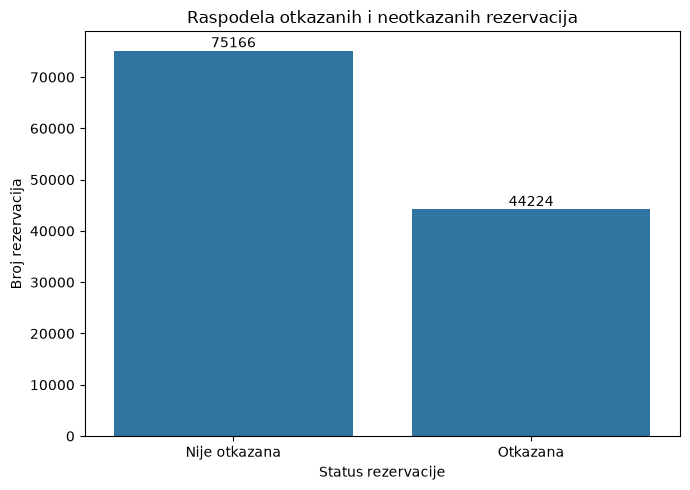

In [14]:
status_order = [
    "Nije otkazana",
    "Otkazana"
]

target_counts = (
    eda_df["status_otkazivanja"]
    .value_counts()
    .reindex(status_order)
)

target_percentages = (
    eda_df["status_otkazivanja"]
    .value_counts(normalize=True)
    .reindex(status_order) * 100
)

target_summary = pd.DataFrame({
    "Broj rezervacija": target_counts,
    "Procenat rezervacija": target_percentages
}).round(2)

display(target_summary)

plt.figure(figsize=(7, 5))

ax = sb.countplot(
    data=eda_df,
    x="status_otkazivanja",
    order=status_order
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Raspodela otkazanih i neotkazanih rezervacija")
plt.xlabel("Status rezervacije")
plt.ylabel("Broj rezervacija")
plt.tight_layout()
plt.show()

U skupu preovlađuju neotkazane rezervacije, kojih ima 75.166 (62,96%), dok su 44.224 rezervacije otkazane (37,04%). Obe klase zastupljene su u dovoljnom broju za dalje poređenje.


### 4.2. Bivarijantna analiza

#### 4.2.1. Tip hotela i otkazivanje

Promenljiva `hotel` razlikuje `City Hotel` i `Resort Hotel`. Proverava se da li se procenat otkazivanja razlikuje između ova dva tipa hotela.


,hotel,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,City Hotel,79330,66.45,33102,41.73
1,Resort Hotel,40060,33.55,11122,27.76


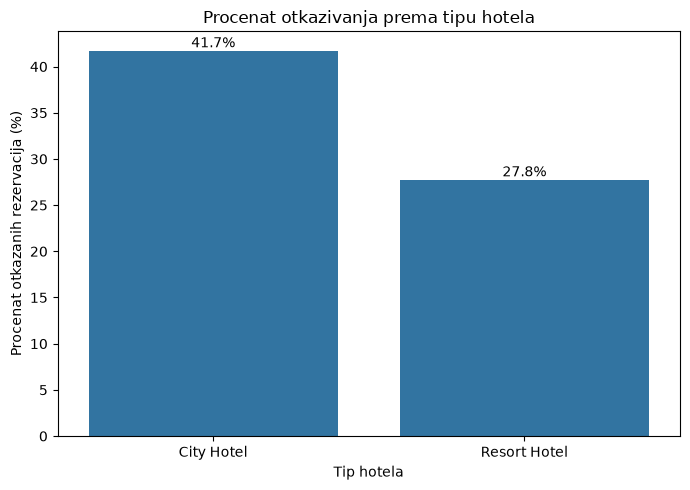

In [15]:
hotel_summary = create_cancellation_summary(eda_df, "hotel")

display(hotel_summary)

plt.figure(figsize=(7, 5))

ax = sb.barplot(
    data=hotel_summary,
    x="hotel",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema tipu hotela")
plt.xlabel("Tip hotela")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

Procenat otkazivanja viši je kod gradskog hotela (41,73%) nego kod resort hotela (27,76%). Gradski hotel je zastupljen sa 79.330 rezervacija, dok resort hotel ima 40.060 rezervacija.


#### 4.2.2. Lead time i otkazivanje

`lead_time` predstavlja broj dana između rezervisanja i planiranog dolaska. Ovde se ispituje njegova povezanost sa statusom otkazivanja. Radi preglednijeg prikaza raspodele, izdvojene vrednosti nisu prikazane na boxplot-u, ali su zadržane u podacima.


,Broj_rezervacija,Prosek,Medijana,Minimum,Maksimum
status_otkazivanja,,,,,
Nije otkazana,75166,79.98,45.0,0,737
Otkazana,44224,144.85,113.0,0,629


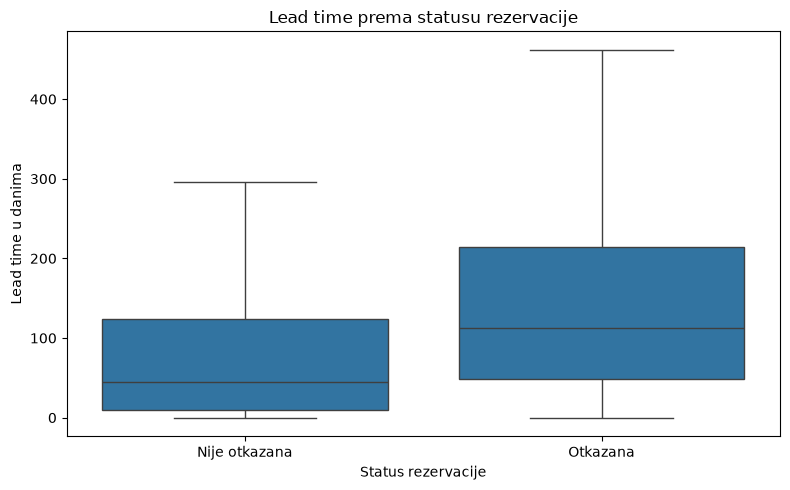

In [16]:
lead_time_statistics = (
    eda_df.groupby("status_otkazivanja")["lead_time"]
    .agg(
        Broj_rezervacija="count",
        Prosek="mean",
        Medijana="median",
        Minimum="min",
        Maksimum="max"
    ).round(2)
)

display(lead_time_statistics)


plt.figure(figsize=(8, 5))

sb.boxplot(
    data=eda_df,
    x="status_otkazivanja",
    y="lead_time",
    showfliers=False
)

plt.title("Lead time prema statusu rezervacije")
plt.xlabel("Status rezervacije")
plt.ylabel("Lead time u danima")
plt.tight_layout()
plt.show()

Otkazane rezervacije imaju veći `lead_time` od neotkazanih rezervacija. Medijana iznosi 113 dana kod otkazanih, dok je kod neotkazanih 45 dana. Boxplot pokazuje da su vrednosti `lead_time` kod otkazanih rezervacija raspoređene u širem opsegu, što ukazuje na veću varijabilnost u odnosu na neotkazane rezervacije.

Pored pojedinačnih vrednosti, `lead_time` je podeljen u nekoliko intervala kako bi se lakše uočilo kako se procenat otkazivanja menja sa dužinom perioda između rezervisanja i planiranog dolaska.

,lead_time_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,0-30 dana,38706,32.42,7185,18.56
1,31-90 dana,29553,24.75,11141,37.70
2,91-180 dana,26439,22.15,11821,44.71
3,181-365 dana,21544,18.05,11947,55.45
4,Više od 365 dana,3148,2.64,2130,67.66


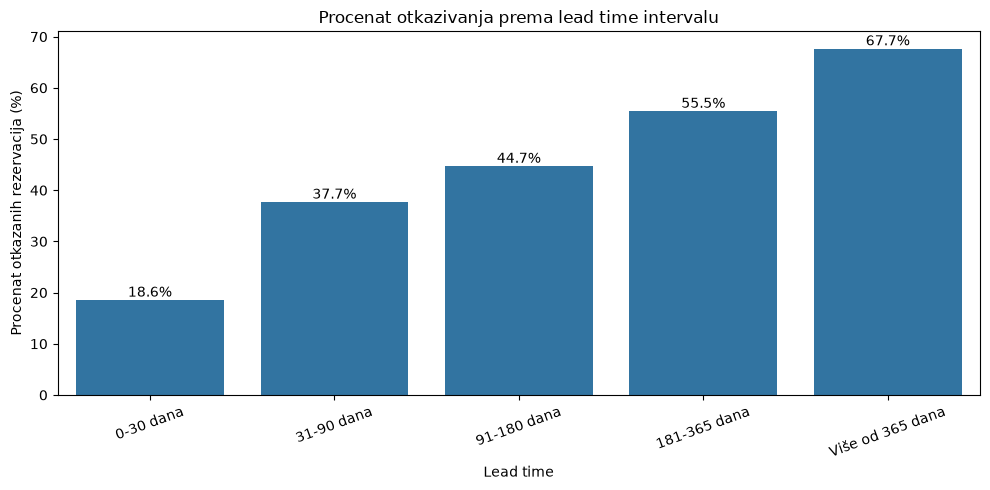

In [17]:
lead_time_bins = [
    -1,
    30,
    90,
    180,
    365,
    np.inf
]

lead_time_labels = [
    "0-30 dana",
    "31-90 dana",
    "91-180 dana",
    "181-365 dana",
    "Više od 365 dana"
]

eda_df["lead_time_group"] = pd.cut(
    eda_df["lead_time"],
    bins=lead_time_bins,
    labels=lead_time_labels
)

lead_time_group_summary = create_cancellation_summary(
    eda_df,
    "lead_time_group"
)

display(lead_time_group_summary)

plt.figure(figsize=(10, 5))

ax = sb.barplot(
    data=lead_time_group_summary,
    x="lead_time_group",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.title("Procenat otkazivanja prema lead time intervalu")
plt.xlabel("Lead time")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Rezultati pokazuju da procenat otkazivanja raste sa povećanjem promenljive `lead_time`. Najniži procenat zabeležen je kod rezervacija napravljenih najviše 30 dana unapred (18,56%), dok je najviši u grupi sa više od 365 dana (67,66%). Poslednja grupa je najmanje zastupljena, ali u njoj postoji najveći udeo otkazanih rezervacija.


#### 4.2.3. Tip depozita i otkazivanje

Tip depozita može biti povezan sa odlukom gosta da odustane od rezervacije, pa se porede zastupljenost i procenat otkazivanja za svaku kategoriju.
- `No Deposit` – Rezervacija je napravljena bez zahteva za uplatu depozita prilikom rezervisanja.
- `Non Refund` – Rezervacija je povezana sa uslovima koji ne predviđaju povraćaj uplaćenog depozita u slučaju otkazivanja.
- `Refundable` – Rezervacija je napravljena uz depozit koji može biti vraćen pod određenim uslovima.


,deposit_type,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Non Refund,14587,12.22,14494,99.36
1,No Deposit,104641,87.65,29694,28.38
2,Refundable,162,0.14,36,22.22


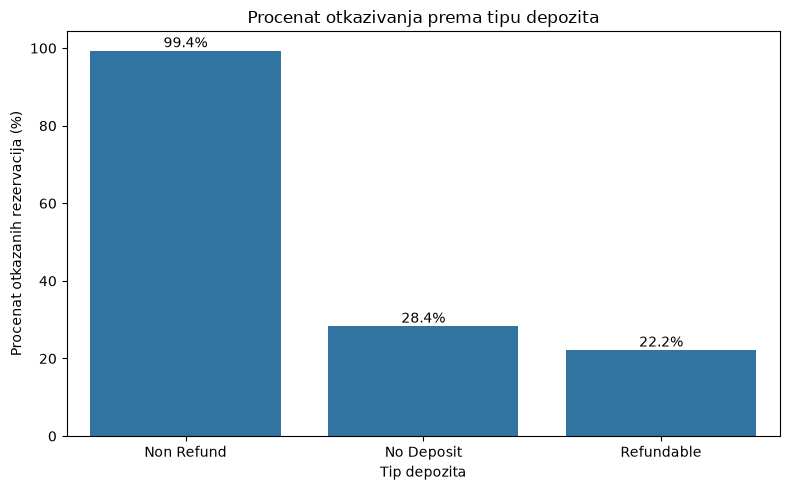

In [18]:
deposit_summary = (
    create_cancellation_summary(
        eda_df,
        "deposit_type"
    )
    .sort_values(
        "Procenat otkazanih rezervacija",
        ascending=False
    ).reset_index(drop=True)
)

display(deposit_summary)

plt.figure(figsize=(8, 5))

ax = sb.barplot(
    data=deposit_summary,
    x="deposit_type",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema tipu depozita")
plt.xlabel("Tip depozita")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

Rezervacije sa depozitom `Non Refund` izdvajaju se veoma visokim procentom otkazivanja od 99,36%. Ovaj rezultat deluje neuobičajeno, ali njegov razlog nije moguće utvrditi samo na osnovu dostupnih podataka. Kod rezervacija bez depozita procenat otkazivanja iznosi 28,38%, dok kategorija `Refundable` ima 22,22% otkazivanja, ali obuhvata svega 162 rezervacije. Rezultati pokazuju izraženu povezanost između tipa depozita i statusa otkazivanja, bez pretpostavljanja uzročnog odnosa.


#### 4.2.4. Tržišni segment i kanal rezervacije

Kolona `market_segment` opisuje tržišni segment iz kog rezervacija potiče. Kategorije su:

- **Direct** – rezervacija je izvršena direktno kod hotela;
- **Online TA** – rezervacija je stigla preko internet turističke agencije;
- **Offline TA/TO** – rezervacija je stigla preko klasične turističke agencije ili turoperatora;
- **Corporate** – rezervacija je povezana sa poslovnim klijentima ili kompanijama;
- **Groups** – grupne rezervacije;
- **Complementary** – besplatne ili promotivne rezervacije;
- **Aviation** – rezervacije povezane sa avio-kompanijama ili njihovim posadama;
- **Undefined** – segment nije definisan u podacima.

Nakon ovog objašnjenja prikazuju se zastupljenost i procenat otkazivanja po tržišnom segmentu.


,market_segment,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Undefined,2,0.00,2,100.00
1,Groups,19811,16.59,12097,61.06
2,Online TA,56477,47.30,20739,36.72
3,Offline TA/TO,24219,20.29,8311,34.32
4,Aviation,237,0.20,52,21.94
5,Corporate,5295,4.44,992,18.73
6,Direct,12606,10.56,1934,15.34
7,Complementary,743,0.62,97,13.06


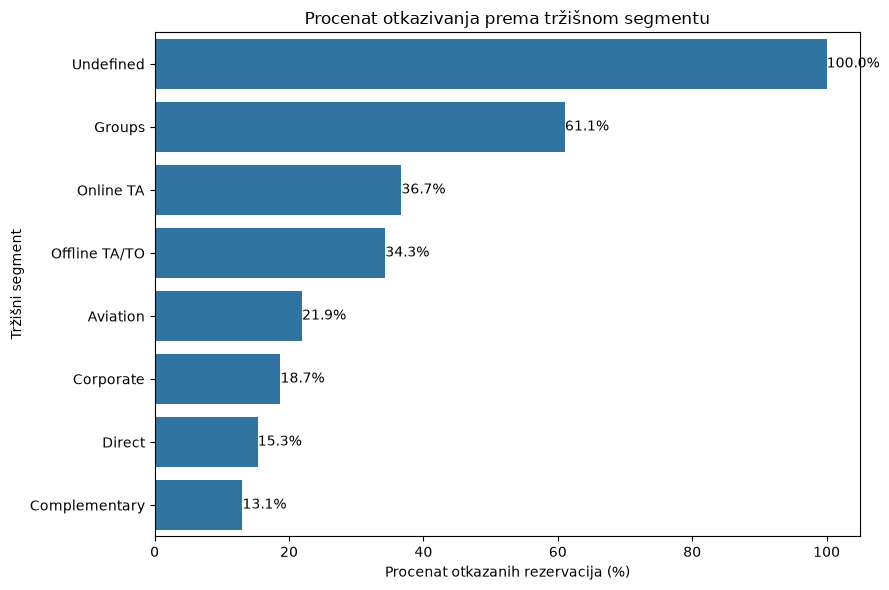

In [19]:
market_segment_summary = (
    create_cancellation_summary(
        eda_df,
        "market_segment"
    )
    .sort_values(
        "Procenat otkazanih rezervacija",
        ascending=False
    )
    .reset_index(drop=True)
)

display(market_segment_summary)


plt.figure(figsize=(9, 6))

ax = sb.barplot(
    data=market_segment_summary,
    y="market_segment",
    x="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema tržišnom segmentu")
plt.xlabel("Procenat otkazanih rezervacija (%)")
plt.ylabel("Tržišni segment")
plt.tight_layout()
plt.show()

Najveći procenat otkazivanja ima kategorija `Undefined`, ali ona sadrži samo dve rezervacije i zato nije reprezentativna. Među zastupljenijim segmentima najveći procenat otkazivanja ima `Groups` (61,06%), zatim `Online TA` (36,72%) i `Offline TA/TO` (34,32%). Najniži procenat zabeležen je kod segmenata `Direct` (15,34%) i `Complementary` (13,06%). Rezultati pokazuju da se procenat otkazivanja razlikuje između tržišnih segmenata.

Kolona `distribution_channel` opisuje kanal preko kog je rezervacija stigla do hotela. Kategorije obuhvataju direktni kanal, `TA/TO`, korporativni kanal, `GDS` (Global Distribution System) i `Undefined`. Sledeći grafikon prikazuje procenat otkazivanja po tim kategorijama.


,distribution_channel,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Undefined,5,0.00,4,80.00
1,TA/TO,97870,81.98,40152,41.03
2,Corporate,6677,5.59,1474,22.08
3,GDS,193,0.16,37,19.17
4,Direct,14645,12.27,2557,17.46


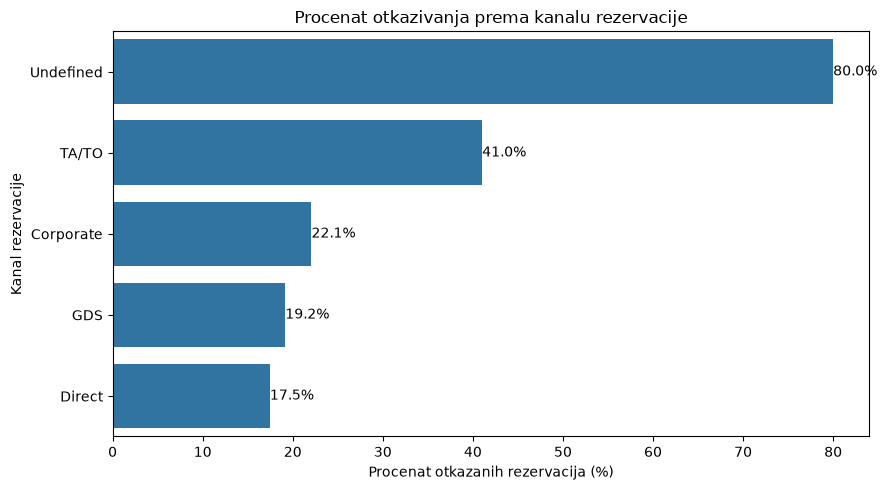

In [20]:
distribution_channel_summary = (
    create_cancellation_summary(
        eda_df,
        "distribution_channel"
    )
    .sort_values(
        "Procenat otkazanih rezervacija",
        ascending=False
    )
    .reset_index(drop=True)
)

display(distribution_channel_summary)


plt.figure(figsize=(9, 5))

ax = sb.barplot(
    data=distribution_channel_summary,
    y="distribution_channel",
    x="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema kanalu rezervacije")
plt.xlabel("Procenat otkazanih rezervacija (%)")
plt.ylabel("Kanal rezervacije")
plt.tight_layout()
plt.show()

Zbog veoma malog broja rezervacija kategorija `Undefined` nije pogodna za izvođenje zaključaka. Kod ostalih kanala distribucije najveći procenat otkazivanja ima `TA/TO`, dok `Direct` ima najmanji. Rezultati pokazuju da se procenat otkazivanja razlikuje između kanala preko kojih su rezervacije stigle do hotela.

#### 4.2.5. Prethodno ponašanje gosta

Promenljiva `is_repeated_guest` razlikuje novog i ponovljenog gosta. Prethodna otkazivanja se zatim prikazuju kroz grupe bez prethodnih otkazivanja, sa jednim i sa dva ili više otkazivanja. Prethodno realizovane rezervacije grupisane su kao 0, 1, 2–5 i 6 ili više. Tek nakon ovog objašnjenja prikazuju se grafikoni i tabele.


,repeated_guest_label,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Novi gost,115580,96.81,43672,37.79
1,Ponovljeni gost,3810,3.19,552,14.49


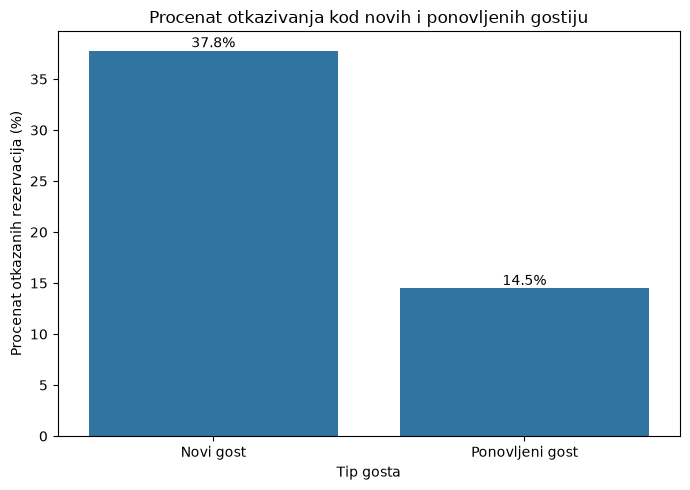

In [21]:
eda_df["repeated_guest_label"] = (
    eda_df["is_repeated_guest"]
    .map({
        0: "Novi gost",
        1: "Ponovljeni gost"
    })
)

repeated_guest_summary = create_cancellation_summary(
    eda_df,
    "repeated_guest_label"
)

display(repeated_guest_summary)


plt.figure(figsize=(7, 5))

ax = sb.barplot(
    data=repeated_guest_summary,
    x="repeated_guest_label",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja kod novih i ponovljenih gostiju")
plt.xlabel("Tip gosta")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

Većinu rezervacija čine novi gosti (96,81%), dok ponovljeni gosti učestvuju sa 3,19%. Kod ponovljenih gostiju procenat otkazivanja iznosi 14,49%, što je znatno manje od 37,79% kod novih gostiju. Rezultati pokazuju da se procenat otkazivanja razlikuje u zavisnosti od toga da li je gost ranije evidentiran kao gost hotela.


,previous_cancellations_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Bez prethodnih otkazivanja,112906,94.57,38282,33.91
1,Jedno prethodno otkazivanje,6051,5.07,5714,94.43
2,Dva ili više,433,0.36,228,52.66


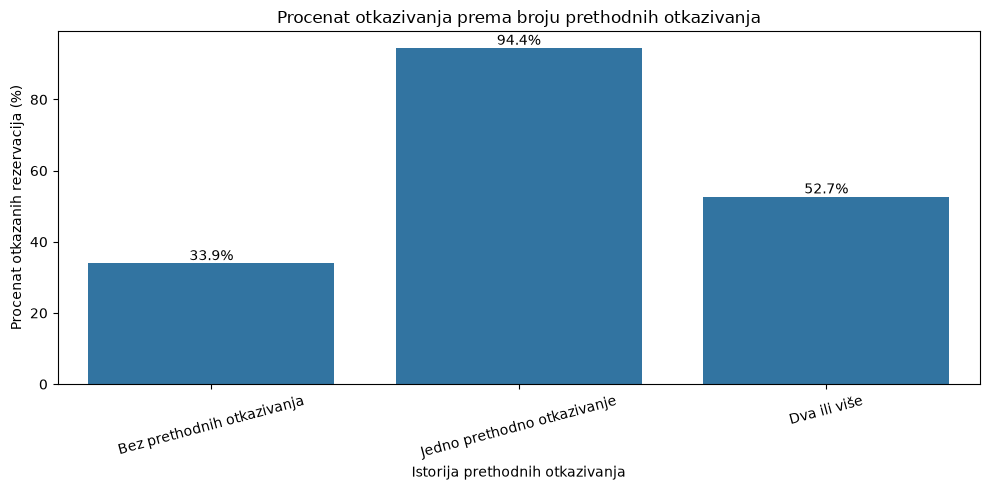

,previous_completed_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,0,115770,96.97,44024,38.03
1,1,1542,1.29,79,5.12
2,2-5,1323,1.11,72,5.44
3,6 ili više,755,0.63,49,6.49


In [22]:
previous_cancellations_bins = [
    -1,
    0,
    1,
    np.inf
]

previous_cancellations_labels = [
    "Bez prethodnih otkazivanja",
    "Jedno prethodno otkazivanje",
    "Dva ili više"
]

eda_df["previous_cancellations_group"] = pd.cut(
    eda_df["previous_cancellations"],
    bins=previous_cancellations_bins,
    labels=previous_cancellations_labels
)

previous_cancellations_summary = create_cancellation_summary(
    eda_df,
    "previous_cancellations_group"
)

display(previous_cancellations_summary)


plt.figure(figsize=(10, 5))

ax = sb.barplot(
    data=previous_cancellations_summary,
    x="previous_cancellations_group",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema broju prethodnih otkazivanja")
plt.xlabel("Istorija prethodnih otkazivanja")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

previous_completed_bins = [
    -1,
    0,
    1,
    5,
    np.inf
]

previous_completed_labels = [
    "0",
    "1",
    "2-5",
    "6 ili više"
]

eda_df["previous_completed_group"] = pd.cut(
    eda_df["previous_bookings_not_canceled"],
    bins=previous_completed_bins,
    labels=previous_completed_labels
)

previous_completed_summary = create_cancellation_summary(
    eda_df,
    "previous_completed_group"
)

display(previous_completed_summary)

Većina rezervacija (94,57%) nema prethodnih otkazivanja, a u toj grupi procenat otkazivanja iznosi 33,91%. Kod gostiju sa jednim prethodnim otkazivanjem procenat raste na 94,43%. Grupa sa dva ili više prethodnih otkazivanja obuhvata 433 rezervacije i znatno je manja od ostalih grupa. Rezultati pokazuju izraženu razliku u procentu otkazivanja u zavisnosti od istorije prethodnih otkazivanja.

Sličan obrazac uočava se i kod prethodno realizovanih rezervacija. Gosti bez prethodno realizovanih rezervacija imaju procenat otkazivanja od 38,03%, dok se kod gostiju sa jednom ili više prethodno realizovanih rezervacija taj procenat kreće od 5,12% do 6,49%. Iako ove grupe obuhvataju mali deo skupa, njihov procenat otkazivanja znatno je niži.


#### 4.2.6. Posebni zahtevi i promene rezervacije

`total_of_special_requests` predstavlja broj posebnih zahteva gosta. `booking_changes` se za prikaz grupiše na rezervacije bez promena, sa jednom promenom i sa dve ili više promena. U nastavku se njihov odnos sa otkazivanjem prikazuje tek nakon objašnjenja kategorija.


,total_of_special_requests,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,0,70318,58.90,33556,47.72
1,1,33226,27.83,7318,22.02
2,2,12969,10.86,2866,22.10
3,3,2497,2.09,446,17.86
4,4,340,0.28,36,10.59
5,5,40,0.03,2,5.00


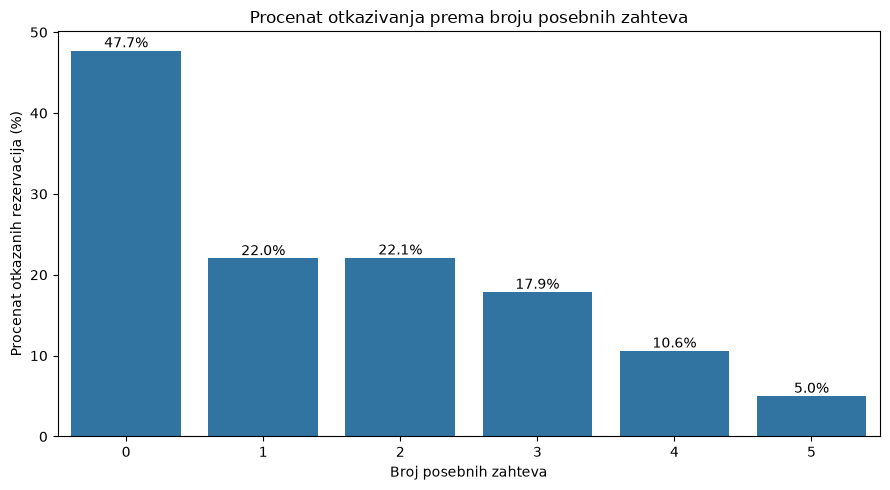

In [23]:
special_requests_summary = create_cancellation_summary(
    eda_df,
    "total_of_special_requests"
)

display(special_requests_summary)

plt.figure(figsize=(9, 5))

ax = sb.barplot(
    data=special_requests_summary,
    x="total_of_special_requests",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema broju posebnih zahteva")
plt.xlabel("Broj posebnih zahteva")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

Rezultati pokazuju da se sa povećanjem broja posebnih zahteva uglavnom smanjuje procenat otkazivanja. Kod rezervacija bez posebnih zahteva otkazano je 47,72%, dok kod rezervacija sa tri, četiri i pet zahteva procenat iznosi 17,86%, 10,59% i 5,00%. Poslednje dve grupe sadrže mali broj rezervacija, pa njihove procente treba tumačiti oprezno.


,booking_changes_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Bez promena,101314,84.86,41391,40.85
1,Jedna promena,12701,10.64,1807,14.23
2,Dve ili više promena,5375,4.50,1026,19.09


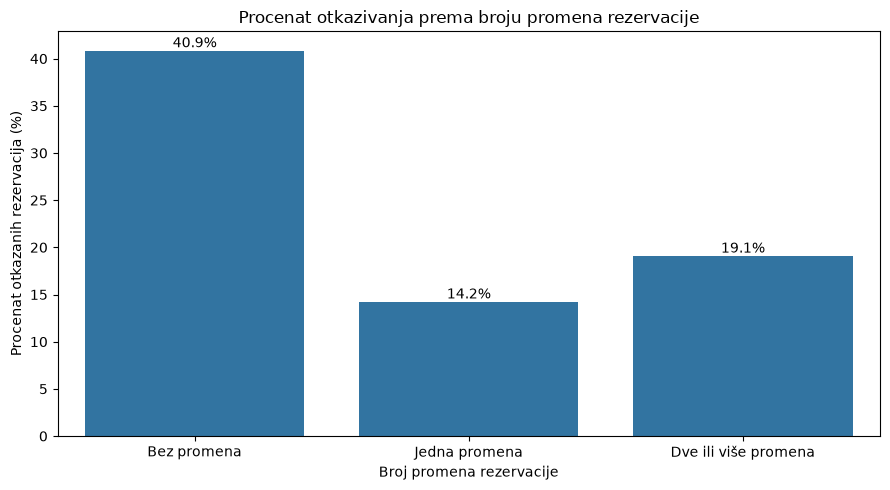

In [24]:
booking_changes_bins = [
    -1,
    0,
    1,
    np.inf
]

booking_changes_labels = [
    "Bez promena",
    "Jedna promena",
    "Dve ili više promena"
]

eda_df["booking_changes_group"] = pd.cut(
    eda_df["booking_changes"],
    bins=booking_changes_bins,
    labels=booking_changes_labels
)

booking_changes_summary = create_cancellation_summary(
    eda_df,
    "booking_changes_group"
)

display(booking_changes_summary)


plt.figure(figsize=(9, 5))

ax = sb.barplot(
    data=booking_changes_summary,
    x="booking_changes_group",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema broju promena rezervacije")
plt.xlabel("Broj promena rezervacije")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.tight_layout()
plt.show()

Najveći deo rezervacija (84,86%) nije imao nijednu promenu nakon rezervisanja, a u toj grupi procenat otkazivanja iznosi 40,85%. Kod rezervacija sa jednom promenom procenat opada na 14,23%, dok kod rezervacija sa dve ili više promena iznosi 19,09%. Iako je procenat u poslednjoj grupi viši nego kod rezervacija sa jednom promenom, i dalje je znatno niži nego kod rezervacija bez promena.


#### 4.2.7. ADR i dužina boravka

`adr` predstavlja prosečnu dnevnu cenu rezervacije. Ukupan boravak dobija se sabiranjem vikend-noćenja i noćenja radnim danima, a za grafički prikaz se grupiše na: bez noćenja, 1–3, 4–7, 8–14 i više od 14 noćenja. Na boxplot-u su izdvojene vrednosti sakrivene radi preglednosti, ali ostaju u podacima.


,Broj_rezervacija,Prosek,Medijana,Minimum,Maksimum
status_otkazivanja,,,,,
Nije otkazana,75166,99.99,92.5,-6.38,510.0
Otkazana,44224,104.96,96.2,0.00,5400.0


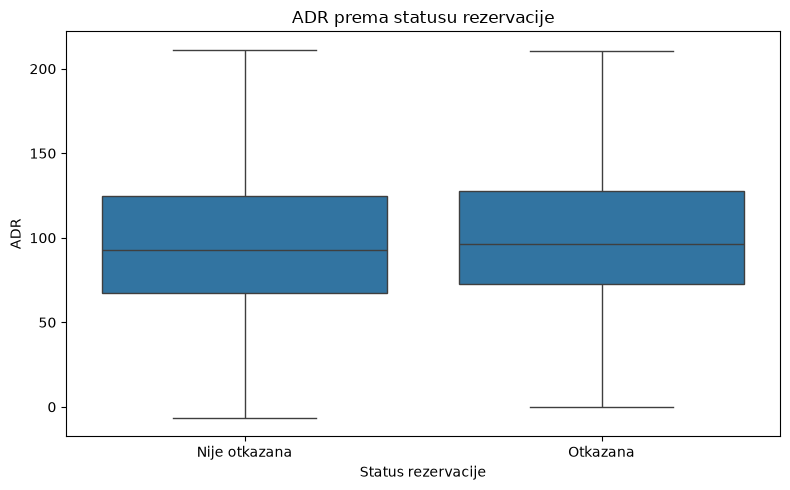

In [25]:
eda_df["total_stay"] = eda_df["stays_in_weekend_nights"] + eda_df["stays_in_week_nights"]

adr_statistics = (
    eda_df.groupby("status_otkazivanja")["adr"]
    .agg(
        Broj_rezervacija="count",
        Prosek="mean",
        Medijana="median",
        Minimum="min",
        Maksimum="max"
    ).round(2)
)

display(adr_statistics)

plt.figure(figsize=(8, 5))

sb.boxplot(
    data=eda_df,
    x="status_otkazivanja",
    y="adr",
    showfliers=False
)

plt.title("ADR prema statusu rezervacije")
plt.xlabel("Status rezervacije")
plt.ylabel("ADR")
plt.tight_layout()
plt.show()

Prosečna i medijalna vrednost ADR-a nešto su veće kod otkazanih rezervacija, ali su razlike male. Boxplot pokazuje da se raspodele u velikoj meri preklapaju, pa se na osnovu same vrednosti ADR-a ne može jasno razlikovati da li će rezervacija biti otkazana.

,total_stay_group,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,Bez noćenja,715,0.60,35,4.90
1,1-3 noćenja,75739,63.44,28785,38.01
2,4-7 noćenja,37679,31.56,13525,35.90
3,8-14 noćenja,4818,4.04,1636,33.96
4,Više od 14 noćenja,439,0.37,243,55.35


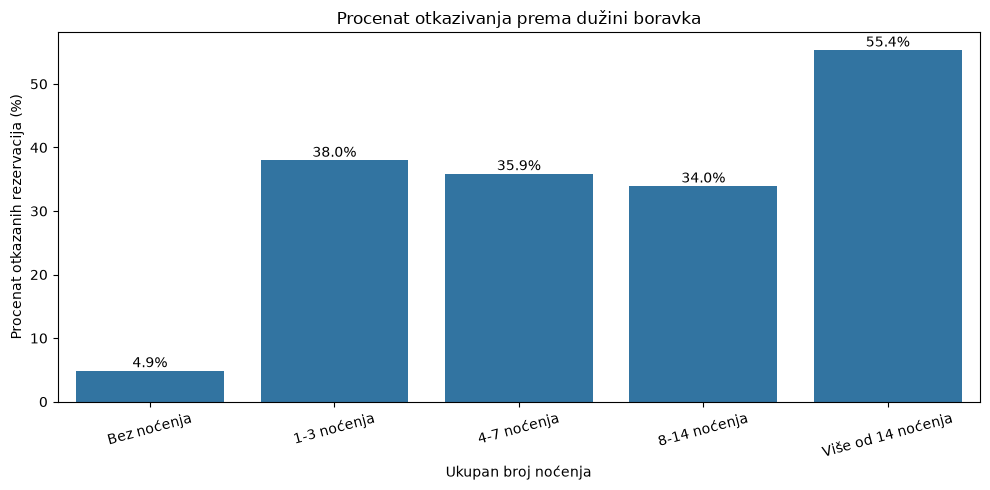

In [26]:
total_stay_bins = [
    -1,
    0,
    3,
    7,
    14,
    np.inf
]

total_stay_labels = [
    "Bez noćenja",
    "1-3 noćenja",
    "4-7 noćenja",
    "8-14 noćenja",
    "Više od 14 noćenja"
]

eda_df["total_stay_group"] = pd.cut(
    eda_df["total_stay"],
    bins=total_stay_bins,
    labels=total_stay_labels
)

total_stay_summary = create_cancellation_summary(
    eda_df,
    "total_stay_group"
)

display(total_stay_summary)

plt.figure(figsize=(10, 5))

ax = sb.barplot(
    data=total_stay_summary,
    x="total_stay_group",
    y="Procenat otkazanih rezervacija"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Procenat otkazivanja prema dužini boravka")
plt.xlabel("Ukupan broj noćenja")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Najveći deo rezervacija odnosi se na boravke od 1 do 3 noćenja (63,44%) i od 4 do 7 noćenja (31,56%). Procenat otkazivanja u tim grupama iznosi 38,01% i 35,90%. Rezervacije bez noćenja imaju 4,90% otkazivanja i čine 0,60% skupa. Najviši procenat otkazivanja zabeležen je kod boravaka dužih od 14 noćenja (55,35%), ali ta grupa obuhvata samo 439 rezervacija. Duži boravci mogu biti povezani sa većim procentom otkazivanja, ali su takvi slučajevi retki.


### 4.3. Multivarijantna analiza




### 4.4. Zaključak eksplorativne analize

Eksplorativna analiza pokazala je da su neotkazane rezervacije zastupljenije u skupu, ali da obe klase sadrže dovoljno zapisa za dalje poređenje. Najizraženije razlike u procentu otkazivanja uočene su kod tipa depozita, tržišnog segmenta, istorije prethodnih rezervacija i broja posebnih zahteva.

Ponovljeni gosti i gosti sa ranije realizovanim rezervacijama ređe su otkazivali rezervacije od novih gostiju i gostiju bez prethodno realizovanih rezervacija. Sa druge strane, kod gostiju sa prethodnim otkazivanjem zabeležen je veći procenat ponovnog otkazivanja. Rezervacije sa posebnim zahtevima ili naknadnim promenama takođe su ređe otkazivane od rezervacija bez takvih aktivnosti.

Izražena razlika uočena je kod promenljive `lead_time`. Medijana iznosi 45 dana kod neotkazanih i 113 dana kod otkazanih rezervacija, a procenat otkazivanja raste u grupama sa dužim periodom između rezervisanja i planiranog dolaska. Vrednosti ADR-a su, sa druge strane, veoma slične kod otkazanih i neotkazanih rezervacija, pa ova promenljiva sama po sebi ne razdvaja jasno dve grupe. Postojeći prikaz meseca i godine dolaska izdvojen je u poglavlje 6.

Statističke provere izdvojene su posle vremenske podele u poglavlje 8.5, kako ne bi bile deo pre-split obrade za modeliranje.

Dobijeni rezultati opisuju obrasce i povezanosti u posmatranom skupu, ali ne dokazuju da pojedine karakteristike uzrokuju otkazivanje. Takođe, na osnovu same eksplorativne analize ne može se zaključiti koliko će svaka promenljiva doprineti budućem modelu. To će biti provereno tokom kreiranja novih promenljivih, pripreme podataka, treniranja modela i evaluacije njegovih rezultata.


## 5. Dodatna multivarijantna analiza `deposit_type`

Ovo poglavlje povezuje postojeću bivarijantnu analizu tipa depozita iz poglavlja 4.2.3 sa kasnijim višedimenzionalnim rezultatima modela. `deposit_type` se zajedno sa ostalim prediktorima razmatra u analizi važnosti promenljivih (15.8) i analizi grešaka prema grupama rezervacija (15.10.3).

Time je uloga promenljive sagledana u kombinaciji sa ostalim karakteristikama rezervacije, bez uvođenja dodatne pre-split transformacije ili korišćenja rezultata EDA za izbor vremenske granice.


## 6. Formiranje vremenske promenljive i priprema za hronološku podelu

Postojeći deskriptivni prikaz meseca i godine ostaje vezan za `eda_df`. Odvojeno od njega, kompletan `arrival_date` se formira isključivo u `modeling_base_df` i koristi samo za hronološku podelu.


### 6.1. Postojeći prikaz meseca i godine dolaska

`arrival_date_month` sadrži nazive meseci, a `arrival_date_year` godinu planiranog dolaska. Meseci se prikazuju hronološkim redom od januara do decembra; zatim se odvojeno prikazuje obuhvat godina.


,arrival_date_month,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,January,5929,4.97,1807,30.48
1,February,8068,6.76,2696,33.42
2,March,9794,8.20,3149,32.15
3,April,11089,9.29,4524,40.80
4,May,11791,9.88,4677,39.67
5,June,10939,9.16,4535,41.46
6,July,12661,10.60,4742,37.45
7,August,13877,11.62,5239,37.75
8,September,10508,8.80,4116,39.17
9,October,11160,9.35,4246,38.05


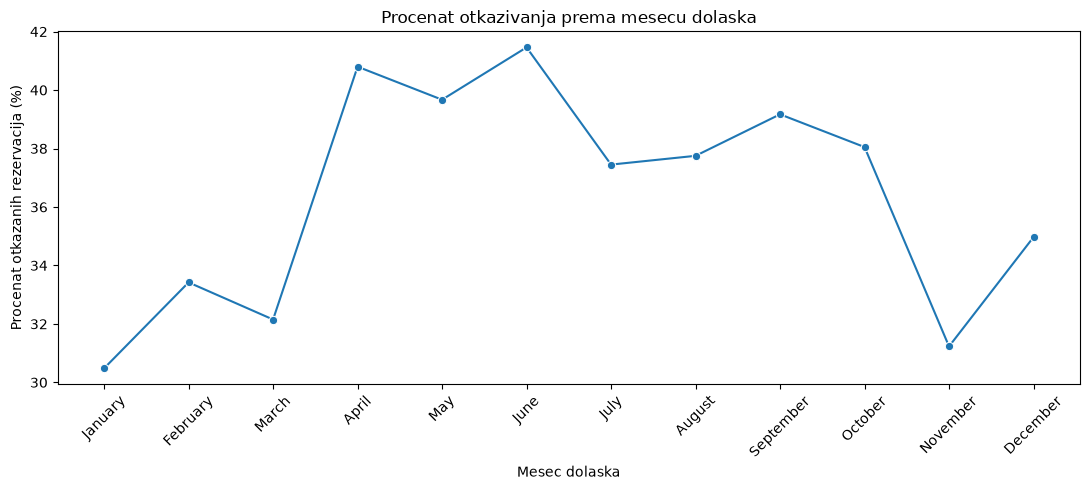

,arrival_date_year,Broj rezervacija,Udeo u ukupnom skupu (%),Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,2015,21996,18.42,8142,37.02
1,2016,56707,47.50,20337,35.86
2,2017,40687,34.08,15745,38.70


,Godina,Broj obuhvaćenih meseci,Obuhvaćeni meseci
0,2015,6,"July, August, September, October, November, De..."
1,2016,12,"January, February, March, April, May, June, Ju..."
2,2017,8,"January, February, March, April, May, June, Ju..."


In [27]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

month_summary = create_cancellation_summary(
    eda_df,
    "arrival_date_month"
)

month_summary["arrival_date_month"] = pd.Categorical(
    month_summary["arrival_date_month"],
    categories=month_order,
    ordered=True
)

month_summary = (
    month_summary
    .sort_values("arrival_date_month")
    .reset_index(drop=True)
)

display(month_summary)

plt.figure(figsize=(11, 5))

sb.lineplot(
    data=month_summary,
    x="arrival_date_month",
    y="Procenat otkazanih rezervacija",
    marker="o"
)

plt.title("Procenat otkazivanja prema mesecu dolaska")
plt.xlabel("Mesec dolaska")
plt.ylabel("Procenat otkazanih rezervacija (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

year_summary = (
    create_cancellation_summary(
        eda_df,
        "arrival_date_year"
    )
    .sort_values("arrival_date_year")
    .reset_index(drop=True)
)

display(year_summary)

year_month_coverage = (
    eda_df
    .groupby("arrival_date_year")
    .agg(
        broj_meseci=(
            "arrival_date_month",
            "nunique"
        ),
        obuhvaceni_meseci=(
            "arrival_date_month",
            lambda values: ", ".join(
                month
                for month in month_order
                if month in set(values)
            )
        )
    )
    .reset_index()
    .rename(columns={
        "arrival_date_year": "Godina",
        "broj_meseci": "Broj obuhvaćenih meseci",
        "obuhvaceni_meseci": "Obuhvaćeni meseci"
    })
)

display(year_month_coverage)

#### Mesec dolaska

Procenat otkazivanja razlikuje se između meseci. Najniže vrednosti zabeležene su u januaru (30,48%), martu (32,15%) i novembru (31,23%), dok su najviše u aprilu (40,80%) i junu (41,46%). Rezultati pokazuju da procenat otkazivanja nije isti tokom cele godine.

#### Godina dolaska

Procenat otkazivanja iznosi 37,02% za 2015, 35,86% za 2016. i 38,70% za 2017. godinu. Godine nisu jednako obuhvaćene: podaci za 2015. počinju u julu, 2016. obuhvata svih dvanaest meseci, dok se podaci za 2017. završavaju u avgustu. Zbog toga se poređenje godina prikazuje opisno i ne koristi se za zaključivanje o dugoročnom rastu ili padu otkazivanja.


### 6.2. Formiranje promenljivih `arrival_date` i `booking_date`

Mesec se prvo mapira na unapred poznat redni broj, a zatim se godina, mesec i dan spajaju u `arrival_date`. Pošto se otkazivanje predviđa odmah nakon kreiranja rezervacije, `booking_date` se dobija oduzimanjem `lead_time` dana od datuma dolaska. Obe transformacije su determinističke i ne koriste ciljnu promenljivu niti statistiku skupa.

`booking_date` će služiti isključivo za hronološko sortiranje i podelu. Neće biti korišćen kao prediktor.


In [28]:
arrival_month_mapping = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12
}

arrival_month_number = modeling_base_df["arrival_date_month"].map(
    arrival_month_mapping
)

assert arrival_month_number.notna().all()

modeling_base_df["arrival_date"] = pd.to_datetime({
    "year": modeling_base_df["arrival_date_year"],
    "month": arrival_month_number,
    "day": modeling_base_df["arrival_date_day_of_month"]
})
modeling_base_df["booking_date"] = (
    modeling_base_df["arrival_date"]
    - pd.to_timedelta(modeling_base_df["lead_time"], unit="D")
)

assert modeling_base_df["arrival_date"].notna().all()
assert modeling_base_df["booking_date"].notna().all()
assert (
    modeling_base_df["booking_date"] <= modeling_base_df["arrival_date"]
).all()
assert len(modeling_base_df) == len(df) - removed_zero_guest_rows

print("Promenljive arrival_date i booking_date su uspešno formirane.")
print(
    "Opseg arrival_date:",
    modeling_base_df["arrival_date"].min().date(),
    "–",
    modeling_base_df["arrival_date"].max().date()
)
print(
    "Opseg booking_date:",
    modeling_base_df["booking_date"].min().date(),
    "–",
    modeling_base_df["booking_date"].max().date()
)


Promenljive arrival_date i booking_date su uspešno formirane.
Opseg arrival_date: 2015-07-01 – 2017-08-31
Opseg booking_date: 2013-06-24 – 2017-08-31


## 7. Hronološka train/test podela

Ovo je jasna granica posle koje budući test period ne sme da utiče na pragove anomalija, imputaciju, skaliranje, enkodovanje, feature selection, izbor modela, hiperparametre ili klasifikacioni prag. Podela se pravi direktno iz `modeling_base_df`, koji potiče iz originalnog `df`, a nikada iz `clean_df`, `model_df` ili EDA objekata.

Prethodna stratifikovana grupna podela potpuno je uklonjena i više se ne koristi. Odnos otkazanih i neotkazanih rezervacija zato se ne izjednačava između vremenskih perioda.


### 7.1. Definisanje trenutka predviđanja

Model predviđa verovatnoću otkazivanja odmah nakon kreiranja rezervacije. Zato se za vremenski redosled koristi `booking_date = arrival_date - lead_time`, jer upravo taj datum predstavlja trenutak u kom su informacije o rezervaciji postale dostupne.

Model sme da koristi samo informacije dostupne u tom trenutku. Kolone `assigned_room_type`, `booking_changes` i `days_in_waiting_list` izostavljaju se iz prediktora zato što mogu nastati ili se menjati nakon kreiranja rezervacije. `booking_date` se koristi samo za sortiranje i podelu, a ne kao prediktorska promenljiva.


### 7.2. Formiranje izvora za vremensku podelu

Rezervacije se sortiraju rastuće prema `booking_date`. Približno prvih 80% starijih rezervacija čini trening skup, a poslednjih približno 20% budućih rezervacija test skup. Granica se određuje samo iz vremenskog redosleda, bez korišćenja `is_canceled`.


In [29]:
target_column = "is_canceled"

columns_unavailable_at_prediction = [
    "assigned_room_type",
    "booking_changes",
    "days_in_waiting_list"
]

split_source_df = modeling_base_df.copy()

assert "arrival_date" in split_source_df.columns
assert "booking_date" in split_source_df.columns
assert split_source_df[["arrival_date", "booking_date"]].notna().all().all()
assert target_column in split_source_df.columns


### 7.3. Hronološka podela približno 80:20

Granica se računa kao `booking_date` na približnoj 80% poziciji sortiranog skupa. Sve rezervacije pre te granice ulaze u trening skup, a rezervacije na granici i posle nje u test skup. Sve rezervacije sa istim datumom kreiranja ostaju na istoj strani, pa konačan odnos može neznatno odstupati od tačno 80:20.


In [30]:
ordered_modeling_base_df = modeling_base_df.sort_values(
    "booking_date",
    kind="stable"
)

nominal_split_position = int(len(ordered_modeling_base_df) * 0.80)
temporal_cutoff_date = ordered_modeling_base_df.iloc[
    nominal_split_position
]["booking_date"]

train_partition_df = ordered_modeling_base_df.loc[
    ordered_modeling_base_df["booking_date"] < temporal_cutoff_date
].copy()
test_partition_df = ordered_modeling_base_df.loc[
    ordered_modeling_base_df["booking_date"] >= temporal_cutoff_date
].copy()

train_booking_dates = train_partition_df["booking_date"].copy()
test_booking_dates = test_partition_df["booking_date"].copy()

# Datumi služe za vremensku podelu. Njihove originalne komponente ostaju
# dostupne kao prediktori, dok booking_date nije prediktorska promenljiva.
date_columns_for_split_only = ["arrival_date", "booking_date"]
train_df = train_partition_df.drop(columns=date_columns_for_split_only)
test_df = test_partition_df.drop(columns=date_columns_for_split_only)

y_split_train = train_df[target_column].copy()
y_split_test = test_df[target_column].copy()

assert not train_df.empty
assert not test_df.empty
assert train_booking_dates.is_monotonic_increasing
assert test_booking_dates.is_monotonic_increasing
assert train_booking_dates.max() < test_booking_dates.min()


Proveravaju se veličina i vremenski opseg oba dela. Ciljna promenljiva nije korišćena za podelu i nije stratifikovana; zato odnos otkazanih i neotkazanih rezervacija ne mora biti isti u različitim vremenskim periodima. Test predstavlja potpuno izdvojen budući period.


In [31]:
total_split_rows = len(modeling_base_df)
temporal_split_summary = pd.DataFrame({
    "Skup": ["Trening", "Test"],
    "Broj rezervacija": [len(train_df), len(test_df)],
    "Udeo skupa (%)": [
        len(train_df) / total_split_rows * 100,
        len(test_df) / total_split_rows * 100
    ],
    "Početak booking perioda": [
        train_booking_dates.min(),
        test_booking_dates.min()
    ],
    "Kraj booking perioda": [
        train_booking_dates.max(),
        test_booking_dates.max()
    ]
})
temporal_split_summary["Udeo skupa (%)"] = (
    temporal_split_summary["Udeo skupa (%)"].round(2)
)

display(temporal_split_summary)

strict_temporal_order = (
    train_booking_dates.max() < test_booking_dates.min()
)

assert len(train_df) + len(test_df) == len(modeling_base_df)
assert set(train_df.index).isdisjoint(test_df.index)
assert strict_temporal_order

print("Vremenska granica izvedena iz 80% pozicije:", temporal_cutoff_date.date())
print(
    "Provera train max < test min:",
    strict_temporal_order,
    f"({train_booking_dates.max().date()} < {test_booking_dates.min().date()})"
)
print("Podela nije stratifikovana prema ciljnoj promenljivoj.")


,Skup,Broj rezervacija,Udeo skupa (%),Početak booking perioda,Kraj booking perioda
0,Trening,95278,79.92,2013-06-24,2017-01-11
1,Test,23932,20.08,2017-01-12,2017-08-31


Vremenska granica izvedena iz 80% pozicije: 2017-01-12
Provera train max < test min: True (2017-01-11 < 2017-01-12)
Podela nije stratifikovana prema ciljnoj promenljivoj.


`train_df` sadrži starije rezervacije, dok `test_df` predstavlja budući, potpuno izdvojeni period. Podela simulira realnu primenu: model se gradi na istorijskim rezervacijama i zatim ocenjuje na rezervacijama kreiranim kasnije.

**Od ovog trenutka svaka statistički vođena odluka uči se samo iz trening skupa.** Test cilj se ne koristi za izbor modela, promenljivih, hiperparametara ili praga klasifikacije.


## 8. Detekcija anomalija i obrada kvaliteta podataka

Sve data-driven provere i odluke nalaze se posle hronološke podele. Granice anomalija određuju se isključivo na trening periodu, a zatim se isto naučeno pravilo bez ponovnog računanja primenjuje na test period.


### 8.1. Provera dupliranih redova

Najpre se proverava da li u skupu postoje potpuno identični redovi. Zatim se provera ponavlja nakon privremenog izostavljanja direktnih identifikatora gostiju i kolona koje opisuju konačni status rezervacije. Druga provera služi samo za uočavanje mogućih ponavljanja i ne menja originalni DataFrame `df`.


In [32]:
duplicate_count = df.loc[train_df.index].duplicated().sum()
duplicate_percentage = duplicate_count / len(train_df) * 100

print(f"Broj potpuno dupliranih redova u trening periodu: {duplicate_count}")
print(f"Procenat potpuno dupliranih redova u trening periodu: {duplicate_percentage:.3f}%")


Broj potpuno dupliranih redova u trening periodu: 0
Procenat potpuno dupliranih redova u trening periodu: 0.000%


#### 8.1.1. Provera bez identifikacionih i statusnih kolona

Potpuni duplikati mogu ostati neprimećeni ako se redovi razlikuju samo po imenu, kontakt podacima ili kolonama statusa. Zato se privremeno izostavljaju kolone `name`, `email`, `phone-number`, `credit_card`, `reservation_status` i `reservation_status_date`, a zatim se traže redovi koji su jednaki po svim preostalim kolonama.

Prikazuju se ukupan broj redova koji pripadaju nekoj ponovljenoj grupi, broj takvih grupa i broj dodatnih ponavljanja preko prvog reda u svakoj grupi. U tabeli su prikazane prve tri grupe, bez prikazivanja samih ličnih podataka. Umesto toga se vidi koliko različitih identifikacionih vrednosti postoji unutar svake grupe.


In [33]:
training_duplicate_df = df.loc[train_df.index].copy()

columns_excluded_from_duplicate_check = [
    "name",
    "email",
    "phone-number",
    "credit_card",
    "reservation_status",
    "reservation_status_date"
]

columns_for_duplicate_check = [
    column
    for column in training_duplicate_df.columns
    if column not in columns_excluded_from_duplicate_check
]

repeated_record_mask = training_duplicate_df.duplicated(
    subset=columns_for_duplicate_check,
    keep=False
)

repeated_records = training_duplicate_df.loc[repeated_record_mask].copy()

additional_repeated_count = training_duplicate_df.duplicated(
    subset=columns_for_duplicate_check,
    keep="first"
).sum()

if not repeated_records.empty:
    repeated_records["Grupa ponavljanja"] = (
        repeated_records
        .groupby(
            columns_for_duplicate_check,
            dropna=False,
            sort=False
        )
        .ngroup()
        + 1
    )

    repeated_group_count = (
        repeated_records["Grupa ponavljanja"].nunique()
    )
    example_group_ids = (
        repeated_records["Grupa ponavljanja"]
        .drop_duplicates()
        .head(3)
    )
    example_rows = repeated_records.loc[
        repeated_records["Grupa ponavljanja"].isin(example_group_ids)
    ]
    repeated_example_summaries = []

    for group_id, group in example_rows.groupby(
        "Grupa ponavljanja",
        sort=False
    ):
        repeated_example_summaries.append({
            "Grupa ponavljanja": group_id,
            "Broj redova": len(group),
            "Indeksi redova": ", ".join(map(str, group.index)),
            "Hotel": group["hotel"].iloc[0],
            "Godina dolaska": group["arrival_date_year"].iloc[0],
            "Mesec dolaska": group["arrival_date_month"].iloc[0],
            "Dan dolaska": group["arrival_date_day_of_month"].iloc[0],
            "Lead time": group["lead_time"].iloc[0],
            "Različita imena": group["name"].nunique(),
            "Različiti email-ovi": group["email"].nunique(),
            "Različiti telefoni": group["phone-number"].nunique(),
            "Različite kartice": group["credit_card"].nunique()
        })

    repeated_examples = pd.DataFrame(repeated_example_summaries)
else:
    repeated_group_count = 0
    repeated_examples = pd.DataFrame()

print(
    "Broj trening zapisa koji imaju najmanje jedno ponavljanje:",
    int(repeated_record_mask.sum())
)
print("Broj grupa ponovljenih trening zapisa:", repeated_group_count)
print(
    "Broj dodatnih ponavljanja preko prvog zapisa u svakoj grupi:",
    int(additional_repeated_count)
)

if repeated_examples.empty:
    print("Nisu pronađeni primeri za prikaz.")
else:
    print("\nPrimeri prve tri grupe ponovljenih zapisa:")
    print(repeated_examples.to_string(index=False))


Broj trening zapisa koji imaju najmanje jedno ponavljanje: 36017
Broj grupa ponovljenih trening zapisa: 6865
Broj dodatnih ponavljanja preko prvog zapisa u svakoj grupi: 29152

Primeri prve tri grupe ponovljenih zapisa:
 Grupa ponavljanja  Broj redova Indeksi redova        Hotel  Godina dolaska Mesec dolaska  Dan dolaska  Lead time  Različita imena  Različiti email-ovi  Različiti telefoni  Različite kartice
                 1            2     890, 15976 Resort Hotel            2015        August            3        460                2                    2                   2                  2
                 2            2   15637, 15638 Resort Hotel            2015          July           20        296                2                    2                   2                  2
                 3            2     1604, 1605 Resort Hotel            2015     September            5        323                2                    2                   2                  2


Nakon izostavljanja šest navedenih kolona, **36.017 trening zapisa** pripada grupama u kojima se preostale vrednosti ponavljaju. Formirano je **6.865 grupa**, odnosno postoji **29.152 dodatna ponavljanja** preko prvog zapisa u svakoj grupi. Primeri pokazuju da redovi mogu imati iste podatke o rezervaciji, a različite identifikacione podatke gosta.

Ovaj rezultat nije dovoljan dokaz da su redovi stvarni duplikati. Skup podataka nema pouzdan jedinstveni identifikator rezervacije, pa dve različite rezervacije mogu imati jednake vrednosti u svim kolonama korišćenim za poređenje. Automatsko uklanjanje moglo bi zato da izbriše validne rezervacije i promeni raspodelu podataka.


#### 8.1.2. Zaključak provere duplikata

Potpuno identični redovi nisu pronađeni. Posle privremenog izostavljanja identifikacionih i statusnih kolona pronađen je veći broj zapisa sa jednakim preostalim vrednostima, ali se bez jedinstvenog identifikatora rezervacije ne može pouzdano utvrditi da li predstavljaju ista rezervisanja ili različite rezervacije sa jednakim karakteristikama. Zbog toga se ovi redovi **ne uklanjaju**, već ostaju u skupu za dalju analizu.


### 8.2. Analiza netipičnih i ekstremnih vrednosti

Osnovna deskriptivna statistika ukazuje na prisustvo vrlo malih, vrlo velikih ili potencijalno nelogičnih vrednosti u pojedinim kolonama. Ovde prvo proveravamo koliko takvih vrednosti ima i u kojim se kolonama pojavljuju, kako bismo kasnije mogli da odlučimo šta sa njima treba uraditi.


#### 8.2.1. Kreiranje pomoćnih promenljivih za proveru

U kopiji `analysis_df` privremeno se računaju `total_guests`, kao zbir odraslih, dece i beba, i `total_stay`, kao zbir noćenja tokom vikenda i radnih dana. Ove promenljive koriste se samo za proveru konzistentnosti i analizu neuobičajenih vrednosti. Originalni `df` ostaje nepromenjen, a podaci u ovoj fazi još nisu očišćeni.


In [34]:
analysis_df = df.loc[train_df.index].copy()

analysis_df["total_guests"] = (
    analysis_df["adults"] + analysis_df["children"].fillna(0) + analysis_df["babies"]
)

analysis_df["total_stay"] = (
    analysis_df["stays_in_weekend_nights"] + analysis_df["stays_in_week_nights"]
)

print(f"Broj kolona u originalnom df: {df.shape[1]}")
print(f"Broj kolona u analysis_df: {analysis_df.shape[1]}")


Broj kolona u originalnom df: 36
Broj kolona u analysis_df: 38


#### 8.2.2. Sistematska provera sumnjivih vrednosti

U nastavku se proveravaju potencijalno nelogične ili veoma retke vrednosti u najvažnijim numeričkim kolonama. Za svaki uslov računa se broj i procenat redova koji ga zadovoljavaju.


In [35]:
unusual_checks = [
    ("Negativna ADR vrednost", analysis_df["adr"] < 0),
    ("ADR veći od 1000", analysis_df["adr"] > 1000),
    ("Rezervacija bez gostiju", analysis_df["total_guests"] == 0),
    ("Rezervacija bez noćenja", analysis_df["total_stay"] == 0),
    ("Boravak duži od 30 noći", analysis_df["total_stay"] > 30),
    ("Lead time duži od 365 dana", analysis_df["lead_time"] > 365),
    ("Više od 10 odraslih gostiju", analysis_df["adults"] > 10),
    ("Više od 5 dece", analysis_df["children"] > 5),
    ("Više od 5 beba", analysis_df["babies"] > 5),
    ("Više od 5 prethodnih otkazivanja", analysis_df["previous_cancellations"] > 5),
    ("Više od 20 prethodnih neotkazanih rezervacija", analysis_df["previous_bookings_not_canceled"] > 20),
    ("Više od 5 izmena rezervacije", analysis_df["booking_changes"] > 5),
    ("Čekanje duže od 100 dana", analysis_df["days_in_waiting_list"] > 100),
    ("Više od 3 potrebna parking mesta", analysis_df["required_car_parking_spaces"] > 3)
]

unusual_values_summary = pd.DataFrame([
    {
        "Provera": description,
        "Broj redova": condition.sum(),
        "Procenat redova": round(condition.sum() / len(analysis_df) * 100, 3)
    }
    for description, condition in unusual_checks
])

unusual_values_summary = unusual_values_summary.sort_values(
    "Broj redova", ascending=False
).reset_index(drop=True)

unusual_values_summary

,Provera,Broj redova,Procenat redova
0,Lead time duži od 365 dana,3147,3.303
1,Čekanje duže od 100 dana,745,0.782
2,Rezervacija bez noćenja,560,0.588
3,Više od 5 prethodnih otkazivanja,189,0.198
4,Više od 5 izmena rezervacije,117,0.123
5,Više od 20 prethodnih neotkazanih rezervacija,88,0.092
6,Boravak duži od 30 noći,20,0.021
7,Više od 10 odraslih gostiju,12,0.013
8,Više od 5 beba,2,0.002
9,Negativna ADR vrednost,1,0.001


Isti zapis može istovremeno pripadati većem broju navedenih grupa, na primer rezervacija može biti i bez gostiju i bez noćenja. Zbog toga se brojevi iz tabele ne sabiraju kao broj različitih problematičnih redova.

#### 8.2.3. Pregled konkretnih primera

Prikazani su primeri najvažnijih sumnjivih vrednosti radi njihovog detaljnijeg pregleda i tumačenja. U svakom prikazu izdvojene su relevantne kolone, a najekstremnije vrednosti prikazane su prve.


In [36]:
adr_extreme_rows = analysis_df[(analysis_df["adr"] < 0) | (analysis_df["adr"] > 1000)]
adr_columns = [
    "hotel", "is_canceled", "adr", "adults", "children",
    "babies", "total_stay", "reservation_status"
]

if adr_extreme_rows.empty:
    print("Nisu pronađeni redovi sa negativnim ADR-om ili ADR-om većim od 1000.")
else:
    display(
        adr_extreme_rows.sort_values(
            "adr", key=lambda values: values.abs(), ascending=False
        )[adr_columns].head(10)
    )

,hotel,is_canceled,adr,adults,children,babies,total_stay,reservation_status
48515,City Hotel,1,5400.00,2,0.0,0,1,Canceled
14969,Resort Hotel,0,-6.38,2,0.0,0,10,Check-Out


U koloni adr izdvajaju se dve vrednosti: jedna negativna i jedna izrazito visoka. Pošto dataset ne sadrži dodatno objašnjenje za ove zapise, nije moguće pouzdano utvrditi da li su u pitanju greške ili validni slučajevi. Zato će se kasnije proveriti gde se nalaze u raspodeli i koliko utiču na prosek i medijanu.

In [37]:
zero_guest_rows = analysis_df[analysis_df["total_guests"] == 0]
guest_columns = [
    "hotel", "is_canceled", "adults", "children", "babies",
    "total_guests", "total_stay", "adr", "reservation_status"
]

if zero_guest_rows.empty:
    print("Nisu pronađene rezervacije bez gostiju.")
else:
    display(
        zero_guest_rows.sort_values(
            ["total_stay", "adr"], ascending=False
        )[guest_columns].head(10)
    )

Nisu pronađene rezervacije bez gostiju.


U ovom prikazu nisu pronađene rezervacije bez evidentiranih gostiju. To je očekivano, jer je 180 takvih zapisa prethodno uklonjeno iz `modeling_base_df` unapred definisanim pravilom u poglavlju 3.3. Ova provera ne donosi novu odluku o uklanjanju podataka.


##### Rezervacije bez noćenja

To su rezervacije kod kojih je zbir kolona `stays_in_weekend_nights` i `stays_in_week_nights` jednak nuli. Pre donošenja odluke o njihovoj obradi potrebno je proveriti status rezervacije, broj gostiju i ADR.


In [38]:
zero_stay_rows = analysis_df[analysis_df["total_stay"] == 0]
zero_stay_columns = [
    "hotel", "is_canceled", "stays_in_weekend_nights",
    "stays_in_week_nights", "total_stay", "total_guests",
    "adr", "reservation_status", "reservation_status_date"
]

if zero_stay_rows.empty:
    print("Nisu pronađene rezervacije bez noćenja.")
else:
    display(
        zero_stay_rows.sort_values(
            ["is_canceled", "adr"], ascending=[False, False]
        )[zero_stay_columns].head(10)
    )

,hotel,is_canceled,stays_in_weekend_nights,stays_in_week_nights,total_stay,total_guests,adr,reservation_status,reservation_status_date
19503,Resort Hotel,1,0,0,0,2.0,0.0,No-Show,2015-12-23
19823,Resort Hotel,1,0,0,0,2.0,0.0,No-Show,2016-01-04
83165,City Hotel,1,0,0,0,2.0,0.0,No-Show,2016-01-22
84188,City Hotel,1,0,0,0,2.0,0.0,Canceled,2016-02-20
85903,City Hotel,1,0,0,0,2.0,0.0,No-Show,2016-03-23
46856,City Hotel,1,0,0,0,1.0,0.0,Canceled,2016-01-22
22970,Resort Hotel,1,0,0,0,1.0,0.0,Canceled,2016-04-12
83564,City Hotel,1,0,0,0,1.0,0.0,No-Show,2016-02-06
84488,City Hotel,1,0,0,0,1.0,0.0,No-Show,2016-02-26
84457,City Hotel,1,0,0,0,1.0,0.0,No-Show,2016-02-26


Rezervacije bez noćenja ne mogu se automatski smatrati greškom. Njihovo značenje zavisi od statusa rezervacije, pa će se proveriti koliko među njima ima otkazanih, realizovanih i `No-Show` rezervacija, kao i da li imaju evidentirane goste i ADR vrednost.

In [39]:
guest_extreme_rows = analysis_df[
    (analysis_df["adults"] > 10)
    | (analysis_df["children"] > 5)
    | (analysis_df["babies"] > 5)
]
guest_extreme_columns = [
    "hotel", "is_canceled", "adults", "children", "babies",
    "total_guests", "total_stay", "adr"
]

if guest_extreme_rows.empty:
    print("Nisu pronađene rezervacije sa veoma velikim brojem gostiju.")
else:
    display(
        guest_extreme_rows.sort_values(
            "total_guests", ascending=False
        )[guest_extreme_columns]
    )

,hotel,is_canceled,adults,children,babies,total_guests,total_stay,adr
2173,Resort Hotel,1,55,0.0,0,55.0,2,0.00
1643,Resort Hotel,1,50,0.0,0,50.0,3,0.00
1539,Resort Hotel,1,40,0.0,0,40.0,3,0.00
1962,Resort Hotel,1,27,0.0,0,27.0,4,0.00
1917,Resort Hotel,1,27,0.0,0,27.0,4,0.00
1752,Resort Hotel,1,26,0.0,0,26.0,7,0.00
1587,Resort Hotel,1,26,0.0,0,26.0,7,0.00
2003,Resort Hotel,1,26,0.0,0,26.0,7,0.00
1884,Resort Hotel,1,26,0.0,0,26.0,7,0.00
2164,Resort Hotel,1,26,0.0,0,26.0,7,0.00


U malom broju rezervacija evidentiran je neuobičajeno veliki broj gostiju. Pošto takvi slučajevi mogu predstavljati i validne grupne rezervacije, nije ih moguće automatski smatrati greškom. Zbog toga će se prilikom čišćenja podataka uzeti u obzir i ostale informacije iz rezervacije kako bi se donela odgovarajuća odluka.

In [40]:
long_lead_time_rows = analysis_df[analysis_df["lead_time"] > 365]
long_waiting_rows = analysis_df[analysis_df["days_in_waiting_list"] > 100]

time_columns = [
    "hotel",
    "is_canceled",
    "lead_time",
    "days_in_waiting_list",
    "deposit_type",
    "market_segment",
    "reservation_status"
]

print("Primeri rezervacija sa lead_time dužim od 365 dana:")

if long_lead_time_rows.empty:
    print("Nisu pronađene takve rezervacije.")
else:
    display(
        long_lead_time_rows
        .sort_values("lead_time", ascending=False)
        [time_columns]
        .head(5)
    )

print("\nPrimeri rezervacija sa čekanjem dužim od 100 dana:")

if long_waiting_rows.empty:
    print("Nisu pronađene takve rezervacije.")
else:
    display(
        long_waiting_rows
        .sort_values("days_in_waiting_list", ascending=False)
        [time_columns]
        .head(5)
    )

Primeri rezervacija sa lead_time dužim od 365 dana:


,hotel,is_canceled,lead_time,days_in_waiting_list,deposit_type,market_segment,reservation_status
1,Resort Hotel,0,737,0,No Deposit,Direct,Check-Out
4182,Resort Hotel,0,709,0,No Deposit,Direct,Check-Out
65245,City Hotel,1,629,0,Non Refund,Groups,Canceled
65244,City Hotel,1,629,0,Non Refund,Groups,Canceled
65243,City Hotel,1,629,0,Non Refund,Groups,Canceled



Primeri rezervacija sa čekanjem dužim od 100 dana:


,hotel,is_canceled,lead_time,days_in_waiting_list,deposit_type,market_segment,reservation_status
59085,City Hotel,1,457,391,Non Refund,Groups,Canceled
59084,City Hotel,1,457,391,Non Refund,Groups,Canceled
59077,City Hotel,1,457,391,Non Refund,Groups,Canceled
59076,City Hotel,1,457,391,Non Refund,Groups,Canceled
58179,City Hotel,1,443,391,Non Refund,Groups,Canceled


Veliki `lead_time` i dugo zadržavanje na listi čekanja predstavljaju retke, ali moguće vrednosti i zato se ne uklanjaju automatski. Njihova povezanost sa otkazivanjem prikazana je u detaljnijem poređenju u poglavlju 8.3.5.


#### 8.2.4. Zaključak početne provere

Analizom su pronađene potencijalno nelogične vrednosti, kao što su negativan ADR, rezervacije bez evidentiranih gostiju i rezervacije bez noćenja. Uočene su i retke, ali moguće vrednosti u kolonama `lead_time`, `days_in_waiting_list`, broju gostiju i trajanju boravka.

U ovom delu nijedan zapis nije uklonjen niti izmenjen. Sledeći korak biće detaljnija analiza izdvojenih vrednosti: proveriće se njihova raspodela, status rezervacije, odnos sa ciljnom promenljivom `is_canceled` i uticaj na osnovne statističke pokazatelje. Na osnovu tih rezultata biće donete i obrazložene odluke o tome koje vrednosti ostaju, koje se uklanjaju i koje se obrađuju na drugi način.


### 8.3. Detaljnija analiza izdvojenih vrednosti

Cilj ovog dela je da se konkretno analiziraju najvažnije vrednosti izdvojene u prethodnom segmentu, pre donošenja odluka o čišćenju podataka. Analiza se nastavlja nad prethodno kreiranim `analysis_df`, koji sadrži pomoćne kolone, dok originalni `df` ostaje neizmenjen.


#### 8.3.1. Određivanje ADR granica na trening skupu

ADR granice se određuju konzervativnim Tukey pravilom sa tri interkvartilna raspona, koristeći isključivo rezervacije iz trening perioda. Donja granica se dodatno ograničava na nulu, jer negativna cena nema uobičajeno poslovno značenje. Test podaci ne utiču na kvartile, IQR niti granice.


ADR Q1 na trening skupu: 65.5
ADR Q3 na trening skupu: 117.3
ADR IQR na trening skupu: 51.8
Granice naučene na trening skupu: 0.0 do 272.7


,Broj zapisa,Prosečna vrednost,Medijana,Standardna devijacija,Minimum,Maksimum
Trening – svi zapisi,95278,95.92,90.0,46.74,-6.38,5400.0
Trening – bez ADR anomalija,95015,95.30,90.0,42.13,0.00,272.7


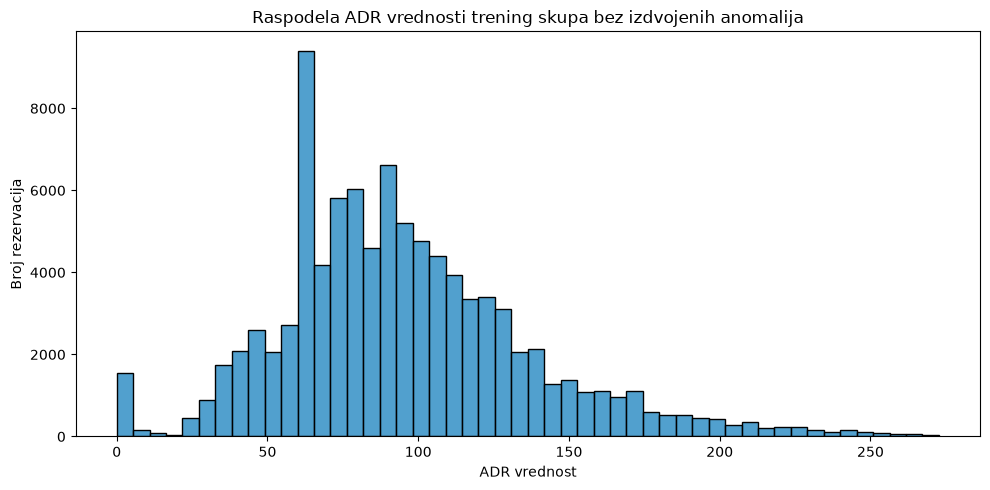

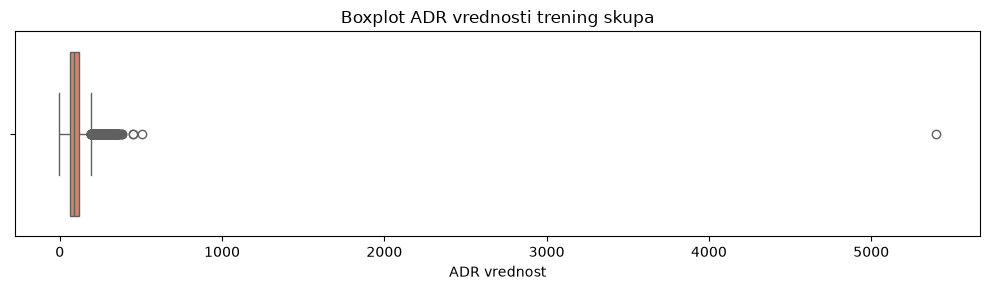

In [41]:
adr_training_values = analysis_df["adr"].dropna()
adr_first_quartile = adr_training_values.quantile(0.25)
adr_third_quartile = adr_training_values.quantile(0.75)
adr_iqr = adr_third_quartile - adr_first_quartile

adr_lower_bound = max(
    0.0,
    adr_first_quartile - 3.0 * adr_iqr
)
adr_upper_bound = adr_third_quartile + 3.0 * adr_iqr

adr_training_outlier_mask = ~adr_training_values.between(
    adr_lower_bound,
    adr_upper_bound
)
adr_training_without_outliers = adr_training_values.loc[
    ~adr_training_outlier_mask
]

adr_statistics = pd.DataFrame(
    {
        "Broj zapisa": [
            adr_training_values.count(),
            adr_training_without_outliers.count()
        ],
        "Prosečna vrednost": [
            adr_training_values.mean(),
            adr_training_without_outliers.mean()
        ],
        "Medijana": [
            adr_training_values.median(),
            adr_training_without_outliers.median()
        ],
        "Standardna devijacija": [
            adr_training_values.std(),
            adr_training_without_outliers.std()
        ],
        "Minimum": [
            adr_training_values.min(),
            adr_training_without_outliers.min()
        ],
        "Maksimum": [
            adr_training_values.max(),
            adr_training_without_outliers.max()
        ]
    },
    index=["Trening – svi zapisi", "Trening – bez ADR anomalija"]
)

print("ADR Q1 na trening skupu:", round(adr_first_quartile, 2))
print("ADR Q3 na trening skupu:", round(adr_third_quartile, 2))
print("ADR IQR na trening skupu:", round(adr_iqr, 2))
print(
    "Granice naučene na trening skupu:",
    round(adr_lower_bound, 2),
    "do",
    round(adr_upper_bound, 2)
)
display(adr_statistics.round(2))

plt.figure(figsize=(10, 5))
sb.histplot(adr_training_without_outliers, bins=50, color="#1781BE")
plt.title("Raspodela ADR vrednosti trening skupa bez izdvojenih anomalija")
plt.xlabel("ADR vrednost")
plt.ylabel("Broj rezervacija")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))
sb.boxplot(x=adr_training_values, color="#E07A5F")
plt.title("Boxplot ADR vrednosti trening skupa")
plt.xlabel("ADR vrednost")
plt.tight_layout()
plt.show()


Prikazane kvartile, IQR i granice izračunate su samo iz starijeg trening perioda. Razlika između statistika pre i posle privremenog izdvajanja pokazuje uticaj ekstremnih ADR vrednosti, dok test period ostaje potpuno izvan odluke o granicama.


#### 8.3.2. Analiza rezervacija bez evidentiranih gostiju

Rezervacije bez evidentiranih gostiju analiziraju se prema statusu, broju noćenja, ADR vrednosti i informaciji o otkazivanju. Primeri redova se ne prikazuju ponovo jer su već dati u prethodnom delu.


In [42]:
zero_guest_rows = analysis_df[analysis_df["total_guests"] == 0]

zero_guest_status_summary = (
    zero_guest_rows["reservation_status"]
    .value_counts(dropna=False)
    .rename_axis("Status rezervacije")
    .reset_index(name="Broj redova")
)
zero_guest_status_summary["Procenat rezervacija bez gostiju"] = (
    zero_guest_status_summary["Broj redova"] / len(zero_guest_rows) * 100
).round(3)

zero_guest_overview = pd.DataFrame({
    "Pokazatelj": [
        "Ukupan broj rezervacija bez gostiju",
        "Rezervacije bez noćenja",
        "Rezervacije sa najmanje jednim noćenjem",
        "Rezervacije sa ADR jednakim nuli",
        "Rezervacije sa pozitivnim ADR-om",
        "Otkazane rezervacije prema is_canceled"
    ],
    "Broj redova": [
        len(zero_guest_rows),
        (zero_guest_rows["total_stay"] == 0).sum(),
        (zero_guest_rows["total_stay"] > 0).sum(),
        (zero_guest_rows["adr"] == 0).sum(),
        (zero_guest_rows["adr"] > 0).sum(),
        (zero_guest_rows["is_canceled"] == 1).sum()
    ]
})

display(zero_guest_status_summary)
display(zero_guest_overview)

,Status rezervacije,Broj redova,Procenat rezervacija bez gostiju


,Pokazatelj,Broj redova
0,Ukupan broj rezervacija bez gostiju,0
1,Rezervacije bez noćenja,0
2,Rezervacije sa najmanje jednim noćenjem,0
3,Rezervacije sa ADR jednakim nuli,0
4,Rezervacije sa pozitivnim ADR-om,0
5,Otkazane rezervacije prema is_canceled,0


U trening podacima nema rezervacija bez evidentiranih gostiju, jer su takvi zapisi uklonjeni pre vremenske podele u okviru unapred definisane sistemske korekcije. Prazna tabela i vrednosti jednake nuli potvrđuju da se isti zapisi ne obrađuju ponovo posle podele.


#### 8.3.3. Analiza rezervacija bez noćenja

Kod rezervacija bez noćenja provereni su status, otkazivanje, broj gostiju i ADR kako bi se bolje razumelo kakvi se zapisi nalaze u ovoj grupi.


,Status rezervacije,Broj redova,Procenat rezervacija bez noćenja
0,Check-Out,541,96.607
1,No-Show,12,2.143
2,Canceled,7,1.250


,Pokazatelj,Broj redova
0,Ukupan broj rezervacija bez noćenja,560
1,Rezervacije bez evidentiranih gostiju,0
2,Rezervacije sa najmanje jednim gostom,560
3,Rezervacije sa ADR jednakim nuli,560
4,Rezervacije sa pozitivnim ADR-om,0


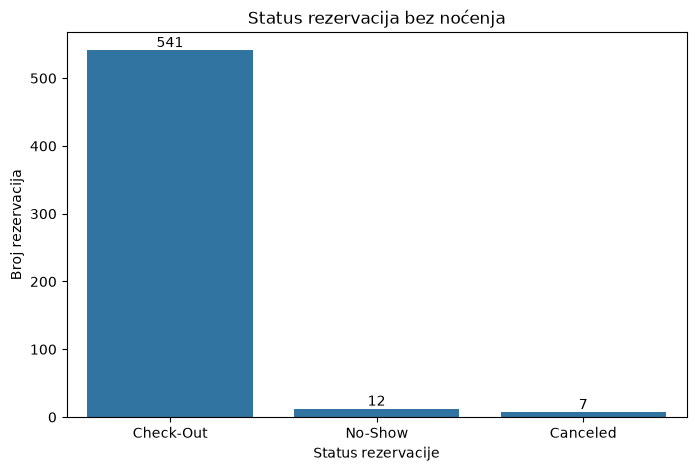

In [43]:
zero_stay_rows = analysis_df[analysis_df["total_stay"] == 0]

zero_stay_status_summary = (
    zero_stay_rows["reservation_status"]
    .value_counts(dropna=False)
    .rename_axis("Status rezervacije")
    .reset_index(name="Broj redova")
)

zero_stay_status_summary["Procenat rezervacija bez noćenja"] = (
    zero_stay_status_summary["Broj redova"] / len(zero_stay_rows) * 100
).round(3)

zero_stay_overview = pd.DataFrame({
    "Pokazatelj": [
        "Ukupan broj rezervacija bez noćenja",
        "Rezervacije bez evidentiranih gostiju",
        "Rezervacije sa najmanje jednim gostom",
        "Rezervacije sa ADR jednakim nuli",
        "Rezervacije sa pozitivnim ADR-om"
    ],
    "Broj redova": [
        len(zero_stay_rows),
        (zero_stay_rows["total_guests"] == 0).sum(),
        (zero_stay_rows["total_guests"] >= 1).sum(),
        (zero_stay_rows["adr"] == 0).sum(),
        (zero_stay_rows["adr"] > 0).sum()
    ]
})

display(zero_stay_status_summary)
display(zero_stay_overview)

plt.figure(figsize=(8, 5))

ax = sb.countplot(
    data=zero_stay_rows,
    x="reservation_status",
    order=zero_stay_rows["reservation_status"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Status rezervacija bez noćenja")
plt.xlabel("Status rezervacije")
plt.ylabel("Broj rezervacija")
plt.show()

Među 560 rezervacija bez noćenja u trening periodu, 541 ima status `Check-Out`, 12 status `No-Show`, a 7 status `Canceled`. Sve imaju najmanje jednog evidentiranog gosta i ADR jednak nuli. Ovi zapisi zato ne predstavljaju rezervacije bez gosta, ali njihovo precizno poslovno značenje nije moguće pouzdano utvrditi samo iz dostupnih kolona.


#### 8.3.4. Analiza rezervacija sa neuobičajeno velikim brojem gostiju

Za mali broj rezervacija koje ispunjavaju prethodno definisan kriterijum prikazuju se svi redovi, kao i njihove raspodele prema tržišnom segmentu i statusu rezervacije.


,hotel,is_canceled,adults,children,babies,total_guests,total_stay,adr,market_segment,reservation_status
2173,Resort Hotel,1,55,0.0,0,55.0,2,0.00,Direct,Canceled
1643,Resort Hotel,1,50,0.0,0,50.0,3,0.00,Direct,Canceled
1539,Resort Hotel,1,40,0.0,0,40.0,3,0.00,Direct,Canceled
1962,Resort Hotel,1,27,0.0,0,27.0,4,0.00,Direct,Canceled
1917,Resort Hotel,1,27,0.0,0,27.0,4,0.00,Direct,Canceled
1752,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled
1587,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled
2003,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled
1884,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled
2164,Resort Hotel,1,26,0.0,0,26.0,7,0.00,Offline TA/TO,Canceled


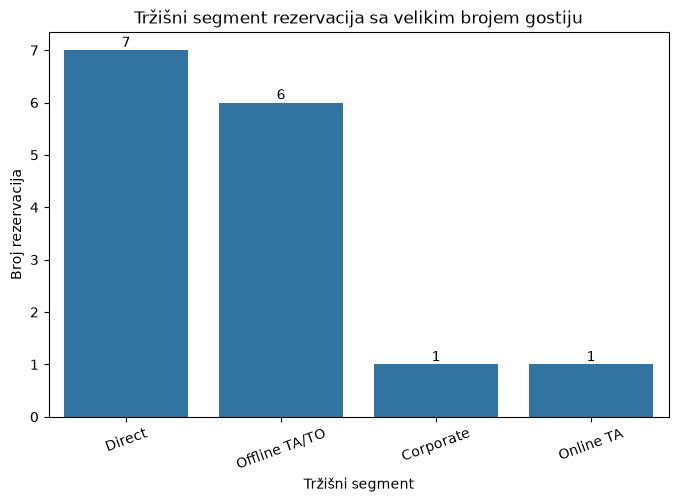

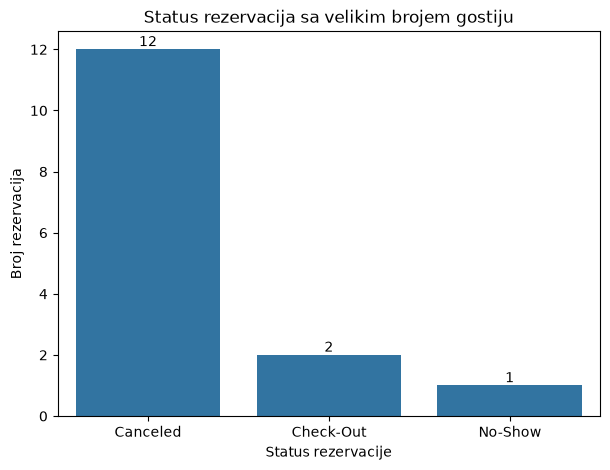

In [44]:
extreme_guest_rows = analysis_df[
    (analysis_df["adults"] > 10)
    | (analysis_df["children"] > 5)
    | (analysis_df["babies"] > 5)
]

extreme_guest_columns = [
    "hotel", "is_canceled", "adults", "children", "babies",
    "total_guests", "total_stay", "adr", "market_segment",
    "reservation_status"
]

display(extreme_guest_rows.sort_values("total_guests", ascending=False)[extreme_guest_columns])

plt.figure(figsize=(8, 5))

market_order = (
    extreme_guest_rows["market_segment"]
    .value_counts()
    .index
)

ax = sb.countplot(
    data=extreme_guest_rows,
    x="market_segment",
    order=market_order
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Tržišni segment rezervacija sa velikim brojem gostiju")
plt.xlabel("Tržišni segment")
plt.ylabel("Broj rezervacija")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7, 5))

status_order = (
    extreme_guest_rows["reservation_status"]
    .value_counts()
    .index
)

ax = sb.countplot(
    data=extreme_guest_rows,
    x="reservation_status",
    order=status_order
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Status rezervacija sa velikim brojem gostiju")
plt.xlabel("Status rezervacije")
plt.ylabel("Broj rezervacija")
plt.show()

Među rezervacijama sa neuobičajeno velikim brojem gostiju najzastupljeniji su segmenti Direct i Offline TA/TO, dok je većina ovih rezervacija otkazana. Ipak, postoje i realizovane rezervacije, uključujući one sa većim brojem dece ili beba, što pokazuje da ova grupa nije ujednačena i da obuhvata različite vrste rezervacija.

#### 8.3.5. Veliki lead time i dugo čekanje

U ovom delu analiziraju se rezervacije sa velikim lead_time i dugim čekanjem na listi čekanja. Grupe se porede prema broju rezervacija i procentu otkazivanja kako bi se utvrdilo da li postoji povezanost između ovih karakteristika i učestalosti otkazivanja.


In [45]:
def create_group_comparison(groups):
    rows = []

    for group_name, condition in groups:
        group_rows = analysis_df.loc[condition]

        rows.append({
            "Grupa": group_name,
            "Broj rezervacija": len(group_rows),
            "Procenat ukupnog skupa": round(len(group_rows) / len(analysis_df) * 100, 3),
            "Broj otkazanih rezervacija": group_rows["is_canceled"].sum(),
            "Procenat otkazanih rezervacija": round(group_rows["is_canceled"].mean() * 100, 3)
        })

    return pd.DataFrame(rows)


lead_time_comparison = create_group_comparison([
    (
        "lead_time <= 365",
        analysis_df["lead_time"] <= 365
    ),
    (
        "lead_time > 365",
        analysis_df["lead_time"] > 365
    )
])

waiting_list_comparison = create_group_comparison([
    (
        "days_in_waiting_list <= 100",
        analysis_df["days_in_waiting_list"] <= 100
    ),
    (
        "days_in_waiting_list > 100",
        analysis_df["days_in_waiting_list"] > 100
    )
])

display(lead_time_comparison)
display(waiting_list_comparison)

,Grupa,Broj rezervacija,Procenat ukupnog skupa,Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,lead_time <= 365,92131,96.697,34518,37.466
1,lead_time > 365,3147,3.303,2129,67.652


,Grupa,Broj rezervacija,Procenat ukupnog skupa,Broj otkazanih rezervacija,Procenat otkazanih rezervacija
0,days_in_waiting_list <= 100,94533,99.218,36275,38.373
1,days_in_waiting_list > 100,745,0.782,372,49.933


Rezervacije napravljene više od godinu dana unapred imaju znatno viši procenat otkazivanja: 67,65% u odnosu na 37,47% kod rezervacija sa kraćim periodom do dolaska. Kod rezervacija koje su na listi čekanja provele više od 100 dana procenat otkazivanja iznosi 49,93%, naspram 38,37% kod ostalih rezervacija. Rezultati ukazuju da je `lead_time` izraženije povezan sa otkazivanjem, ali poređenja ne dokazuju uzročni odnos.


#### 8.3.6. Zaključak detaljnije analize

Detaljnija analiza pokazuje da neuobičajene vrednosti ne treba obrađivati na isti način. ADR granice određene su isključivo iz trening podataka, dok rezervacije bez noćenja, veliki `lead_time`, dugo čekanje i neuobičajeno veliki broj gostiju nisu automatski proglašeni greškama. Rezervacije bez evidentiranih gostiju nisu ponovo analizirane jer su uklonjene pre vremenske podele unapred definisanim pravilom. Odluke primenjene u nastavku zasnivaju se na ovim proverama.


### 8.4. Primena ADR pravila naučenog na trening skupu

Granice određene u prethodnom koraku primenjuju se bez promene i na trening i na test period. Test raspodela se ne koristi za ponovno računanje ili prilagođavanje pravila.


In [46]:
invalid_adr_train_mask = ~train_df["adr"].between(
    adr_lower_bound,
    adr_upper_bound
)
invalid_adr_test_mask = ~test_df["adr"].between(
    adr_lower_bound,
    adr_upper_bound
)

removed_adr_train_rows = int(invalid_adr_train_mask.sum())
removed_adr_test_rows = int(invalid_adr_test_mask.sum())
removed_adr_rows = removed_adr_train_rows + removed_adr_test_rows

train_df = train_df.loc[~invalid_adr_train_mask].copy()
test_df = test_df.loc[~invalid_adr_test_mask].copy()

print("ADR granice naučene samo na trening skupu:")
print(round(adr_lower_bound, 2), "do", round(adr_upper_bound, 2))
print("Uklonjeno iz trening skupa:", removed_adr_train_rows)
print("Uklonjeno iz test skupa:", removed_adr_test_rows)


ADR granice naučene samo na trening skupu:
0.0 do 272.7
Uklonjeno iz trening skupa: 263
Uklonjeno iz test skupa: 377


### 8.5. Statistička provera odabranih povezanosti na trening skupu

Statistički testovi izvršavaju se samo nad `analysis_df`, koji sadrži originalne redove iz trening perioda. Test period ne učestvuje u računanju statistika niti tumačenju koje može uticati na modeliranje.


In [47]:
from scipy.stats import chi2_contingency, mannwhitneyu

def format_p_value(value):
    if value < 0.001:
        return "< 0.001"

    return f"{value:.3f}"

def chi_square_test(data, column):
    test_data = data

    if column in [
        "market_segment",
        "distribution_channel"
    ]:
        test_data = data.loc[
            data[column] != "Undefined"
        ].copy()

    contingency_table = pd.crosstab(
        test_data[column],
        test_data["is_canceled"]
    )

    chi2, p_value, degrees_of_freedom, _ = chi2_contingency(
        contingency_table
    )

    total_count = contingency_table.to_numpy().sum()
    minimum_dimension = min(contingency_table.shape) - 1

    if minimum_dimension > 0:
        cramers_v = np.sqrt(
            chi2 / (total_count * minimum_dimension)
        )
    else:
        cramers_v = np.nan

    return {
        "Promenljiva": column,
        "Hi-kvadrat statistika": chi2,
        "Stepeni slobode": degrees_of_freedom,
        "p-vrednost": p_value,
        "Cramér-ov V": cramers_v
    }

categorical_test_columns = [
    "hotel",
    "deposit_type",
    "market_segment",
    "distribution_channel"
]

chi_square_results = pd.DataFrame([
    chi_square_test(analysis_df, column)
    for column in categorical_test_columns
])

chi_square_results["Hi-kvadrat statistika"] = chi_square_results["Hi-kvadrat statistika"].round(2)
chi_square_results["Cramér-ov V"] = chi_square_results["Cramér-ov V"].round(3)
chi_square_results["p-vrednost"] = chi_square_results["p-vrednost"].apply(format_p_value)

display(chi_square_results)

lead_time_not_canceled = analysis_df.loc[
    analysis_df["is_canceled"] == 0,
    "lead_time"
]

lead_time_canceled = analysis_df.loc[
    analysis_df["is_canceled"] == 1,
    "lead_time"
]

mann_whitney_statistic, mann_whitney_p = mannwhitneyu(
    lead_time_not_canceled,
    lead_time_canceled,
    alternative="two-sided"
)

print(
    "Mann–Whitney U statistika:",
    round(mann_whitney_statistic, 2)
)

print(
    "p-vrednost:",
    format_p_value(mann_whitney_p)
)

print(
    "Medijana lead_time za neotkazane rezervacije:",
    round(lead_time_not_canceled.median(), 2)
)

print(
    "Medijana lead_time za otkazane rezervacije:",
    round(lead_time_canceled.median(), 2)
)

,Promenljiva,Hi-kvadrat statistika,Stepeni slobode,p-vrednost,Cramér-ov V
0,hotel,2092.01,1,< 0.001,0.148
1,deposit_type,24447.07,2,< 0.001,0.507
2,market_segment,7038.65,6,< 0.001,0.272
3,distribution_channel,2848.24,3,< 0.001,0.173


Mann–Whitney U statistika: 659816437.0
p-vrednost: < 0.001
Medijana lead_time za neotkazane rezervacije: 53.0
Medijana lead_time za otkazane rezervacije: 134.0


Tabela prikazuje hi-kvadrat statistiku, broj stepeni slobode, p-vrednost i Cramér-ov V za odabrane kategorijske promenljive u trening periodu. Cramér-ov V omogućava poređenje jačine povezanosti, dok Mann–Whitney U test proverava da li se raspodele `lead_time` razlikuju između dve ciljne klase. Zbog velikog broja rezervacija p-vrednosti se tumače zajedno sa veličinama efekta i deskriptivnim pokazateljima, a ne samostalno.


## 9. Obrada nedostajućih vrednosti

### 9.1. Konstantne zamene nedostajućih vrednosti

Postojeće zamene nulom ili oznakom `Unknown` ne računaju statistiku iz podataka i zato su jasno odvojene od median/mode imputacije. Ipak, primenjuju se tek posle podele i zasebno na trening i test delu.

- `children` se popunjava nulom i pretvara u ceo broj;
- `country` se popunjava oznakom `Unknown`;
- `agent` i `company` se popunjavaju nulom kao oznakom da identifikator nije evidentiran.


In [48]:
def apply_constant_missing_replacements(data):
    result = data.copy()
    result["children"] = result["children"].fillna(0).astype(int)
    result["country"] = result["country"].fillna("Unknown")
    result["agent"] = result["agent"].fillna(0).astype(int)
    result["company"] = result["company"].fillna(0).astype(int)
    return result


train_df = apply_constant_missing_replacements(train_df)
test_df = apply_constant_missing_replacements(test_df)

clean_df = (
    pd.concat([train_df, test_df], axis=0)
    .sort_index()
)


In [49]:
missing_after_filling = (
    clean_df.isna()
    .sum()
    .sort_values(ascending=False)
)

remaining_missing = missing_after_filling[missing_after_filling > 0]

if remaining_missing.empty:
    print("Nakon obrade nema nedostajućih vrednosti.")
else:
    display(remaining_missing.to_frame("Broj nedostajućih vrednosti"))

Nakon obrade nema nedostajućih vrednosti.


### 9.2. Median/mode imputacija

Median i mode se ne računaju u ovom poglavlju nad celim skupom. Postojeći `SimpleImputer(strategy="median")` i `SimpleImputer(strategy="most_frequent")` nalaze se posle podele, unutar pipeline-a u poglavlju 11, tako da se njihove vrednosti uče samo iz trening dela odgovarajućeg fit/CV koraka.


### 9.3. Pregled izvršenih promena


In [50]:
rows_after_cleaning = len(clean_df)
columns_after_cleaning = clean_df.shape[1]

cleaning_summary = pd.DataFrame({
    "Promena": [
        "Izdvojene ADR vrednosti",
        "Rezervacije bez evidentiranih gostiju",
        "Ukupno uklonjeni redovi",
        "Uklonjene kolone"
    ],
    "Broj": [
        removed_adr_rows,
        removed_zero_guest_rows,
        rows_before_cleaning - rows_after_cleaning,
        columns_before_cleaning - columns_after_cleaning
    ]
})

display(cleaning_summary)

print(f"Dimenzije pre čišćenja: {df.shape}")
print(f"Dimenzije posle čišćenja: {clean_df.shape}")

,Promena,Broj
0,Izdvojene ADR vrednosti,640
1,Rezervacije bez evidentiranih gostiju,180
2,Ukupno uklonjeni redovi,820
3,Uklonjene kolone,6


Dimenzije pre čišćenja: (119390, 36)
Dimenzije posle čišćenja: (118570, 30)


In [51]:
final_validation = pd.Series({
    "Nedostajuće vrednosti": int(clean_df.isna().sum().sum()),
    "Negativne ADR vrednosti": int((clean_df["adr"] < 0).sum()),
    "ADR vrednosti veće od 1000": int((clean_df["adr"] > 1000).sum()),
    "Rezervacije bez evidentiranih gostiju": 
        int((clean_df["adults"] + clean_df["children"] + clean_df["babies"] == 0).sum())
})

display(final_validation.to_frame("Broj preostalih zapisa"))

,Broj preostalih zapisa
Nedostajuće vrednosti,0
Negativne ADR vrednosti,0
ADR vrednosti veće od 1000,0
Rezervacije bez evidentiranih gostiju,0


### 9.4. Provera raspodele ciljne promenljive

Posle čišćenja proverava se odnos otkazanih i neotkazanih rezervacija kako bi se utvrdilo da li je uklanjanje malog broja zapisa značajno promenilo raspodelu ciljne promenljive.


In [52]:
target_distribution_before = (
    y_split_train
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_distribution_after = (
    train_df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_distribution_comparison = pd.DataFrame({
    "Trening pre čišćenja (%)": target_distribution_before,
    "Trening posle čišćenja (%)": target_distribution_after
}).round(3)

target_distribution_comparison.index = [
    "Nije otkazana",
    "Otkazana"
]

display(target_distribution_comparison)


,Trening pre čišćenja (%),Trening posle čišćenja (%)
Nije otkazana,61.537,61.524
Otkazana,38.463,38.476


### 9.5. Čuvanje očišćenog skupa

Nakon završenih provera, `clean_df` se čuva kao poseban CSV fajl. Parametar `index=False` sprečava upisivanje indeksa DataFrame-a kao dodatne kolone. Fajl se zatim ponovo učitava radi provere putanje, dimenzija i naziva kolona.


In [53]:
from pathlib import Path

cleaned_output_path = Path("../data/hotel_booking_cleaned.csv")
cleaned_output_path.parent.mkdir(parents=True, exist_ok=True)

clean_df.to_csv(
    cleaned_output_path,
    index=False
)

saved_clean_df = pd.read_csv(cleaned_output_path)

assert cleaned_output_path.is_file()
assert saved_clean_df.shape == clean_df.shape
assert saved_clean_df.columns.tolist() == clean_df.columns.tolist()

print("Očišćeni skup je uspešno sačuvan.")
print("Putanja:", cleaned_output_path)
print("Dimenzije sačuvanog skupa:", saved_clean_df.shape)


Očišćeni skup je uspešno sačuvan.
Putanja: ..\data\hotel_booking_cleaned.csv
Dimenzije sačuvanog skupa: (118570, 30)


Izvršena provera ponovnim učitavanjem potvrđuje da je `hotel_booking_cleaned.csv` napravljen sa aktuelnim brojem redova i kolona, bez dodatne indeksne kolone. Dimenzije se prikazuju u prethodnom izlazu i potiču iz ovog izvršavanja.


### 9.6. Zaključak obrade kvaliteta i nedostajućih vrednosti

Konstantne zamene primenjene su odvojeno na već podeljene skupove. ADR granice naučene su isključivo iz trening perioda i bez ponovnog prilagođavanja primenjene na test period. Median/mode imputacija nije računata unapred, već ostaje unutar pipeline-a i fituje se samo na odgovarajućem trening delu.

Kombinovani `clean_df` postoji radi pregleda i čuvanja obrađenih podataka; nikada se ne koristi kao izvor train/test podele.


## 10. Feature engineering

Feature engineering se izvršava tek nakon vremenske podele i odvojeno nad `train_df` i `test_df`. Transformacije su determinističke i ne koriste ciljnu promenljivu niti statistike iz drugog dela podataka.


In [54]:
train_model_df = train_df.copy()
test_model_df = test_df.copy()

# Kombinovani model_df postoji samo radi postojećih pregleda i čuvanja fajla.
# Modeli se formiraju direktno iz train_model_df i test_model_df.
model_df = (
    pd.concat([train_model_df, test_model_df], axis=0)
    .sort_index()
)

print("Dimenzije clean_df:", clean_df.shape)
print("Početne dimenzije model_df:", model_df.shape)


Dimenzije clean_df: (118570, 30)
Početne dimenzije model_df: (118570, 30)


`train_model_df` i `test_model_df` ostaju fizički odvojeni. Kombinovani `model_df` služi samo da postojeći deskriptivni pregledi i sačuvani izlazi ostanu dostupni; nije izvor iz kog se naknadno bira train/test podela.


### 10.1. Informacije o boravku i gostima

Kolone `stays_in_weekend_nights` i `stays_in_week_nights` odvojeno prikazuju broj noćenja tokom vikenda i radnih dana. Njihovim sabiranjem dobija se promenljiva `total_stay`, koja predstavlja ukupan broj planiranih noćenja.

Na sličan način, sabiranjem broja odraslih, dece i beba dobija se promenljiva `total_guests`. Dodatno se kreira binarna promenljiva `has_children_or_babies`, koja ima vrednost 1 kada rezervacija uključuje najmanje jedno dete ili bebu, a vrednost 0 u suprotnom.


In [55]:
for dataset in (train_model_df, test_model_df):
    dataset["total_stay"] = (
        dataset["stays_in_weekend_nights"]
        + dataset["stays_in_week_nights"]
    )
    dataset["total_guests"] = (
        dataset["adults"] + dataset["children"] + dataset["babies"]
    )
    dataset["has_children_or_babies"] = (
        (dataset["children"] > 0) | (dataset["babies"] > 0)
    ).astype(int)

model_df = pd.concat(
    [train_model_df, test_model_df], axis=0
).sort_index()

stay_and_guest_columns = [
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_stay",
    "adults",
    "children",
    "babies",
    "total_guests",
    "has_children_or_babies"
]

stay_and_guest_preview = pd.concat([
    model_df.loc[
        model_df["has_children_or_babies"] == 0,
        stay_and_guest_columns
    ].head(5),
    model_df.loc[
        model_df["has_children_or_babies"] == 1,
        stay_and_guest_columns
    ].head(5)
])

display(stay_and_guest_preview)


,stays_in_weekend_nights,stays_in_week_nights,total_stay,adults,children,babies,total_guests,has_children_or_babies
0,0,0,0,2,0,0,2,0
1,0,0,0,2,0,0,2,0
2,0,1,1,1,0,0,1,0
3,0,1,1,1,0,0,1,0
4,0,2,2,2,0,0,2,0
13,0,4,4,2,1,0,3,1
45,2,5,7,2,2,0,4,1
55,0,1,1,2,2,0,4,1
65,0,2,2,2,2,0,4,1
87,6,15,21,2,1,0,3,1


Nove promenljive ne zamenjuju originalne kolone, već ih dopunjuju. `total_stay` omogućava da se ukupna dužina boravka koristi kao jedna vrednost, dok `total_guests` daje ukupan broj osoba obuhvaćenih rezervacijom. Promenljiva `has_children_or_babies` izdvaja rezervacije koje uključuju decu ili bebe bez obzira na njihov tačan broj. U tabeli je prikazano po pet primera sa vrednošću 0 i 1, kako bi se jasno videlo na koji način je ova promenljiva formirana.

### 10.2. Sažete informacije o istoriji gosta

Kolone `previous_cancellations` i `previous_bookings_not_canceled` odvojeno prikazuju broj prethodno otkazanih i uspešno realizovanih rezervacija. Njihovim sabiranjem kreira se `total_previous_bookings`, koja predstavlja ukupan broj evidentiranih prethodnih rezervacija gosta.

Promenljiva `has_booking_history` označava da li gost ima makar jednu prethodnu rezervaciju. Dodatno se računa `previous_cancellation_rate`, odnosno udeo prethodnih rezervacija koje su bile otkazane. Vrednost 0,5, na primer, znači da je 50% prethodnih rezervacija bilo otkazano. Za goste bez prethodnih rezervacija ova vrednost se postavlja na 0, dok `has_booking_history` omogućava da se oni razlikuju od gostiju koji imaju istoriju bez otkazivanja.


In [56]:
for dataset in (train_model_df, test_model_df):
    dataset["total_previous_bookings"] = (
        dataset["previous_cancellations"]
        + dataset["previous_bookings_not_canceled"]
    )
    dataset["has_booking_history"] = (
        dataset["total_previous_bookings"] > 0
    ).astype(int)
    dataset["previous_cancellation_rate"] = np.where(
        dataset["total_previous_bookings"] > 0,
        (
            dataset["previous_cancellations"]
            / dataset["total_previous_bookings"]
        ),
        0.0
    )

model_df = pd.concat(
    [train_model_df, test_model_df], axis=0
).sort_index()

booking_history_preview = (
    model_df.loc[
        model_df["has_booking_history"] == 1,
        [
            "previous_cancellations",
            "previous_bookings_not_canceled",
            "total_previous_bookings",
            "has_booking_history",
            "previous_cancellation_rate"
        ]
    ]
    .drop_duplicates()
    .sort_values([
        "total_previous_bookings",
        "previous_cancellation_rate"
    ])
    .head(10)
)

display(booking_history_preview)


,previous_cancellations,previous_bookings_not_canceled,total_previous_bookings,has_booking_history,previous_cancellation_rate
13803,0,1,1,1,0.000000
13988,1,0,1,1,1.000000
13804,0,2,2,1,0.000000
13811,1,1,2,1,0.500000
14333,2,0,2,1,1.000000
13815,0,3,3,1,0.000000
13826,1,2,3,1,0.333333
14932,2,1,3,1,0.666667
14902,3,0,3,1,1.000000
13851,0,4,4,1,0.000000


Ove promenljive prikazuju istoriju gosta u sažetijem obliku. `total_previous_bookings` opisuje obim prethodnog iskustva sa hotelom, dok `previous_cancellation_rate` pravi razliku između gostiju koji imaju isti broj prethodnih rezervacija, ali različit odnos otkazanih i realizovanih rezervacija. Koliko se model oslanja na ove informacije biće razmotreno u kasnijoj analizi važnosti promenljivih.

### 10.3. Sezona planiranog dolaska

Kolona `arrival_date_month` sadrži pojedinačne mesece dolaska. Na osnovu nje kreira se promenljiva `arrival_season`, koja mesece grupiše u četiri godišnja doba. Time se omogućava posmatranje širih vremenskih obrazaca bez uklanjanja originalne informacije o mesecu dolaska.

Meseci decembar, januar i februar pripadaju zimi, mart, april i maj proleću, jun, jul i avgust letu, a septembar, oktobar i novembar jeseni.


In [57]:
season_mapping = {
    "December": "Winter",
    "January": "Winter",
    "February": "Winter",
    "March": "Spring",
    "April": "Spring",
    "May": "Spring",
    "June": "Summer",
    "July": "Summer",
    "August": "Summer",
    "September": "Autumn",
    "October": "Autumn",
    "November": "Autumn"
}

season_order = ["Winter", "Spring", "Summer", "Autumn"]

for dataset in (train_model_df, test_model_df):
    dataset["arrival_season"] = pd.Categorical(
        dataset["arrival_date_month"].map(season_mapping),
        categories=season_order,
        ordered=True
    )

model_df = pd.concat(
    [train_model_df, test_model_df], axis=0
).sort_index()

season_summary = (
    model_df["arrival_season"]
    .value_counts(sort=False)
    .rename_axis("Sezona")
    .reset_index(name="Broj rezervacija")
)

display(season_summary)


,Sezona,Broj rezervacija
0,Winter,20683
1,Spring,32579
2,Summer,36904
3,Autumn,28404


Promenljiva `arrival_season` predstavlja sažet prikaz meseca planiranog dolaska. Originalna kolona `arrival_date_month` ostaje u skupu, pa su modelu dostupni i tačan mesec i šire grupisanje po godišnjim dobima. Kasnija analiza važnosti pokazaće koliko se model oslanjao na svaku od ovih informacija.

### 10.4. Grupe prema periodu između rezervisanja i dolaska

Pored originalne numeričke promenljive `lead_time`, zadržava se postojeća kategorijska promenljiva `lead_time_group` sa unapred zapisanim granicama: do 30 dana, 31–90, 91–180, 181–365 i više od 365 dana.

Granice se u ovom koraku ne računaju iz `eda_df`, trening ili test raspodele, već se tretiraju kao postojeća fiksna specifikacija i primenjuju odvojeno na oba skupa. Njihovu metodološku opravdanost treba posebno proveriti u narednom koraku.


In [58]:
lead_time_bins = [-1, 30, 90, 180, 365, np.inf]
lead_time_labels = [
    "0-30 dana",
    "31-90 dana",
    "91-180 dana",
    "181-365 dana",
    "Više od 365 dana"
]

for dataset in (train_model_df, test_model_df):
    dataset["lead_time_group"] = pd.cut(
        dataset["lead_time"],
        bins=lead_time_bins,
        labels=lead_time_labels,
        include_lowest=True,
        ordered=True
    )

model_df = pd.concat(
    [train_model_df, test_model_df], axis=0
).sort_index()

lead_time_group_summary = (
    model_df["lead_time_group"]
    .value_counts(sort=False)
    .rename_axis("Lead time grupa")
    .reset_index(name="Broj rezervacija")
)
lead_time_group_summary["Udeo u ukupnom skupu (%)"] = (
    lead_time_group_summary["Broj rezervacija"] / len(model_df) * 100
).round(2)

display(lead_time_group_summary)


,Lead time grupa,Broj rezervacija,Udeo u ukupnom skupu (%)
0,0-30 dana,38354,32.35
1,31-90 dana,29304,24.71
2,91-180 dana,26282,22.17
3,181-365 dana,21484,18.12
4,Više od 365 dana,3146,2.65


Kategorijska promenljiva `lead_time_group` omogućava da se prikažu različiti intervali perioda između rezervisanja i dolaska. Ona ne zamenjuje originalnu numeričku promenljivu, već predstavlja njen dodatni prikaz koji može biti koristan modelima koji teže prepoznaju nelinearne odnose. Koliko se izabrani model oslanjao na ovu izvedenu promenljivu biće prikazano u kasnijoj analizi važnosti promenljivih.

### 10.5. Pregled i provera kreiranih promenljivih

Nakon feature engineering-a proveravaju se tipovi novih promenljivih, broj njihovih jedinstvenih vrednosti i eventualne nedostajuće vrednosti. Takođe se proverava da broj redova nije promenjen i da nove kolone nisu dodate u originalni `clean_df`.


In [59]:
new_features = [
    "total_stay",
    "total_guests",
    "has_children_or_babies",
    "total_previous_bookings",
    "has_booking_history",
    "previous_cancellation_rate",
    "arrival_season",
    "lead_time_group"
]

new_feature_descriptions = {
    "total_stay": (
        "Ukupan broj planiranih noćenja"
    ),
    "total_guests": (
        "Ukupan broj odraslih, dece i beba"
    ),
    "has_children_or_babies": (
        "Da li rezervacija uključuje dete ili bebu"
    ),
    "total_previous_bookings": (
        "Ukupan broj prethodnih rezervacija gosta"
    ),
    "has_booking_history": (
        "Da li gost ima prethodne rezervacije"
    ),
    "previous_cancellation_rate": (
        "Udeo otkazanih prethodnih rezervacija"
    ),
    "arrival_season": (
        "Godišnje doba planiranog dolaska"
    ),
    "lead_time_group": (
        "Interval perioda između rezervisanja i dolaska"
    )
}

feature_engineering_summary = pd.DataFrame({
    "Nova promenljiva": new_features,
    "Opis": [
        new_feature_descriptions[column]
        for column in new_features
    ],
    "Tip podatka": [
        str(model_df[column].dtype)
        for column in new_features
    ],
    "Broj jedinstvenih vrednosti": [
        model_df[column].nunique(dropna=False)
        for column in new_features
    ],
    "Broj nedostajućih vrednosti": [
        model_df[column].isna().sum()
        for column in new_features
    ]
})

display(feature_engineering_summary)

print("Dimenzije clean_df:", clean_df.shape)
print("Dimenzije model_df:", model_df.shape)
print("Broj dodatih promenljivih:", len(new_features))

assert len(model_df) == len(clean_df)

assert model_df.shape[1] == (
    clean_df.shape[1] + len(new_features)
)

assert (
    model_df[new_features]
    .isna()
    .sum()
    .sum()
    == 0
)

assert not any(
    column in clean_df.columns
    for column in new_features
)

print("Provere su uspešno završene.")

,Nova promenljiva,Opis,Tip podatka,Broj jedinstvenih vrednosti,Broj nedostajućih vrednosti
0,total_stay,Ukupan broj planiranih noćenja,int64,42,0
1,total_guests,"Ukupan broj odraslih, dece i beba",int64,14,0
2,has_children_or_babies,Da li rezervacija uključuje dete ili bebu,int64,2,0
3,total_previous_bookings,Ukupan broj prethodnih rezervacija gosta,int64,77,0
4,has_booking_history,Da li gost ima prethodne rezervacije,int64,2,0
5,previous_cancellation_rate,Udeo otkazanih prethodnih rezervacija,float64,111,0
6,arrival_season,Godišnje doba planiranog dolaska,category,4,0
7,lead_time_group,Interval perioda između rezervisanja i dolaska,category,5,0


Dimenzije clean_df: (118570, 30)
Dimenzije model_df: (118570, 38)
Broj dodatih promenljivih: 8
Provere su uspešno završene.


### 10.6. Čuvanje skupa pripremljenog za modeliranje

Posle kreiranja i provere novih promenljivih, `model_df` se čuva kao poseban CSV fajl. I ovde se koristi `index=False`, a ponovnim učitavanjem fajla proverava se da su broj redova, broj kolona i nazivi kolona ostali nepromenjeni.


In [60]:
from pathlib import Path

model_ready_output_path = Path("../data/hotel_booking_model_ready.csv")
model_ready_output_path.parent.mkdir(parents=True, exist_ok=True)

model_df.to_csv(
    model_ready_output_path,
    index=False
)

saved_model_df = pd.read_csv(model_ready_output_path)

assert model_ready_output_path.is_file()
assert saved_model_df.shape == model_df.shape
assert saved_model_df.columns.tolist() == model_df.columns.tolist()

print("Skup pripremljen za modeliranje je uspešno sačuvan.")
print("Putanja:", model_ready_output_path)
print("Dimenzije sačuvanog skupa:", saved_model_df.shape)


Skup pripremljen za modeliranje je uspešno sačuvan.
Putanja: ..\data\hotel_booking_model_ready.csv
Dimenzije sačuvanog skupa: (118570, 38)


Izvršena provera potvrđuje da je `hotel_booking_model_ready.csv` sačuvan sa aktuelnim dimenzijama i bez dodatne indeksne kolone. Broj redova i kolona prikazan je u prethodnom izlazu i ponovo je izračunat u ovom izvršavanju.


### 10.7. Formiranje finalnih prediktora iz već odvojenih skupova

Prediktori se formiraju direktno iz `train_model_df` i `test_model_df`. Kombinovani `X` i `y` postoje samo radi očuvanja postojećih pregleda; ne koriste se za ponovno biranje podele.


In [61]:
target_column = "is_canceled"

columns_unavailable_at_prediction = [
    "assigned_room_type",
    "booking_changes",
    "days_in_waiting_list"
]

X_train = train_model_df.drop(
    columns=[target_column, *columns_unavailable_at_prediction]
).copy()
X_test = test_model_df.drop(
    columns=[target_column, *columns_unavailable_at_prediction]
).copy()
y_train = train_model_df[target_column].copy()
y_test = test_model_df[target_column].copy()

X = pd.concat([X_train, X_test], axis=0).sort_index()
y = pd.concat([y_train, y_test], axis=0).sort_index()

training_booking_dates = train_booking_dates.loc[X_train.index].copy()
testing_booking_dates = test_booking_dates.loc[X_test.index].copy()

print("Dimenzije model_df:", model_df.shape)
print("Dimenzije X:", X.shape)
print("Dimenzije y:", y.shape)
print("Broj prediktora:", X.shape[1])

print("\nKolone izostavljene iz modeliranja:")
for column in columns_unavailable_at_prediction:
    print("-", column)
print("- booking_date (korišćen samo za sortiranje i podelu)")

assert "booking_date" not in X_train.columns
assert "booking_date" not in X_test.columns
assert target_column not in X_train.columns
assert target_column not in X_test.columns
assert all(
    column not in X_train.columns
    for column in columns_unavailable_at_prediction
)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)
assert training_booking_dates.is_monotonic_increasing
assert testing_booking_dates.is_monotonic_increasing

print("\nProvere su uspešno završene.")


Dimenzije model_df: (118570, 38)
Dimenzije X: (118570, 34)
Dimenzije y: (118570,)
Broj prediktora: 34

Kolone izostavljene iz modeliranja:
- assigned_room_type
- booking_changes
- days_in_waiting_list
- booking_date (korišćen samo za sortiranje i podelu)

Provere su uspešno završene.


Ciljna promenljiva i prediktori formiraju se direktno i odvojeno iz `train_model_df` i `test_model_df`. `booking_date` je sačuvan samo u zasebnim serijama za proveru vremenskog redosleda i ne ulazi u prediktore. Kombinovani objekti služe samo za deskriptivni pregled i čuvanje, a ne za ponovno pravljenje podele.


In [62]:
print("Dimenzije X_train:", X_train.shape)
print("Dimenzije X_test:", X_test.shape)
print("Dimenzije y_train:", y_train.shape)
print("Dimenzije y_test:", y_test.shape)
print(
    "Trening booking period:",
    training_booking_dates.min().date(),
    "–",
    training_booking_dates.max().date()
)
print(
    "Test booking period:",
    testing_booking_dates.min().date(),
    "–",
    testing_booking_dates.max().date()
)

assert set(X_train.index).isdisjoint(X_test.index)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)
assert training_booking_dates.max() < testing_booking_dates.min()


Dimenzije X_train: (95015, 34)
Dimenzije X_test: (23555, 34)
Dimenzije y_train: (95015,)
Dimenzije y_test: (23555,)
Trening booking period: 2013-06-24 – 2017-01-11
Test booking period: 2017-01-12 – 2017-08-31


### 10.8. Zaključak feature engineering-a

Sačuvano je osam postojećih izvedenih promenljivih: `total_stay`, `total_guests`, `has_children_or_babies`, `total_previous_bookings`, `has_booking_history`, `previous_cancellation_rate`, `arrival_season` i `lead_time_group`.

Sve su sada formirane odvojeno u `train_model_df` i `test_model_df`, nakon hronološke podele i bez korišćenja ciljne promenljive. Feature selection ostaje zasebno poglavlje 13.


## 11. Preprocesiranje podataka

U ovom poglavlju nalaze se imputacija medijanom i najčešćom vrednošću, `StandardScaler`, `OneHotEncoder`, `ColumnTransformer` i pipeline. Sve statistički vođene transformacije definišu se posle train/test podele.


### 11.1. Razdvajanje numeričkih i kategorijskih kolona

Numeričke i kategorijske promenljive potrebno je pripremiti na različite načine. Numeričke vrednosti će se skalirati, dok će se kategorijske vrednosti pretvoriti u oblik koji modeli mogu da koriste. Podela se najpre vrši na osnovu tipova podataka u trening skupu. Među kategorijske kolone uključene su izvedene promenljive `arrival_season` i `lead_time_group`, kao i `agent` i `company`. Iako su vrednosti u kolonama `agent` i `company` zapisane kao brojevi, one predstavljaju identifikacione oznake, pa se obrađuju kao kategorije.


In [63]:
numeric_columns = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object", "str", "category"]
).columns.tolist()

identifier_columns = [
    "agent",
    "company"
]

numeric_columns = [
    column
    for column in numeric_columns
    if column not in identifier_columns
]

categorical_columns = (
    categorical_columns + identifier_columns
)

print("Broj numeričkih kolona:", len(numeric_columns))
print("Broj kategorijskih kolona:", len(categorical_columns))

print("\nNumeričke kolone:")
print(numeric_columns)

print("\nKategorijske kolone:")
print(categorical_columns)

assert set(numeric_columns).isdisjoint(categorical_columns)
assert set(numeric_columns + categorical_columns) == set(X_train.columns)

print("\nSve kolone su uspešno razvrstane.")

Broj numeričkih kolona: 21
Broj kategorijskih kolona: 13

Numeričke kolone:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay', 'total_guests', 'has_children_or_babies', 'total_previous_bookings', 'has_booking_history', 'previous_cancellation_rate']

Kategorijske kolone:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'arrival_season', 'lead_time_group', 'agent', 'company']

Sve kolone su uspešno razvrstane.


### 11.2. Definisanje preprocesora

Za numeričke kolone definiše se popunjavanje eventualnih nedostajućih vrednosti medijanom i standardizacija pomoću `StandardScaler`. Skaliranje je naročito važno za modele osetljive na različite opsege promenljivih, kao što je logistička regresija.

Za kategorijske kolone eventualne nedostajuće vrednosti popunjavaju se najčešćom kategorijom, nakon čega se primenjuje one-hot kodiranje. Parametar `handle_unknown="ignore"` omogućava obradu kategorije koja se kasnije pojavi u test skupu, čak i ako nije postojala u podacima na kojima je transformacija naučena.

`ColumnTransformer` objedinjuje pripremu numeričkih i kategorijskih kolona. U ovoj fazi samo su definisana pravila pripreme, dok će se potrebne vrednosti, poput medijane, parametara skaliranja i kategorija za kodiranje, određivati kasnije na osnovu podataka za treniranje. Preprocesor će biti povezan sa svakim modelom u okviru pipeline-a, kako validacioni i test podaci ne bi uticali na pripremu trening podataka.


In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_preprocessor,
            numeric_columns
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_columns
        )
    ]
)

print("Preprocesor je uspešno definisan.")
print("Preprocesor još nije treniran.")

Preprocesor je uspešno definisan.
Preprocesor još nije treniran.


### 11.3. Provera povezivanja preprocesora i modela

Da bi se proverilo da li priprema podataka funkcioniše bez curenja informacija, definiše se probni pipeline sa `DummyClassifier` modelom. Pipeline povezuje preprocesor i model u jednu celinu. Pozivom metode `fit` nad trening skupom i preprocesor i model uče isključivo iz `X_train` i `y_train`.

Dummy model u ovom koraku služi samo kao tehnička provera pipeline-a. Njegovo detaljno poređenje sa ostalim modelima biće sprovedeno u narednom poglavlju pomoću unakrsne validacije.


In [65]:
from sklearn.dummy import DummyClassifier

validation_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

validation_pipeline.fit(X_train, y_train)
validation_predictions = validation_pipeline.predict(X_train.head(10))

print("Probna predviđanja:", validation_predictions)
print("Broj probnih predviđanja:", len(validation_predictions))

assert len(validation_predictions) == 10
assert set(validation_predictions).issubset(set(y_train.unique()))

print("Pipeline i preprocesor uspešno funkcionišu.")

Probna predviđanja: [0 0 0 0 0 0 0 0 0 0]
Broj probnih predviđanja: 10
Pipeline i preprocesor uspešno funkcionišu.


### 11.4. Zaključak preprocesiranja

Numeričke i kategorijske kolone određuju se iz hronološkog trening skupa. Median/mode imputacija, standardizacija i one-hot enkodovanje ostaju unutar pipeline-a, pa se njihove statistike uče samo tokom odgovarajućeg trening ili CV koraka.


## 12. Baseline modeli i poređenje modela

Nakon pripreme podataka mogu se definisati prvi klasifikacioni modeli. Cilj ovog poglavlja nije da se odmah pronađe konačan model, već da se pod jednakim uslovima uporedi nekoliko različitih pristupa i utvrdi koji od njih daju najbolje početne rezultate.

Poređenje se obavlja isključivo na trening skupu. Test skup ostaje odvojen i biće upotrebljen tek kada se završe izbor modela i podešavanje hiperparametara.


### 12.1. Izbor početnih modela

Za početno poređenje izabrano je pet modela koji predstavljaju različite pristupe klasifikaciji.

- `DummyClassifier` služi kao najjednostavnija početna referenca. On ne uči odnose u podacima, već u ovom slučaju svaku rezervaciju svrstava u zastupljeniju klasu. Ostali modeli treba da ostvare bolje rezultate od ove polazne vrednosti.
- Logistička regresija predstavlja jednostavan linearni model. Korisna je kao osnovni model jer se brzo trenira i pokazuje koliko se dobro otkazivanje može predvideti bez složenijih nelinearnih pravila.
- Stablo odlučivanja može da prepozna složenije odnose između promenljivih i da formira pravila na osnovu njihovih kombinacija. Njegove odluke se relativno lako mogu pratiti i objasniti, ali složeno stablo može biti previše prilagođeno trening podacima.
- Random Forest kombinuje veći broj stabala odlučivanja. Na taj način obično daje stabilnija predviđanja od jednog stabla, ali je složeniji i zahteva više vremena za treniranje.
- XGBoost takođe koristi veći broj stabala, ali ih gradi redom, tako da svako novo stablo pokušava da ispravi greške prethodnih. Ovaj model se često pokazuje uspešnim kod tabelarnih podataka i predstavlja drugačiji način kombinovanja većeg broja stabala.


In [66]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

models = {
    "DummyClassifier": DummyClassifier(
        strategy="most_frequent"
    ),
    "Logistička regresija": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    "Stablo odlučivanja": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=25,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="logloss",
        random_state=42,
        n_jobs=1
    )
}

print("Modeli izabrani za početno poređenje:")
for model_name in models:
    print("-", model_name)

Modeli izabrani za početno poređenje:
- DummyClassifier
- Logistička regresija
- Stablo odlučivanja
- Random Forest
- XGBoost


### 12.2. Povezivanje preprocesora i modela

Za svaki izabrani model formira se poseban pipeline koji sadrži preprocesor iz prethodnog poglavlja i sam model. Time se obezbeđuje da svi modeli dobiju podatke pripremljene na isti način.

Funkcija `clone` pravi novu, netreniranu kopiju preprocesora za svaki pipeline. Zbog toga modeli ne dele već izračunate vrednosti, kao što su medijane, parametri skaliranja ili kategorije koje je zapamtio `OneHotEncoder`.


In [67]:
from sklearn.base import clone

model_pipelines = {
    model_name: Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", model)
        ]
    )
    for model_name, model in models.items()
}

print("Broj formiranih pipeline-a:", len(model_pipelines))

for model_name, model_pipeline in model_pipelines.items():
    print(
        model_name,
        "->",
        list(model_pipeline.named_steps.keys())
    )

assert len(model_pipelines) == len(models)
assert all(
    list(model_pipeline.named_steps.keys())
    == ["preprocessor", "model"]
    for model_pipeline in model_pipelines.values()
)

print("Pipeline-i su uspešno formirani.")

Broj formiranih pipeline-a: 5
DummyClassifier -> ['preprocessor', 'model']
Logistička regresija -> ['preprocessor', 'model']
Stablo odlučivanja -> ['preprocessor', 'model']
Random Forest -> ['preprocessor', 'model']
XGBoost -> ['preprocessor', 'model']
Pipeline-i su uspešno formirani.


### 12.3. Metrike za poređenje modela

Rezultati se ne procenjuju samo pomoću accuracy vrednosti, jer ona pokazuje ukupan udeo tačnih predviđanja, ali ne govori dovoljno o tome kako model prepoznaje otkazane rezervacije. Zato se koristi više metrika:

- `accuracy` predstavlja udeo svih rezervacija koje su pravilno klasifikovane;
- `precision` pokazuje koliko je među rezervacijama koje je model označio kao otkazane zaista bilo otkazano;
- `recall` pokazuje koliki deo svih stvarno otkazanih rezervacija je model uspeo da pronađe;
- `F1` predstavlja ravnotežu između precision i recall vrednosti;
- `ROC-AUC` meri koliko dobro model razlikuje otkazane od neotkazanih rezervacija kroz različite pragove odlučivanja.

U ovom problemu posebno je važno pratiti recall, jer nizak recall znači da je model propustio veliki broj rezervacija koje su kasnije otkazane. Ipak, model se neće birati samo prema jednoj metrici, već će se posmatrati celokupan odnos rezultata.


In [68]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    make_scorer
)

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "roc_auc": "roc_auc"
}

print("Metrike za poređenje:")
for metric_name in scoring_metrics:
    print("-", metric_name)

Metrike za poređenje:
- accuracy
- precision
- recall
- f1
- roc_auc


### 12.4. Vremenska expanding-window validacija baseline modela

Svi modeli koriste istih pet hronoloških foldova unutar trening perioda. U prvom foldu model se trenira na najstarijem vremenskom bloku i validira na sledećem. U svakom narednom foldu trening prozor se proširuje za prethodni validacioni period, dok se ocena uvek vrši na narednom, kasnijem bloku.

Granice foldova određuju se iz jedinstvenih `booking_date` vrednosti, bez ciljne promenljive. Isti datum ne može biti istovremeno u trening i validacionom delu. Preprocesor ostaje unutar pipeline-a, pa se imputacija, skaliranje i enkodovanje u svakom foldu fituju samo na starijem delu tog folda.


In [69]:
def create_expanding_window_splits(booking_dates, n_splits=5):
    dates = pd.Series(booking_dates).reset_index(drop=True)
    assert dates.is_monotonic_increasing

    unique_dates = dates.drop_duplicates().to_numpy()
    date_blocks = np.array_split(unique_dates, n_splits + 1)
    assert all(len(block) > 0 for block in date_blocks)

    splits = []
    summary_rows = []

    for fold_number in range(1, n_splits + 1):
        train_end = pd.Timestamp(date_blocks[fold_number - 1][-1])
        validation_start = pd.Timestamp(date_blocks[fold_number][0])
        validation_end = pd.Timestamp(date_blocks[fold_number][-1])

        fold_train_indices = np.flatnonzero(
            dates.to_numpy() <= train_end
        )
        fold_validation_indices = np.flatnonzero(
            (dates.to_numpy() >= validation_start)
            & (dates.to_numpy() <= validation_end)
        )

        assert len(fold_train_indices) > 0
        assert len(fold_validation_indices) > 0
        assert (
            dates.iloc[fold_train_indices].max()
            < dates.iloc[fold_validation_indices].min()
        )

        splits.append((fold_train_indices, fold_validation_indices))
        summary_rows.append({
            "Fold": fold_number,
            "Trening redovi": len(fold_train_indices),
            "Početak treninga": dates.iloc[fold_train_indices].min(),
            "Kraj treninga": dates.iloc[fold_train_indices].max(),
            "Validacioni redovi": len(fold_validation_indices),
            "Početak validacije": dates.iloc[fold_validation_indices].min(),
            "Kraj validacije": dates.iloc[fold_validation_indices].max()
        })

    return splits, pd.DataFrame(summary_rows)


cross_validation, temporal_cv_summary = create_expanding_window_splits(
    training_booking_dates,
    n_splits=5
)

display(temporal_cv_summary)
print("Broj expanding-window foldova:", len(cross_validation))
print("Svi modeli i tuning koriste upravo ove indekse.")


,Fold,Trening redovi,Početak treninga,Kraj treninga,Validacioni redovi,Početak validacije,Kraj validacije
0,1,6112,2013-06-24,2015-04-17,10975,2015-04-18,2015-08-30
1,2,17087,2013-06-24,2015-08-30,17431,2015-08-31,2016-01-02
2,3,34518,2013-06-24,2016-01-02,25384,2016-01-03,2016-05-06
3,4,59902,2013-06-24,2016-05-06,14493,2016-05-07,2016-09-08
4,5,74395,2013-06-24,2016-09-08,20620,2016-09-09,2017-01-11


Broj expanding-window foldova: 5
Svi modeli i tuning koriste upravo ove indekse.


### 12.5. Pokretanje i poređenje modela

Svi modeli se ocenjuju na istim podelama trening skupa i prema istim metrikama, kako bi njihovo poređenje bilo ravnopravno. Beleži se i prosečno vreme potrebno za treniranje, dok test skup ostaje sačuvan za konačnu procenu izabranog modela.


In [70]:
from sklearn.model_selection import cross_validate

cross_validation_results = []

for model_name, model_pipeline in model_pipelines.items():
    print("Evaluacija modela:", model_name)
    outer_jobs = 2

    scores = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=outer_jobs,
        pre_dispatch=2,
        return_train_score=False
    )

    cross_validation_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(),
        "Precision": scores["test_precision"].mean(),
        "Precision SD": scores["test_precision"].std(),
        "Recall": scores["test_recall"].mean(),
        "Recall SD": scores["test_recall"].std(),
        "F1": scores["test_f1"].mean(),
        "F1 SD": scores["test_f1"].std(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "ROC-AUC SD": scores["test_roc_auc"].std(),
        "Vreme treniranja (s)": scores["fit_time"].mean()
    })

cv_results_df = (
    pd.DataFrame(cross_validation_results)
    .sort_values(by="F1", ascending=False)
    .reset_index(drop=True)
)

result_columns = cv_results_df.columns.drop("Model")
cv_results_df[result_columns] = (
    cv_results_df[result_columns].round(4)
)

display(cv_results_df)


Evaluacija modela: DummyClassifier
Evaluacija modela: Logistička regresija
Evaluacija modela: Stablo odlučivanja
Evaluacija modela: Random Forest
Evaluacija modela: XGBoost


,Model,Accuracy,Accuracy SD,Precision,Precision SD,Recall,Recall SD,F1,F1 SD,ROC-AUC,ROC-AUC SD,Vreme treniranja (s)
0,XGBoost,0.8306,0.0306,0.7860,0.0425,0.7546,0.1194,0.7630,0.0594,0.9118,0.0253,1.6056
1,Logistička regresija,0.8019,0.0382,0.7255,0.0318,0.7355,0.1324,0.7265,0.0803,0.8869,0.0458,0.9122
2,Stablo odlučivanja,0.7714,0.0387,0.6802,0.0460,0.7320,0.1160,0.7003,0.0611,0.7685,0.0504,4.1203
3,Random Forest,0.8132,0.0549,0.9014,0.0316,0.5506,0.1770,0.6673,0.1408,0.9023,0.0341,21.6525
4,DummyClassifier,0.5397,0.1261,0.1554,0.1919,0.4000,0.4899,0.2234,0.2748,0.5000,0.0000,0.2930


Tabela iznad sadrži sveže izračunate prosečne metrike i standardne devijacije kroz pet istih hronoloških expanding-window foldova. Viši F1 koristi se za početno rangiranje, dok ostale metrike i stabilnost kroz buduće periode dopunjuju poređenje.


Svaki rezultat simulira predviđanje narednog vremenskog perioda na osnovu starijih rezervacija. Standardne devijacije pokazuju koliko se performanse menjaju kroz uzastopne periode, a grafikon omogućava direktno poređenje glavnih metrika.


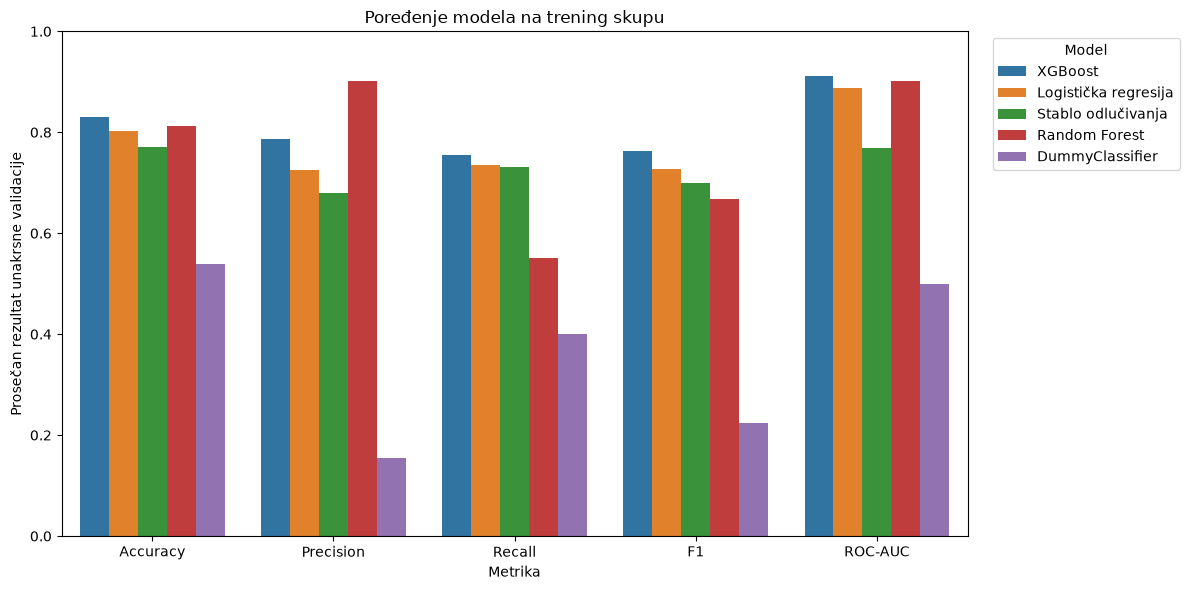

In [71]:
metrics_for_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

plot_results = cv_results_df.melt(
    id_vars="Model",
    value_vars=metrics_for_plot,
    var_name="Metrika",
    value_name="Rezultat"
)

plt.figure(figsize=(12, 6))

sb.barplot(
    data=plot_results,
    x="Metrika",
    y="Rezultat",
    hue="Model"
)

plt.ylim(0, 1)
plt.title("Poređenje modela na trening skupu")
plt.xlabel("Metrika")
plt.ylabel("Prosečan rezultat unakrsne validacije")
plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

Za početno izdvajanje uspešnijih modela posmatraju se F1 i ROC-AUC vrednosti. F1 pokazuje koliko je model uspeo da uskladi preciznost i pronalaženje otkazanih rezervacija, dok ROC-AUC opisuje njegovu sposobnost da razlikuje dve klase pri različitim pragovima odlučivanja. Konačan izbor ipak se ne zasniva samo na ove dve vrednosti, već se uzimaju u obzir i ostale metrike, stabilnost rezultata i vrste grešaka koje model pravi.

In [72]:
best_f1_row = cv_results_df.loc[cv_results_df["F1"].idxmax()]
best_roc_auc_row = cv_results_df.loc[cv_results_df["ROC-AUC"].idxmax()]

print(
    "Najveći prosečan F1 ima model",
    best_f1_row["Model"],
    "sa rezultatom",
    best_f1_row["F1"]
)

print(
    "Najveći prosečan ROC-AUC ima model",
    best_roc_auc_row["Model"],
    "sa rezultatom",
    best_roc_auc_row["ROC-AUC"]
)

Najveći prosečan F1 ima model XGBoost sa rezultatom 0.763
Najveći prosečan ROC-AUC ima model XGBoost sa rezultatom 0.9118


### 12.6. Zaključak baseline poređenja

Pobednički baseline model određuje se programatski iz sveže tabele prema prosečnom F1 rezultatu na vremenskim foldovima. Test period nije korišćen za ovo rangiranje. Rezultat zato predstavlja sposobnost modela da generalizuje sa starijih na neposredno naredne rezervacije unutar trening perioda.


## 13. Feature selection

Pobednički baseline model sa svim dozvoljenim prediktorima poredi se sa varijantama koje zadržavaju 20 i 10 najvažnijih originalnih promenljivih. Sve varijante koriste iste vremenske expanding-window foldove.


### 13.1. Metodološka zaštita od curenja podataka

Selektor je deo pipeline-a i u svakom foldu se fituje samo na starijem trening delu. Tek zatim bira promenljive i validira model na narednom vremenskom periodu. Tako validacioni period ne utiče na imputaciju, enkodovanje, skaliranje, rangiranje ili izbor promenljivih.

Poseban rang prikazan radi interpretacije fituje se na celom trening skupu, ali ne određuje fold-specifične izbore unutar unakrsne validacije i ne koristi test period.


In [73]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted


class WinningModelFeatureSelector(BaseEstimator, TransformerMixin):
    """Fold-safe izbor originalnih promenljivih pomoću pobedničkog modela."""

    def __init__(self, estimator, n_features=20):
        self.estimator = estimator
        self.n_features = n_features

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Selektor očekuje pandas DataFrame sa nazivima kolona.")

        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        identifier_columns = {"agent", "company"}

        self.numeric_features_ = [
            column
            for column in X.columns
            if pd.api.types.is_numeric_dtype(X[column])
            and column not in identifier_columns
        ]
        self.categorical_features_ = [
            column
            for column in X.columns
            if column not in self.numeric_features_
        ]

        self.selection_preprocessor_ = ColumnTransformer(
            transformers=[
                (
                    "numeric",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler())
                        ]
                    ),
                    self.numeric_features_
                ),
                (
                    "categorical",
                    Pipeline(
                        steps=[
                            (
                                "imputer",
                                SimpleImputer(strategy="most_frequent")
                            ),
                            (
                                "onehot",
                                OneHotEncoder(handle_unknown="ignore")
                            )
                        ]
                    ),
                    self.categorical_features_
                )
            ],
            sparse_threshold=1.0
        )

        selection_matrix = self.selection_preprocessor_.fit_transform(X, y)
        self.selection_estimator_ = clone(self.estimator)
        self.selection_estimator_.fit(selection_matrix, y)

        if hasattr(self.selection_estimator_, "feature_importances_"):
            transformed_importances = (
                self.selection_estimator_.feature_importances_
            )
        elif hasattr(self.selection_estimator_, "coef_"):
            transformed_importances = np.abs(
                self.selection_estimator_.coef_
            ).mean(axis=0)
        else:
            raise TypeError(
                "Pobednički model ne daje važnosti promenljivih."
            )

        numeric_slice = self.selection_preprocessor_.output_indices_["numeric"]
        categorical_slice = (
            self.selection_preprocessor_.output_indices_["categorical"]
        )
        aggregated_importances = {
            column: importance
            for column, importance in zip(
                self.numeric_features_,
                transformed_importances[numeric_slice]
            )
        }

        fitted_onehot = (
            self.selection_preprocessor_
            .named_transformers_["categorical"]
            .named_steps["onehot"]
        )
        categorical_importances = transformed_importances[categorical_slice]
        start_index = 0

        for column, categories in zip(
            self.categorical_features_,
            fitted_onehot.categories_
        ):
            end_index = start_index + len(categories)
            aggregated_importances[column] = (
                categorical_importances[start_index:end_index].sum()
            )
            start_index = end_index

        self.feature_importances_ = pd.Series(
            aggregated_importances,
            name="Važnost"
        ).sort_values(ascending=False)

        number_to_keep = min(self.n_features, len(self.feature_importances_))
        self.selected_features_ = (
            self.feature_importances_.head(number_to_keep).index.tolist()
        )
        return self

    def transform(self, X):
        check_is_fitted(self, "selected_features_")
        selected_data = X.loc[:, self.selected_features_].copy()

        # Agent i company su šifre kategorija, a ne numeričke količine.
        for column in ["agent", "company"]:
            if column in selected_data.columns:
                selected_data[column] = selected_data[column].astype(str)

        return selected_data

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, "selected_features_")
        return np.asarray(self.selected_features_, dtype=object)


winning_model_name = str(best_f1_row["Model"])
winning_estimator = clone(models[winning_model_name])
feature_counts_to_compare = [20, 10]

print("Pobednik početnog poređenja:", winning_model_name)
print("Broj svih prediktora pobedničkog modela:", X_train.shape[1])
print("Brojevi najvažnijih prediktora koji će biti provereni:", feature_counts_to_compare)
print("Test skup se ne koristi za selekciju promenljivih.")

assert winning_model_name == cv_results_df.iloc[0]["Model"]


Pobednik početnog poređenja: XGBoost
Broj svih prediktora pobedničkog modela: 34
Brojevi najvažnijih prediktora koji će biti provereni: [20, 10]
Test skup se ne koristi za selekciju promenljivih.


### 13.2. Rang promenljivih na trening skupu

Tokom unakrsne validacije svaki fold bira svoj skup najvažnijih promenljivih, pa se iz tog postupka ne dobija jedan zajednički spisak. Zato se selektor nakon poređenja dodatno trenira na celom skupu `X_train`, kako bi se prikazalo kojih 20 i 10 promenljivih smatra najvažnijim.

Ovaj spisak služi samo za prikaz i tumačenje rezultata. Ne koristi se unapred tokom unakrsne validacije i zato ne utiče na dobijene CV rezultate.


In [74]:
reporting_selector = WinningModelFeatureSelector(
    estimator=winning_estimator,
    n_features=max(feature_counts_to_compare),
)
reporting_selector.fit(X_train, y_train)

winning_model_feature_ranking = (
    reporting_selector.feature_importances_
    .rename_axis("Originalna promenljiva")
    .reset_index()
)
winning_model_feature_ranking["Rang"] = (
    np.arange(1, len(winning_model_feature_ranking) + 1)
)
winning_model_feature_ranking["Važnost"] = (
    winning_model_feature_ranking["Važnost"].round(4)
)

top_20_features = reporting_selector.selected_features_
top_10_features = top_20_features[:10]

display(
    winning_model_feature_ranking[
        ["Rang", "Originalna promenljiva", "Važnost"]
    ].head(20)
)

print("Top 20 originalnih promenljivih:")
print(top_20_features)
print("\nTop 10 originalnih promenljivih:")
print(top_10_features)


,Rang,Originalna promenljiva,Važnost
0,1,deposit_type,0.5545
1,2,agent,0.1290
2,3,country,0.0721
3,4,market_segment,0.0532
4,5,lead_time_group,0.0351
5,6,previous_cancellation_rate,0.0265
6,7,required_car_parking_spaces,0.0229
7,8,company,0.0177
8,9,customer_type,0.0147
9,10,total_of_special_requests,0.0101


Top 20 originalnih promenljivih:
['deposit_type', 'agent', 'country', 'market_segment', 'lead_time_group', 'previous_cancellation_rate', 'required_car_parking_spaces', 'company', 'customer_type', 'total_of_special_requests', 'arrival_date_month', 'distribution_channel', 'meal', 'arrival_date_year', 'reserved_room_type', 'previous_cancellations', 'hotel', 'lead_time', 'arrival_season', 'previous_bookings_not_canceled']

Top 10 originalnih promenljivih:
['deposit_type', 'agent', 'country', 'market_segment', 'lead_time_group', 'previous_cancellation_rate', 'required_car_parking_spaces', 'company', 'customer_type', 'total_of_special_requests']


### 13.3. Pipeline-i sa 20 i 10 najvažnijih promenljivih

U svakom foldu selektor može izabrati malo drugačiji skup promenljivih. Nakon izbora, preprocesor ih deli na numeričke i kategorijske. Nedostajuće numeričke vrednosti popunjava medijanom i zatim ih standardizuje, dok kategorijske vrednosti popunjava najčešćom kategorijom i pretvara pomoću one-hot kodiranja. Ovako pripremljeni podaci prosleđuju se XGBoost modelu.


In [75]:
from sklearn.compose import make_column_selector

selected_features_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]
            ),
            make_column_selector(dtype_include=np.number)
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="most_frequent")
                    ),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore")
                    )
                ]
            ),
            make_column_selector(dtype_exclude=np.number)
        )
    ]
)


def create_winner_selection_pipeline(number_of_features):
    return Pipeline(
        steps=[
            (
                "feature_selector",
                WinningModelFeatureSelector(
                    estimator=winning_estimator,
                    n_features=number_of_features
                )
            ),
            (
                "preprocessor",
                clone(selected_features_preprocessor)
            ),
            (
                "model",
                clone(winning_estimator)
            )
        ]
    )


winner_selection_pipelines = {
    f"{winning_model_name} – top 20": create_winner_selection_pipeline(20),
    f"{winning_model_name} – top 10": create_winner_selection_pipeline(10)
}

for pipeline_name, pipeline_value in winner_selection_pipelines.items():
    print(pipeline_name, "->", list(pipeline_value.named_steps.keys()))


XGBoost – top 20 -> ['feature_selector', 'preprocessor', 'model']
XGBoost – top 10 -> ['feature_selector', 'preprocessor', 'model']


### 13.4. Poređenje rezultata

Varijante sa svim, 20 i 10 originalnih promenljivih ocenjuju se na identičnim vremenskim foldovima i istim metrikama. Time razlika u rezultatu potiče od izbora promenljivih, a ne od drugačijih validacionih perioda.


In [76]:
selected_feature_cv_rows = []

for pipeline_name, pipeline_value in winner_selection_pipelines.items():
    print("Evaluacija modela:", pipeline_name)

    scores = cross_validate(
        estimator=pipeline_value,
        X=X_train,
        y=y_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=2,
        pre_dispatch=2,
        return_train_score=False
    )

    number_of_features = int(pipeline_name.split("top ")[1])
    selected_features = (
        top_20_features if number_of_features == 20 else top_10_features
    )

    selected_feature_cv_rows.append({
        "Model": pipeline_name,
        "Broj originalnih promenljivih": number_of_features,
        "Izabrane originalne promenljive": ", ".join(selected_features),
        "Accuracy": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(),
        "Precision": scores["test_precision"].mean(),
        "Precision SD": scores["test_precision"].std(),
        "Recall": scores["test_recall"].mean(),
        "Recall SD": scores["test_recall"].std(),
        "F1": scores["test_f1"].mean(),
        "F1 SD": scores["test_f1"].std(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "ROC-AUC SD": scores["test_roc_auc"].std(),
        "Vreme treniranja (s)": scores["fit_time"].mean()
    })

wide_winner_row = (
    pd.DataFrame(cross_validation_results)
    .set_index("Model")
    .loc[winning_model_name]
)

wide_model_comparison_row = {
    "Model": f"{winning_model_name} – sve promenljive",
    "Broj originalnih promenljivih": X_train.shape[1],
    "Izabrane originalne promenljive": ", ".join(X_train.columns),
    "Accuracy": float(wide_winner_row["Accuracy"]),
    "Accuracy SD": float(wide_winner_row["Accuracy SD"]),
    "Precision": float(wide_winner_row["Precision"]),
    "Precision SD": float(wide_winner_row["Precision SD"]),
    "Recall": float(wide_winner_row["Recall"]),
    "Recall SD": float(wide_winner_row["Recall SD"]),
    "F1": float(wide_winner_row["F1"]),
    "F1 SD": float(wide_winner_row["F1 SD"]),
    "ROC-AUC": float(wide_winner_row["ROC-AUC"]),
    "ROC-AUC SD": float(wide_winner_row["ROC-AUC SD"]),
    "Vreme treniranja (s)": float(
        wide_winner_row["Vreme treniranja (s)"]
    )
}

winner_feature_selection_results_raw = pd.DataFrame(
    [wide_model_comparison_row, *selected_feature_cv_rows]
)

winner_feature_selection_results = (
    winner_feature_selection_results_raw.copy()
)
numeric_result_columns = (
    winner_feature_selection_results
    .select_dtypes(include="number")
    .columns
)
winner_feature_selection_results[numeric_result_columns] = (
    winner_feature_selection_results[numeric_result_columns].round(4)
)

display(
    winner_feature_selection_results
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)


Evaluacija modela: XGBoost – top 20
Evaluacija modela: XGBoost – top 10


,Model,Broj originalnih promenljivih,Izabrane originalne promenljive,Accuracy,Accuracy SD,Precision,Precision SD,Recall,Recall SD,F1,F1 SD,ROC-AUC,ROC-AUC SD,Vreme treniranja (s)
0,XGBoost – sve promenljive,34,"hotel, lead_time, arrival_date_year, arrival_d...",0.8306,0.0306,0.7860,0.0425,0.7546,0.1194,0.7630,0.0594,0.9118,0.0253,1.6056
1,XGBoost – top 20,20,"deposit_type, agent, country, market_segment, ...",0.8136,0.0304,0.7606,0.0448,0.7312,0.1383,0.7368,0.0715,0.9024,0.0314,3.3619
2,XGBoost – top 10,10,"deposit_type, agent, country, market_segment, ...",0.7990,0.0466,0.8056,0.0324,0.5901,0.1714,0.6689,0.1234,0.8789,0.0517,2.9889


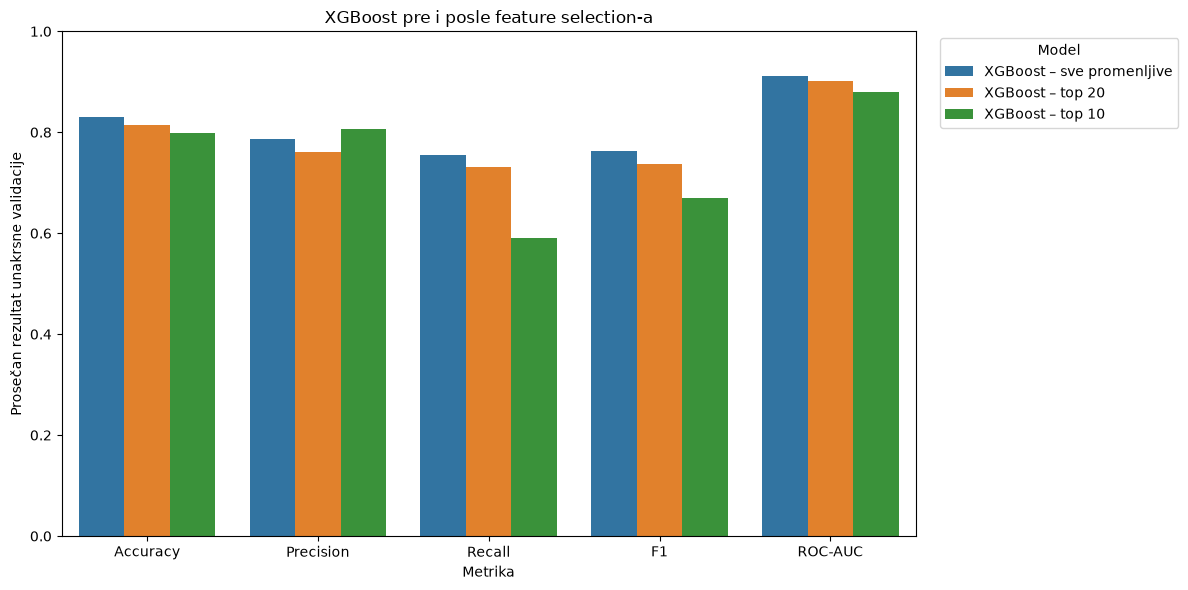

In [77]:
feature_selection_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

feature_selection_plot_data = (
    winner_feature_selection_results_raw
    .melt(
        id_vars="Model",
        value_vars=feature_selection_metrics,
        var_name="Metrika",
        value_name="Rezultat"
    )
)

plt.figure(figsize=(12, 6))
sb.barplot(
    data=feature_selection_plot_data,
    x="Metrika",
    y="Rezultat",
    hue="Model"
)
plt.ylim(0, 1)
plt.title(f"{winning_model_name} pre i posle feature selection-a")
plt.xlabel("Metrika")
plt.ylabel("Prosečan rezultat unakrsne validacije")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 13.5. Izbor najbolje varijante pobedničkog modela

Bira se varijanta sa najvećim prosečnim F1 rezultatom na pet vremenskih foldova. Ako su F1 vrednosti jednake, prednost dobija jednostavnija varijanta sa manjim brojem originalnih promenljivih. Test period ne učestvuje u odluci.


In [78]:
best_winner_result = (
    winner_feature_selection_results_raw
    .sort_values(
        by=["F1", "Broj originalnih promenljivih"],
        ascending=[False, True]
    )
    .iloc[0]
)

best_winner_variant_name = best_winner_result["Model"]
best_winner_feature_count = int(
    best_winner_result["Broj originalnih promenljivih"]
)

if best_winner_variant_name == f"{winning_model_name} – top 20":
    selected_winner_pipeline = clone(
        winner_selection_pipelines[f"{winning_model_name} – top 20"]
    )
elif best_winner_variant_name == f"{winning_model_name} – top 10":
    selected_winner_pipeline = clone(
        winner_selection_pipelines[f"{winning_model_name} – top 10"]
    )
else:
    selected_winner_pipeline = clone(model_pipelines[winning_model_name])

metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
selected_winner_cv_results = {
    metric: float(best_winner_result[metric])
    for metric in metric_names
}
selected_winner_cv_results_sd = {
    metric: float(best_winner_result[f"{metric} SD"])
    for metric in metric_names
}


In [79]:
print("Najbolja varijanta pobedničkog modela:", best_winner_variant_name)
print("Broj izabranih promenljivih:", best_winner_feature_count)
print("CV F1:", round(selected_winner_cv_results["F1"], 4))
print("CV ROC-AUC:", round(selected_winner_cv_results["ROC-AUC"], 4))
print("Test skup nije korišćen za ovaj izbor.")


Najbolja varijanta pobedničkog modela: XGBoost – sve promenljive
Broj izabranih promenljivih: 34
CV F1: 0.763
CV ROC-AUC: 0.9118
Test skup nije korišćen za ovaj izbor.


### 13.6. Zaključak feature selection-a

Izabrana varijanta i njen broj promenljivih prikazani su u prethodnom izlazu i proizlaze isključivo iz hronološke validacije trening perioda. Feature selection ostaje odvojena od feature engineering-a i nije koristila budući test period.


## 14. Cross-validation i podešavanje hiperparametara

Nakon početnog poređenja modela i feature selection-a, za dalje podešavanje bira se XGBoost varijanta sa najvećim prosečnim CV F1. Cilj je da se proveri da li promena hiperparametara može dodatno da poboljša njen F1 rezultat.

Podešavanje se vrši samo na trening skupu. Feature selection i preprocesiranje ostaju unutar pipeline-a, dok se test skup čuva za konačnu proveru.


### 14.1. Izbor modela za podešavanje

Podešava se najbolja varijanta iz prethodnog poglavlja. Odluka o modelu i broju promenljivih već je doneta samo na osnovu vremenske validacije trening skupa; test period ostaje neupotrebljen.


### 14.2. Izbor hiperparametara

U pretragu su uključeni hiperparametri koji utiču na način formiranja i složenost XGBoost modela:

- `n_estimators` određuje koliko stabala model koristi;
- `max_depth` određuje najveću dozvoljenu dubinu svakog stabla;
- `learning_rate` određuje veličinu doprinosa svakog novog stabla;
- `subsample` određuje udeo trening redova korišćenih za svako stablo;
- `colsample_bytree` određuje udeo prediktora razmatranih pri izgradnji stabla;
- `min_child_weight` ograničava formiranje podela sa premalo informacija u završnim čvorovima.

Ispred naziva svakog hiperparametra nalazi se `model__` zato što je XGBoost u okviru pipeline-a smešten u koraku koji se zove `model`. Na taj način pretraga zna da se navedeni parametri odnose upravo na XGBoost model.


In [80]:
xgboost_parameters = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [4, 6, 8],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 5]
}

number_of_combinations = np.prod([
    len(values)
    for values in xgboost_parameters.values()
])

print("Ukupan broj mogućih kombinacija:", number_of_combinations)
print("Broj kombinacija koje će biti isprobane: 6")

Ukupan broj mogućih kombinacija: 96
Broj kombinacija koje će biti isprobane: 6


Ukupno postoji 96 mogućih kombinacija hiperparametara. `RandomizedSearchCV` ispituje šest kombinacija, a svaka se ocenjuje na istih pet expanding-window foldova, odnosno kroz ukupno 30 hronoloških treniranja. Budući podaci nikada nisu deo treninga modela koji se ocenjuje na starijem periodu.


### 14.3. Pretraga pomoću RandomizedSearchCV

Pretraga koristi iste prethodno definisane vremenske indekse kao baseline poređenje i feature selection. Preprocesiranje i model nalaze se unutar pipeline-a, pa se svaki korak fituje samo na starijem delu konkretnog folda.


In [81]:
from sklearn.model_selection import RandomizedSearchCV

xgboost_search = RandomizedSearchCV(
    estimator=clone(selected_winner_pipeline),
    param_distributions=xgboost_parameters,
    n_iter=6,
    scoring=scoring_metrics,
    refit="f1",
    cv=cross_validation,
    random_state=42,
    n_jobs=2,
    pre_dispatch=2,
    verbose=2,
    return_train_score=False
)

xgboost_search.fit(X_train, y_train)

print("Pretraga na vremenskim foldovima je završena.")


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Pretraga na vremenskim foldovima je završena.


### 14.4. Najbolji pronađeni hiperparametri

Prikazuju se parametri kombinacije koja je ostvarila najveći prosečan F1. Rezultati svih isprobanih kombinacija omogućavaju da se vidi koliko se njihove metrike razlikuju.


In [82]:
print("Najbolji hiperparametri:")
for parameter, value in xgboost_search.best_params_.items():
    print(parameter, "=", value)

print(
    "\nNajbolji prosečan F1 tokom pretrage:",
    round(xgboost_search.best_score_, 4)
)

search_results_df = pd.DataFrame(
    xgboost_search.cv_results_
)

top_search_results = (
    search_results_df[[
        "rank_test_f1",
        "mean_test_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "mean_test_roc_auc",
        "params"
    ]]
    .sort_values("rank_test_f1")
    .reset_index(drop=True)
)

metric_columns = [
    column for column in top_search_results.columns
    if column.startswith("mean_test_")
]

top_search_results[metric_columns] = (
    top_search_results[metric_columns].round(4)
)

display(top_search_results)

Najbolji hiperparametri:
model__subsample = 0.8
model__n_estimators = 250
model__min_child_weight = 5
model__max_depth = 8
model__learning_rate = 0.1
model__colsample_bytree = 1.0

Najbolji prosečan F1 tokom pretrage: 0.7637


,rank_test_f1,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,params
0,1,0.8313,0.7842,0.7517,0.7637,0.9100,"{'model__subsample': 0.8, 'model__n_estimators..."
1,2,0.8283,0.7809,0.7533,0.7591,0.9111,"{'model__subsample': 1.0, 'model__n_estimators..."
2,3,0.8296,0.7912,0.7410,0.7587,0.9122,"{'model__subsample': 0.8, 'model__n_estimators..."
3,4,0.8186,0.7721,0.7299,0.7412,0.9064,"{'model__subsample': 1.0, 'model__n_estimators..."
4,5,0.8177,0.7790,0.7123,0.7334,0.9073,"{'model__subsample': 1.0, 'model__n_estimators..."
5,6,0.8157,0.7769,0.7103,0.7290,0.9056,"{'model__subsample': 1.0, 'model__n_estimators..."


Najbolji hiperparametri i odgovarajuće validacione metrike prikazani su u prethodnom sveže izračunatom izlazu. Sve kombinacije ocenjene su na istih pet hronoloških foldova trening perioda; test period nije korišćen u pretrazi.


### 14.5. Provera podešenog modela

Najbolja kombinacija iz pretrage ponovo se prikazuje kroz iste vremenske foldove radi direktnog poređenja sa nepodešenom varijantom. Test period se ni u ovom koraku ne koristi.


In [83]:
tuned_winner_model = xgboost_search.best_estimator_

tuned_scores = cross_validate(
    estimator=tuned_winner_model,
    X=X_train,
    y=y_train,
    cv=cross_validation,
    scoring=scoring_metrics,
    n_jobs=2,
    pre_dispatch=2,
    return_train_score=False
)

tuned_results = {
    "Accuracy": tuned_scores["test_accuracy"].mean(),
    "Precision": tuned_scores["test_precision"].mean(),
    "Recall": tuned_scores["test_recall"].mean(),
    "F1": tuned_scores["test_f1"].mean(),
    "ROC-AUC": tuned_scores["test_roc_auc"].mean()
}

tuned_results_sd = {
    "Accuracy": tuned_scores["test_accuracy"].std(),
    "Precision": tuned_scores["test_precision"].std(),
    "Recall": tuned_scores["test_recall"].std(),
    "F1": tuned_scores["test_f1"].std(),
    "ROC-AUC": tuned_scores["test_roc_auc"].std()
}

print("Provera podešenog modela na vremenskim foldovima je završena.")


Provera podešenog modela na vremenskim foldovima je završena.


### 14.6. Poređenje modela pre i posle podešavanja

Najbolja nepodešena varijanta i njena podešena verzija porede se prema rezultatima na istih pet hronoloških foldova. Podešeni model bira se samo ako ostvaruje veći prosečni F1. Test period ne utiče na odluku.


In [84]:
baseline_winner_model = selected_winner_cv_results
baseline_winner_model_sd = selected_winner_cv_results_sd
baseline_model_label = f"{best_winner_variant_name} pre tuninga"
tuned_model_label = f"Podešeni {best_winner_variant_name}"

comparison_rows = []

for metric in metric_names:
    baseline_value = baseline_winner_model[metric]
    tuned_value = tuned_results[metric]

    comparison_rows.append({
        "Metrika": metric,
        baseline_model_label: baseline_value,
        tuned_model_label: tuned_value,
        "Razlika": tuned_value - baseline_value,
        "SD pre tuninga": baseline_winner_model_sd[metric],
        "SD posle tuninga": tuned_results_sd[metric]
    })

winner_model_comparison = pd.DataFrame(comparison_rows)
comparison_numeric_columns = winner_model_comparison.columns.drop("Metrika")
winner_model_comparison[comparison_numeric_columns] = (
    winner_model_comparison[comparison_numeric_columns].round(4)
)

display(winner_model_comparison)


,Metrika,XGBoost – sve promenljive pre tuninga,Podešeni XGBoost – sve promenljive,Razlika,SD pre tuninga,SD posle tuninga
0,Accuracy,0.8306,0.8313,0.0007,0.0306,0.0275
1,Precision,0.7860,0.7842,-0.0018,0.0425,0.0318
2,Recall,0.7546,0.7517,-0.0029,0.1194,0.0996
3,F1,0.7630,0.7637,0.0007,0.0594,0.0558
4,ROC-AUC,0.9118,0.9100,-0.0018,0.0253,0.0255


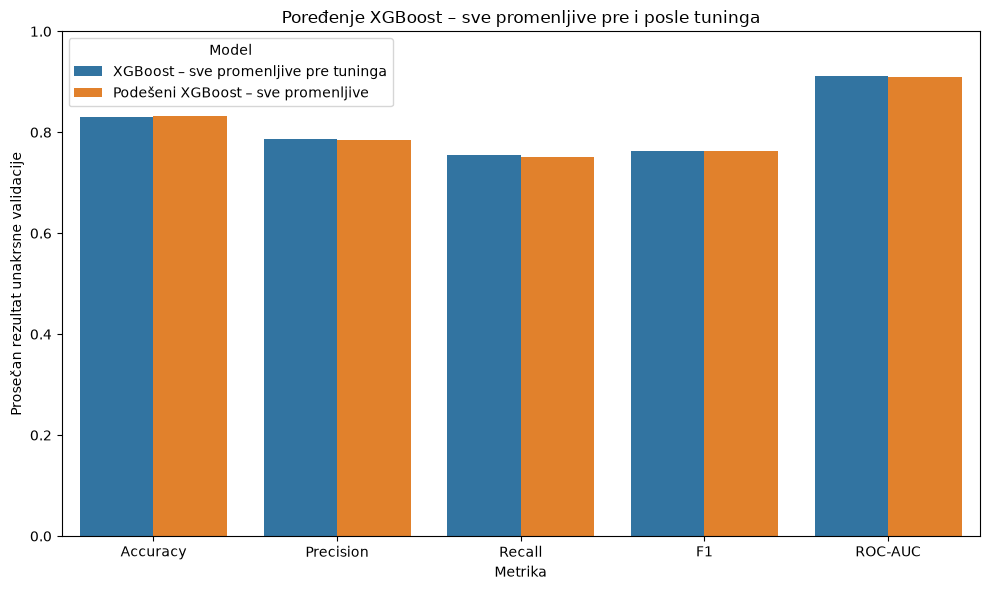

In [85]:
comparison_for_plot = winner_model_comparison.melt(
    id_vars="Metrika",
    value_vars=[
        baseline_model_label,
        tuned_model_label
    ],
    var_name="Model",
    value_name="Rezultat"
)

plt.figure(figsize=(10, 6))
sb.barplot(
    data=comparison_for_plot,
    x="Metrika",
    y="Rezultat",
    hue="Model"
)
plt.ylim(0, 1)
plt.title(f"Poređenje {best_winner_variant_name} pre i posle tuninga")
plt.xlabel("Metrika")
plt.ylabel("Prosečan rezultat unakrsne validacije")
plt.legend(title="Model")
plt.tight_layout()
plt.show()


### 14.7. Pregled promena metrika


In [86]:
improved_metrics = winner_model_comparison.loc[
    winner_model_comparison["Razlika"] > 0,
    "Metrika"
].tolist()
declined_metrics = winner_model_comparison.loc[
    winner_model_comparison["Razlika"] < 0,
    "Metrika"
].tolist()

print("Metrike poboljšane tuningom:", improved_metrics)
print("Metrike smanjene tuningom:", declined_metrics)

Metrike poboljšane tuningom: ['Accuracy', 'F1']
Metrike smanjene tuningom: ['Precision', 'Recall', 'ROC-AUC']


Prethodni izlaz programatski navodi metrike koje su se povećale ili smanjile nakon tuninga. Poređenje potiče iz novog izvršavanja na identičnim vremenskim validacionim periodima.


### 14.8. Zaključak podešavanja modela

Izbor između nepodešene i podešene varijante zasniva se samo na prosečnom F1 rezultatu vremenske validacije trening perioda. Hiperparametri, promenljive i klasifikacioni prag nisu birani na osnovu budućeg test perioda.


## 15. Finalni model i evaluacija na test skupu

Nakon izbora i podešavanja, XGBoost se prvi put ocenjuje na izdvojenom test skupu. Iako su te rezervacije ranije bile deo opisne analize celog očišćenog skupa, nisu korišćene za treniranje, izbor modela, izbor promenljivih, podešavanje hiperparametara ili određivanje pravila preprocesiranja. Zato dobijene metrike predstavljaju završnu procenu modela.

Dobijena test predviđanja u narednim poglavljima služe samo za tumačenje važnosti promenljivih i analizu grešaka. Model se na osnovu tih analiza neće dodatno menjati.


### 15.1. Izbor konačnog modela

Konačni model bira se između najbolje nepodešene i podešene varijante prema prosečnom F1 rezultatu na expanding-window validaciji. Tek nakon završetka svih odluka model se fituje na kompletnom starijem trening periodu i jednom ocenjuje na izdvojenom budućem test periodu.


In [87]:
baseline_f1 = baseline_winner_model["F1"]
tuned_f1 = tuned_results["F1"]

if tuned_f1 > baseline_f1:
    selected_model_name = f"Podešeni {best_winner_variant_name}"
    final_model = clone(tuned_winner_model)
    final_cv_results = tuned_results.copy()
    final_cv_results_sd = tuned_results_sd.copy()
else:
    selected_model_name = best_winner_variant_name
    final_model = clone(selected_winner_pipeline)
    final_cv_results = baseline_winner_model.copy()
    final_cv_results_sd = baseline_winner_model_sd.copy()

final_feature_count = best_winner_feature_count

print("Izabrani model:", selected_model_name)
print("F1 najbolje varijante pre tuninga:", round(baseline_f1, 4))
print("F1 podešene varijante:", round(tuned_f1, 4))
print("Broj promenljivih finalnog modela:", final_feature_count)
print("Test skup nije korišćen za izbor finalnog modela.")


Izabrani model: Podešeni XGBoost – sve promenljive
F1 najbolje varijante pre tuninga: 0.763
F1 podešene varijante: 0.7637
Broj promenljivih finalnog modela: 34
Test skup nije korišćen za izbor finalnog modela.


### 15.2. Treniranje modela i predviđanje

Izabrani pipeline se trenira na celom trening skupu. Pošto je puna varijanta pobedila u feature-selection poređenju, preprocesor priprema svih 34 dozvoljenih promenljivih i trenira podešeni XGBoost. Tek nakon toga model se jednom primenjuje na test skup.


In [88]:
final_model.fit(X_train, y_train)

y_test_prediction = final_model.predict(X_test)
y_test_probability = final_model.predict_proba(X_test)[:, 1]

print("Broj rezervacija u test skupu:", len(y_test))
print("Broj dobijenih predviđanja:", len(y_test_prediction))

assert len(y_test_prediction) == len(y_test)
assert len(y_test_probability) == len(y_test)
assert set(y_test_prediction).issubset({0, 1})

print("Predviđanja na test skupu su uspešno dobijena.")

Broj rezervacija u test skupu: 23555
Broj dobijenih predviđanja: 23555
Predviđanja na test skupu su uspešno dobijena.


### 15.3. Konačne vrednosti metrika

Uspešnost modela na test skupu procenjuje se istim metrikama koje su korišćene tokom unakrsne validacije. Tako se može proveriti da li je model zadržao sličan kvalitet i na podacima koji nisu učestvovali u njegovom izboru ili treniranju.

Pored osnovnih metrika prikazuje se i klasifikacioni izveštaj sa posebnim rezultatima za otkazane i neotkazane rezervacije. Posebno je značajan recall za klasu Otkazana, jer pokazuje koliki procenat stvarno otkazanih rezervacija je model uspešno prepoznao.


In [89]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

final_test_results = pd.DataFrame({
    "Metrika": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Rezultat": [
        accuracy_score(y_test, y_test_prediction),
        precision_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        recall_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        f1_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        roc_auc_score(y_test, y_test_probability)
    ]
})

final_test_results["Rezultat"] = (
    final_test_results["Rezultat"].round(4)
)

display(final_test_results)

print("Klasifikacioni izveštaj:")
print(
    classification_report(
        y_test,
        y_test_prediction,
        target_names=["Nije otkazana", "Otkazana"],
        digits=4,
        zero_division=0
    )
)

,Metrika,Rezultat
0,Accuracy,0.8104
1,Precision,0.7154
2,Recall,0.6598
3,F1,0.6865
4,ROC-AUC,0.8869


Klasifikacioni izveštaj:
               precision    recall  f1-score   support

Nije otkazana     0.8492    0.8795    0.8641     16145
     Otkazana     0.7154    0.6598    0.6865      7410

     accuracy                         0.8104     23555
    macro avg     0.7823    0.7697    0.7753     23555
 weighted avg     0.8071    0.8104    0.8082     23555



Dobijeni test rezultati porede se sa vremenskom unakrsnom validacijom. Test predstavlja kasniji period, pa razlike mogu odražavati stvarnu promenu ponašanja rezervacija kroz vreme. Rezultati testa služe isključivo konačnoj proceni i ne vraćaju se u izbor modela.


In [90]:
test_result_series = (
    final_test_results
    .set_index("Metrika")["Rezultat"]
)

validation_test_comparison = pd.DataFrame({
    "Metrika": metric_names,
    "Unakrsna validacija": [
        final_cv_results[metric] for metric in metric_names
    ],
    "CV standardna devijacija": [
        final_cv_results_sd[metric] for metric in metric_names
    ],
    "Test skup": [
        test_result_series[metric] for metric in metric_names
    ]
})

validation_test_comparison["Razlika test - CV"] = (
    validation_test_comparison["Test skup"]
    - validation_test_comparison["Unakrsna validacija"]
)

comparison_columns = validation_test_comparison.columns.drop("Metrika")
validation_test_comparison[comparison_columns] = (
    validation_test_comparison[comparison_columns].round(4)
)

display(validation_test_comparison)


,Metrika,Unakrsna validacija,CV standardna devijacija,Test skup,Razlika test - CV
0,Accuracy,0.8313,0.0275,0.8104,-0.0209
1,Precision,0.7842,0.0318,0.7154,-0.0688
2,Recall,0.7517,0.0996,0.6598,-0.0919
3,F1,0.7637,0.0558,0.6865,-0.0772
4,ROC-AUC,0.9100,0.0255,0.8869,-0.0231


Tabela iznad prikazuje sveže razlike između proseka expanding-window validacije i potpuno izdvojenog budućeg test perioda. Test rezultat nije korišćen za promenu modela, promenljivih, hiperparametara ili praga odlučivanja.


### 15.4. Matrica konfuzije

Matrica konfuzije prikazuje broj tačno i pogrešno klasifikovanih rezervacija. Posebno su važne otkazane rezervacije koje je model označio kao neotkazane, jer predstavljaju otkazivanja koja model nije uspeo da prepozna. Sa druge strane, neotkazane rezervacije označene kao otkazane predstavljaju lažna upozorenja.


,Broj rezervacija
Tačno prepoznate neotkazane rezervacije,14200
Neotkazane pogrešno označene kao otkazane,1945
Propuštene otkazane rezervacije,2521
Tačno prepoznate otkazane rezervacije,4889


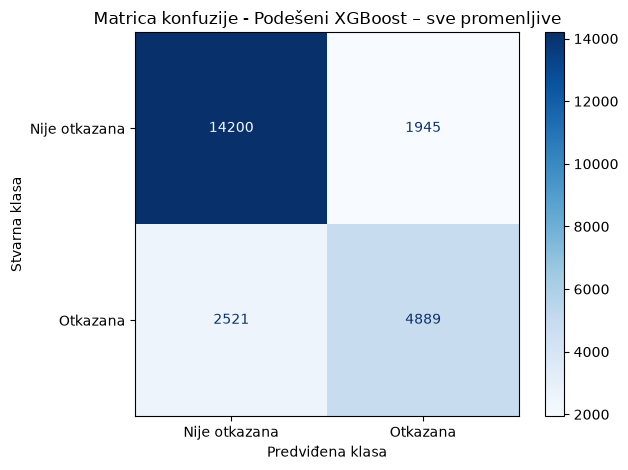

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

confusion_values = confusion_matrix(
    y_test,
    y_test_prediction
)

tn, fp, fn, tp = confusion_values.ravel()

confusion_summary = pd.Series({
    "Tačno prepoznate neotkazane rezervacije": tn,
    "Neotkazane pogrešno označene kao otkazane": fp,
    "Propuštene otkazane rezervacije": fn,
    "Tačno prepoznate otkazane rezervacije": tp
})

display(confusion_summary.to_frame("Broj rezervacija"))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_values,
    display_labels=["Nije otkazana", "Otkazana"]
).plot(
    cmap="Blues",
    values_format="d"
)

plt.title(f"Matrica konfuzije - {selected_model_name}")
plt.xlabel("Predviđena klasa")
plt.ylabel("Stvarna klasa")
plt.tight_layout()
plt.show()

Matrica konfuzije prikazuje sveže izračunate brojeve tačno i pogrešno klasifikovanih rezervacija u budućem test periodu. Ovi redovi nisu korišćeni ni u jednoj odluci tokom treniranja i izbora modela.


### 15.5. ROC kriva

ROC kriva prikazuje odnos između udela pravilno prepoznatih otkazivanja i udela neotkazanih rezervacija koje su pogrešno označene kao otkazane pri različitim pragovima odlučivanja. Što je kriva bliža gornjem levom uglu, model bolje razdvaja dve klase. Isprekidana dijagonala predstavlja rezultat nasumičnog razvrstavanja.


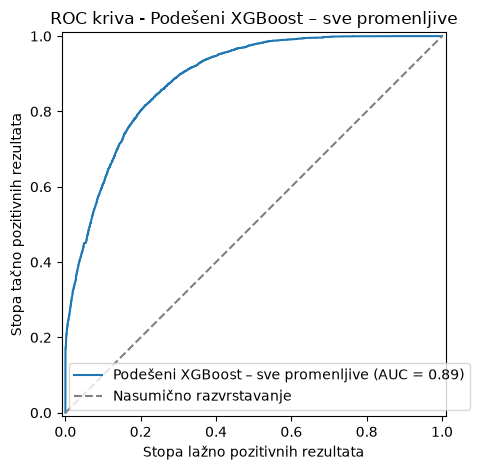

In [92]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_test_probability,
    name=selected_model_name
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Nasumično razvrstavanje"
)
plt.title(f"ROC kriva - {selected_model_name}")
plt.xlabel("Stopa lažno pozitivnih rezultata")
plt.ylabel("Stopa tačno pozitivnih rezultata")
plt.legend()
plt.tight_layout()
plt.show()

ROC kriva i ROC-AUC iz prethodnog izlaza opisuju sposobnost konačnog modela da rangira otkazane iznad neotkazanih rezervacija u budućem test periodu.


### 15.6. Precision–recall kriva

Pored ROC krive, korisno je prikazati i precision–recall krivu. Ona pokazuje kako se menjaju precision i recall vrednosti kada se promeni prag na osnovu kojeg model označava rezervaciju kao otkazanu. Veći recall znači da model pronalazi više stvarnih otkazivanja, dok veći precision znači da je veći deo njegovih upozorenja tačan.

Vrednost `Average Precision` sažima odnos precision i recall rezultata kroz sve posmatrane pragove, pri čemu rezultat bliži jedinici označava uspešniji model. Isprekidana horizontalna linija predstavlja početnu referencu, odnosno udeo otkazanih rezervacija u test skupu.


Average Precision: 0.7866
Udeo otkazanih rezervacija u test skupu: 0.3146


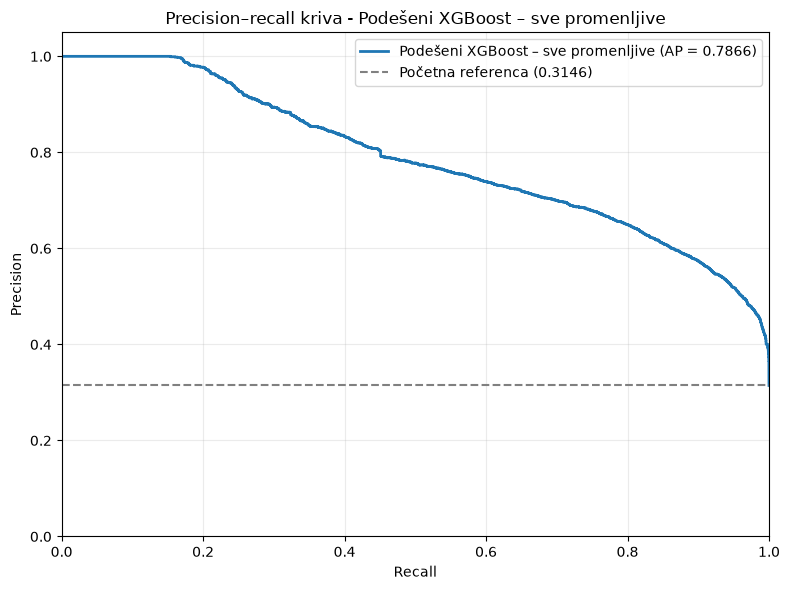

In [93]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve
)

precision_values, recall_values, _ = precision_recall_curve(
    y_test,
    y_test_probability
)

average_precision = average_precision_score(
    y_test,
    y_test_probability
)

cancellation_share = y_test.mean()

print(
    "Average Precision:",
    round(average_precision, 4)
)
print(
    "Udeo otkazanih rezervacija u test skupu:",
    round(cancellation_share, 4)
)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_values,
    precision_values,
    color="#1f77b4",
    linewidth=2,
    label=(
        f"{selected_model_name} "
        f"(AP = {average_precision:.4f})"
    )
)
plt.axhline(
    y=cancellation_share,
    color="gray",
    linestyle="--",
    label=(
        "Početna referenca "
        f"({cancellation_share:.4f})"
    )
)
plt.title(
    f"Precision–recall kriva - {selected_model_name}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Precision–recall kriva i Average Precision prikazuju kvalitet rangiranja pozitivne klase u izdvojenom budućem periodu. Rezultat se koristi samo za završno tumačenje modela, ne za izbor praga ili ponovno podešavanje.


### 15.7. Zaključak konačne procene

Konačne metrike, krive i matrica konfuzije izračunate su tek nakon što su izbor modela, promenljivih i hiperparametara završeni na vremenskim foldovima trening skupa. Test period predstavlja rezervacije kreirane kasnije i nije korišćen za naknadne metodološke odluke.


### 15.8. Analiza važnosti promenljivih

Nakon procene uspešnosti modela, proverava se koje su promenljive imale najveći značaj za predviđanja. Ova analiza pomaže da bolje razumemo na koje informacije se model najviše oslanja kada procenjuje da li će rezervacija biti otkazana.

Važno je naglasiti da velika važnost neke promenljive ne znači da ona direktno izaziva otkazivanje. Ona samo pokazuje da je model tu promenljivu često koristio prilikom razlikovanja otkazanih i neotkazanih rezervacija.


#### 15.8.1. Važnost prediktora u konačnom modelu


In [94]:
fitted_preprocessor = final_model.named_steps["preprocessor"]
fitted_prediction_model = final_model.named_steps["model"]

if "feature_selector" in final_model.named_steps:
    fitted_feature_selector = final_model.named_steps["feature_selector"]
    final_selected_features = fitted_feature_selector.selected_features_
else:
    fitted_feature_selector = None
    final_selected_features = X_train.columns.tolist()

transformed_feature_names = fitted_preprocessor.get_feature_names_out()
feature_importance_values = fitted_prediction_model.feature_importances_

transformed_feature_importance = pd.DataFrame({
    "Prediktor": transformed_feature_names,
    "Važnost": feature_importance_values
})
transformed_feature_importance["Prediktor"] = (
    transformed_feature_importance["Prediktor"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)
transformed_feature_importance = (
    transformed_feature_importance
    .sort_values("Važnost", ascending=False)
    .reset_index(drop=True)
)
transformed_feature_importance["Važnost"] = (
    transformed_feature_importance["Važnost"].round(4)
)

print("Originalne promenljive izabrane u finalnom pipeline-u:")
print(final_selected_features)
display(transformed_feature_importance.head(20))

assert len(final_selected_features) == final_feature_count
assert len(transformed_feature_names) == len(feature_importance_values)
assert np.isclose(feature_importance_values.sum(), 1.0)


Originalne promenljive izabrane u finalnom pipeline-u:
['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'deposit_type', 'agent', 'company', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay', 'total_guests', 'has_children_or_babies', 'total_previous_bookings', 'has_booking_history', 'previous_cancellation_rate', 'arrival_season', 'lead_time_group']


,Prediktor,Važnost
0,deposit_type_Non Refund,0.4176
1,market_segment_Online TA,0.0555
2,previous_cancellation_rate,0.0486
3,required_car_parking_spaces,0.0326
4,country_PRT,0.0234
5,agent_17,0.0164
6,agent_11,0.0147
7,agent_9,0.0127
8,total_of_special_requests,0.0117
9,agent_7,0.0111


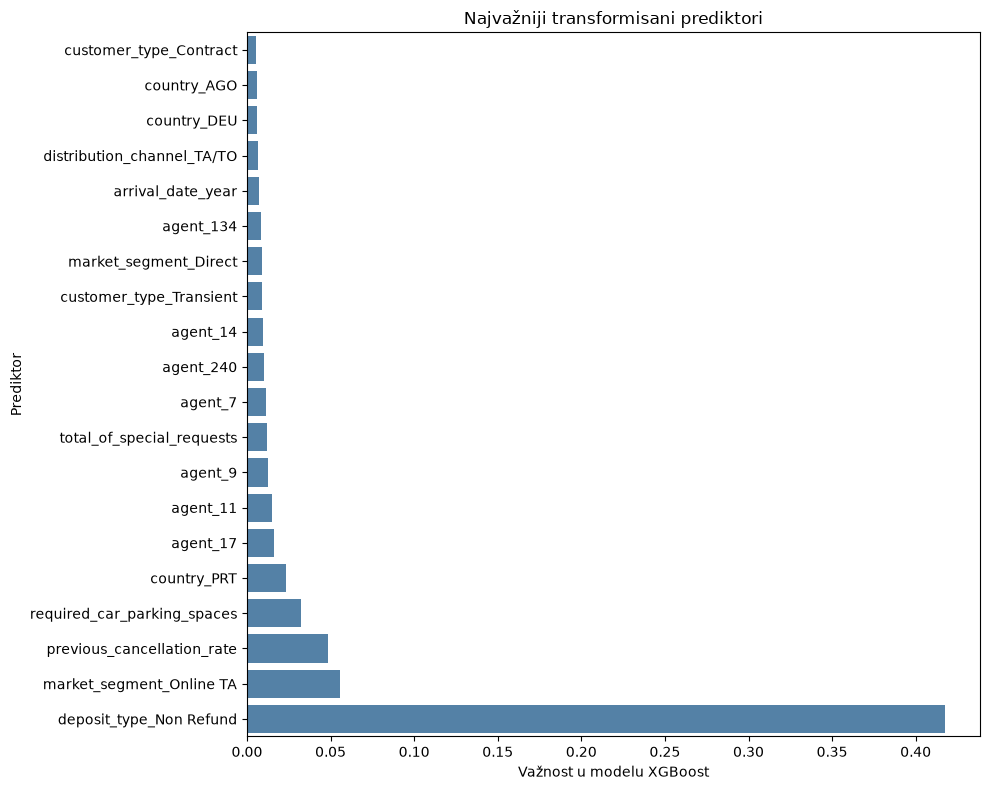

In [95]:
top_transformed_features = (
    transformed_feature_importance.head(20)
    .sort_values("Važnost", ascending=True)
)

plt.figure(figsize=(10, 8))
sb.barplot(
    data=top_transformed_features,
    x="Važnost",
    y="Prediktor",
    color="steelblue"
)
plt.title("Najvažniji transformisani prediktori")
plt.xlabel(f"Važnost u modelu {winning_model_name}")
plt.ylabel("Prediktor")
plt.tight_layout()
plt.show()

Tabela i grafikon prikazuju najvažnije transformisane prediktore konačnog modela iz ovog izvršavanja. Kod kategorijskih promenljivih svaka kategorija je prikazana posebno, pa se u nastavku njihove važnosti sabiraju prema originalnim kolonama.


#### 15.8.2. Zbirna važnost originalnih promenljivih

Posmatranje pojedinačnih one-hot kolona može umanjiti značaj kategorijske promenljive, jer se njena ukupna važnost deli između više kategorija. Zbog toga se važnosti svih kategorija koje pripadaju istoj originalnoj koloni sabiraju. Numeričke promenljive već imaju po jednu transformisanu kolonu, pa njihova važnost ostaje nepromenjena.


In [96]:
numeric_output_slice = fitted_preprocessor.output_indices_["numeric"]
categorical_output_slice = fitted_preprocessor.output_indices_["categorical"]

selected_numeric_columns = [
    column
    for column in final_selected_features
    if pd.api.types.is_numeric_dtype(X_train[column])
    and column not in ["agent", "company"]
]
selected_categorical_columns = [
    column
    for column in final_selected_features
    if column not in selected_numeric_columns
]

aggregated_importance = {
    column: importance
    for column, importance in zip(
        selected_numeric_columns,
        feature_importance_values[numeric_output_slice]
    )
}

fitted_onehot = (
    fitted_preprocessor
    .named_transformers_["categorical"]
    .named_steps["onehot"]
)
categorical_importance_values = feature_importance_values[
    categorical_output_slice
]

start_index = 0
for column, categories in zip(
    selected_categorical_columns,
    fitted_onehot.categories_
):
    end_index = start_index + len(categories)
    aggregated_importance[column] = (
        categorical_importance_values[start_index:end_index].sum()
    )
    start_index = end_index

original_feature_importance = pd.DataFrame({
    "Promenljiva": aggregated_importance.keys(),
    "Zbirna važnost": aggregated_importance.values()
})
original_feature_importance = (
    original_feature_importance
    .sort_values("Zbirna važnost", ascending=False)
    .reset_index(drop=True)
)
original_feature_importance["Zbirna važnost"] = (
    original_feature_importance["Zbirna važnost"].round(4)
)

display(original_feature_importance.head(15))

assert start_index == len(categorical_importance_values)
assert np.isclose(sum(aggregated_importance.values()), 1.0)


,Promenljiva,Zbirna važnost
0,deposit_type,0.4185
1,arrival_season,0.1870
2,country,0.0947
3,market_segment,0.0721
4,previous_cancellation_rate,0.0486
5,required_car_parking_spaces,0.0326
6,arrival_date_month,0.0188
7,agent,0.0180
8,meal,0.0137
9,distribution_channel,0.0130


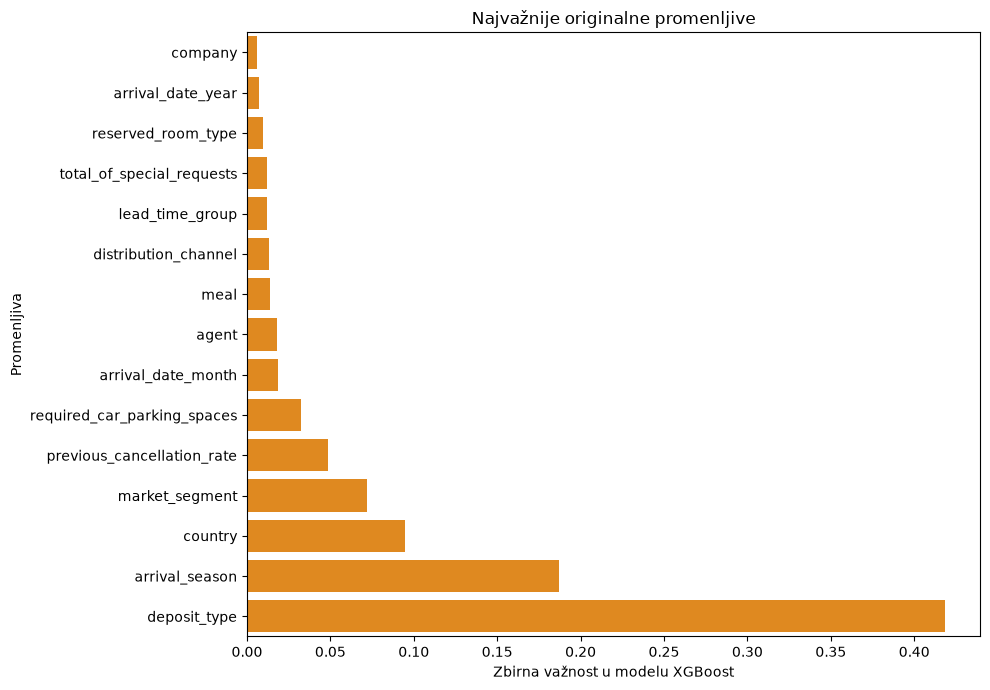

In [97]:
top_original_features = (
    original_feature_importance.head(15)
    .sort_values("Zbirna važnost", ascending=True)
)

plt.figure(figsize=(10, 7))
sb.barplot(
    data=top_original_features,
    x="Zbirna važnost",
    y="Promenljiva",
    color="darkorange"
)
plt.title("Najvažnije originalne promenljive")
plt.xlabel(f"Zbirna važnost u modelu {winning_model_name}")
plt.ylabel("Promenljiva")
plt.tight_layout()
plt.show()

Zbirna važnost omogućava ravnopravnije poređenje originalnih kategorijskih i numeričkih promenljivih. Aktuelni rang i vrednosti prikazani su u prethodnom sveže izračunatom izlazu.


#### 15.8.3. Permutaciona važnost promenljivih

Kao dodatna provera koristi se permutaciona važnost, jer ugrađena važnost modela zasnovanog na stablima može drugačije rangirati promenljive od mere koja direktno prati promenu kvaliteta predviđanja.

Ova metoda funkcioniše tako što se vrednosti jedne promenljive nasumično izmešaju, dok svi ostali podaci ostaju isti. Zatim se ponovo izračunava ROC-AUC rezultat. Ako se rezultat primetno smanji, to znači da je ta promenljiva bila važna za predviđanje modela. Ako rezultat ostane skoro isti, model se nije mnogo oslanjao na nju.

Da bi se analiza brže izvršila, permutaciona važnost računa se na jednom delu test skupa. Ona služi samo za bolje razumevanje modela i ne utiče na njegovo treniranje niti na izbor hiperparametara.


In [98]:
from sklearn.inspection import permutation_importance

permutation_sample_size = min(5000, len(X_test))

permutation_sample_indices = X_test.sample(
    n=permutation_sample_size,
    random_state=42
).index

X_permutation = X_test.loc[permutation_sample_indices]
y_permutation = y_test.loc[permutation_sample_indices]

permutation_results = permutation_importance(
    estimator=final_model,
    X=X_permutation,
    y=y_permutation,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

permutation_importance_df = pd.DataFrame({
    "Promenljiva": X_test.columns,
    "Prosečan pad ROC-AUC": permutation_results.importances_mean,
    "Standardna devijacija": permutation_results.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values("Prosečan pad ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

permutation_importance_df[[
    "Prosečan pad ROC-AUC",
    "Standardna devijacija"
]] = permutation_importance_df[[
    "Prosečan pad ROC-AUC",
    "Standardna devijacija"
]].round(4)

display(permutation_importance_df.head(15))

,Promenljiva,Prosečan pad ROC-AUC,Standardna devijacija
0,country,0.0939,0.0016
1,agent,0.0812,0.0035
2,lead_time,0.0502,0.0044
3,deposit_type,0.0474,0.0029
4,required_car_parking_spaces,0.0469,0.0042
5,market_segment,0.0429,0.0030
6,total_of_special_requests,0.0410,0.0020
7,customer_type,0.0211,0.0014
8,previous_bookings_not_canceled,0.0091,0.0019
9,previous_cancellation_rate,0.0038,0.0005


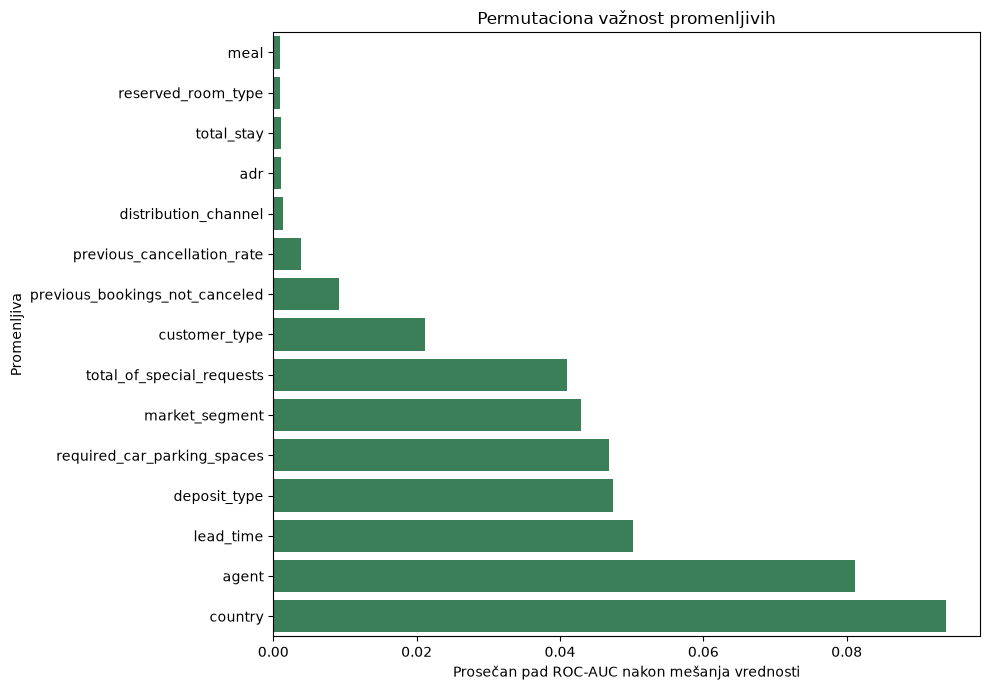

In [99]:
top_permutation_features = (
    permutation_importance_df.head(15)
    .sort_values("Prosečan pad ROC-AUC", ascending=True)
)

plt.figure(figsize=(10, 7))
sb.barplot(
    data=top_permutation_features,
    x="Prosečan pad ROC-AUC",
    y="Promenljiva",
    color="seagreen"
)
plt.title("Permutaciona važnost promenljivih")
plt.xlabel("Prosečan pad ROC-AUC nakon mešanja vrednosti")
plt.ylabel("Promenljiva")
plt.tight_layout()
plt.show()

Permutaciona važnost meri pad ROC-AUC nakon mešanja pojedinačne originalne promenljive u završnom test periodu. Aktuelni rang, prosečan pad i varijabilnost prikazani su u prethodnom izlazu.


#### 15.8.4. Poređenje dobijenih rezultata

Ugrađena i permutaciona važnost ne daju uvek isti redosled promenljivih jer mere različite stvari. Ugrađena važnost pokazuje koliko je promenljiva doprinela podelama u XGBoost stablima, dok permutaciona važnost pokazuje koliko se rezultat smanji kada se njene vrednosti nasumično izmešaju.

Promenljive koje su visoko rangirane prema obe metode posebno su značajne za predviđanja modela. Kod međusobno povezanih prediktora važnost ipak može biti podeljena između više kolona, naročito kada originalna i izvedena promenljiva opisuju sličnu informaciju.


In [100]:
importance_ranking_comparison = (
    original_feature_importance[[
        "Promenljiva",
        "Zbirna važnost"
    ]]
    .merge(
        permutation_importance_df[[
            "Promenljiva",
            "Prosečan pad ROC-AUC"
        ]],
        on="Promenljiva",
        how="inner"
    )
)

importance_ranking_comparison[f"Rang {winning_model_name}"] = (
    importance_ranking_comparison["Zbirna važnost"]
    .rank(ascending=False, method="min")
    .astype(int)
)

importance_ranking_comparison["Rang permutacije"] = (
    importance_ranking_comparison["Prosečan pad ROC-AUC"]
    .rank(ascending=False, method="min")
    .astype(int)
)

importance_ranking_comparison["Prosečan rang"] = (
    importance_ranking_comparison[[
        f"Rang {winning_model_name}",
        "Rang permutacije"
    ]].mean(axis=1)
)

importance_ranking_comparison = (
    importance_ranking_comparison
    .sort_values("Prosečan rang")
    .reset_index(drop=True)
)

display(importance_ranking_comparison.head(15))

,Promenljiva,Zbirna važnost,Prosečan pad ROC-AUC,Rang XGBoost,Rang permutacije,Prosečan rang
0,country,0.0947,0.0939,3,1,2.0
1,deposit_type,0.4185,0.0474,1,4,2.5
2,market_segment,0.0721,0.0429,4,6,5.0
3,agent,0.0180,0.0812,8,2,5.0
4,required_car_parking_spaces,0.0326,0.0469,6,5,5.5
5,previous_cancellation_rate,0.0486,0.0038,5,10,7.5
6,total_of_special_requests,0.0117,0.0410,12,7,9.5
7,lead_time,0.0041,0.0502,17,3,10.0
8,distribution_channel,0.0130,0.0014,10,11,10.5
9,meal,0.0137,0.0009,9,15,12.0


Poređenje ugrađene i permutacione važnosti pokazuje u kojoj meri se rangovi podudaraju. Razlike su očekivane jer ugrađena važnost opisuje način na koji je model konstruisan, dok permutaciona važnost meri promenu performansi na budućem test periodu.


#### 15.8.5. Zaključak analize važnosti promenljivih

Važnost promenljivih tumači se iz oba prikazana pristupa i odnosi se na konačni model iz ovog izvršavanja. Ona ne dokazuje uzročnost i nije korišćena za naknadnu promenu već ocenjenog modela.


### 15.9. Ograničenja analize i modela

Dobijeni rezultati pokazuju da model može prilično uspešno da predvidi otkazivanje hotelskih rezervacija. Ipak, rezultate treba posmatrati u okviru podataka koji su korišćeni u ovom radu. Zbog toga je važno navesti ograničenja analize i uslove koje bi trebalo uzeti u obzir pre moguće primene modela.


#### 15.9.1. Ograničenja skupa podataka

Korišćeni podaci obuhvataju rezervacije samo dva hotela – jednog gradskog i jednog odmarališnog. Obrasci koje je model naučio zato ne moraju biti isti u hotelima iz drugih država, objektima drugačije veličine ili hotelima sa drugačijom strukturom gostiju. Pre primene u drugom hotelu bilo bi potrebno proveriti model na njegovim podacima.

Rezervacije su prikupljene u periodu od 2015. do 2017. godine, pri čemu podaci za 2015. i 2017. godinu ne obuhvataju svih dvanaest meseci. Navike gostiju, načini rezervisanja, cene i tržišni kanali menjaju se tokom vremena, pa rezultati dobijeni na ovom skupu ne moraju u potpunosti odgovarati današnjim uslovima.

U podacima postoji informacija o tome da li je rezervacija otkazana, ali ne i razlog otkazivanja. Zbog toga nije moguće utvrditi da li je gost rezervaciju otkazao zbog promene plana, cene, vremenskih uslova ili nekog drugog razloga. Takođe nisu dostupne neke informacije koje bi mogle biti korisne, kao što su podaci o promocijama, cenama konkurencije i komunikaciji sa gostima.


#### 15.9.2. Ograničenja čišćenja i kreiranja promenljivih

Pre vremenske podele uklonjeno je 180 zapisa bez evidentiranih gostiju kao unapred određena sistemska korekcija. Posle podele, ADR granice od 0,00 do 272,70 naučene su samo na trening periodu; njihovom primenom uklonjeno je 263 trening i 377 test zapisa. Konzervativno IQR pravilo smanjuje uticaj ekstremnih vrednosti, ali može izdvojiti i retke validne rezervacije.

Nedostajuće vrednosti obrađene su u skladu sa značenjem pojedinačnih kolona. U pipeline-u je dodatno primenjeno popunjavanje numeričkih vrednosti medijanom, a kategorijskih najčešćom vrednošću. Ove statistike fituju se samo na starijem trening delu odgovarajućeg koraka, ali popunjena vrednost ne mora uvek odgovarati stvarnoj vrednosti koja je nedostajala.

Neke izvedene promenljive sadrže slične informacije kao originalne kolone. Na primer, `lead_time_group` nastaje iz `lead_time`, dok je `total_stay` zbir dve kolone noćenja. Model zato može raspodeliti značaj između povezanih kolona, što treba uzeti u obzir pri tumačenju važnosti.


#### 15.9.3. Ograničenja trenutka predviđanja

U radu je pretpostavljeno da se predviđanje vrši odmah nakon kreiranja rezervacije. Zbog toga model ne koristi `assigned_room_type`, `booking_changes` i `days_in_waiting_list`, jer njihove konačne vrednosti u tom trenutku nisu pouzdano poznate. Na ovaj način smanjuje se mogućnost curenja podataka i omogućava rano predviđanje otkazivanja. Međutim, model zbog toga ne koristi informacije koje bi mogle postati dostupne kasnije i dodatno poboljšati predviđanje.

U stvarnoj primeni mogao bi se napraviti još jedan model koji bi ponovo procenjivao mogućnost otkazivanja nekoliko dana pre dolaska gosta. Takav model mogao bi da koristi novije informacije, ali bi morao posebno da se trenira i proverava za taj trenutak predviđanja.


#### 15.9.4. Ograničenja modela i evaluacije

Konačni model ne klasifikuje sve rezervacije tačno, a odnos grešaka može se menjati kroz vreme. Model je izabran prema F1 vrednosti, dok hotel u praksi može imati drugačije troškove lažnih upozorenja i propuštenih otkazivanja.

Hronološka podela simulira predviđanje budućih rezervacija na osnovu starijih, ali daje samo jedan završni test period. Expanding-window validacija ublažava zavisnost od jedne granice unutar trening perioda, dok bi za praktičnu primenu bilo potrebno periodično ponovno testiranje na novijim podacima. Pretraga hiperparametara obuhvata šest od 96 kombinacija, pa prostor nije iscrpno pretražen.


#### 15.9.5. Tumačenje i praktična primena

XGBoost može da prepozna složene odnose između različitih podataka o rezervaciji, ali je njegove odluke teže objasniti nego odluke logističke regresije ili jednog stabla odlučivanja. Analiza važnosti promenljivih pokazuje koje podatke model najviše koristi, ali ne objašnjava uvek na koji način oni utiču na pojedinačno predviđanje.

Važnost promenljive takođe ne predstavlja dokaz da ona direktno izaziva otkazivanje. Na primer, `deposit_type` ili `country` mogu biti veoma korisni za predviđanje, ali se samo na osnovu modela ne može zaključiti da su oni uzrok otkazivanja. Rezultati pokazuju povezanosti koje postoje u korišćenom skupu podataka.

Promenljiva `country` pokazala se kao važna za predviđanje, ali to ne znači da sama država iz koje gost dolazi određuje da li će rezervacija biti otkazana. Ovu informaciju treba posmatrati zajedno sa ostalim podacima i ne koristiti je kao osnov za drugačiji tretman gostiju.

Pre praktične upotrebe model bi trebalo proveriti na novijim rezervacijama i podacima hotela u kojem bi se koristio. Njegove rezultate trebalo bi redovno pratiti, a model povremeno ponovo trenirati kako bi se prilagodio promenama u ponašanju gostiju. Predviđanja bi trebalo da služe kao pomoć zaposlenima, a ne kao jedini osnov za donošenje odluka.


#### 15.9.6. Zaključak ograničenja

Najvažnija ograničenja odnose se na mali broj hotela, starost podataka, nedostatak razloga otkazivanja i promene obrazaca kroz vreme. Slabiji rezultat na budućem test periodu u odnosu na prosečnu vremensku validaciju pokazuje zašto je hronološka procena važna i zašto bi model trebalo redovno proveravati i obnavljati.

Rezultate treba posmatrati kao procenu prediktivne vrednosti dostupnih informacija u posmatranom periodu, a ne kao univerzalno pravilo za svaku hotelsku rezervaciju.


### 15.10. Analiza grešaka modela

Konačne metrike pokazuju koliko je model uspešan u celini, ali ne otkrivaju kod kakvih rezervacija najčešće pravi greške. Zbog toga će u ovom poglavlju posebno biti analizirana otkazivanja koja model nije prepoznao, kao i neotkazane rezervacije koje je pogrešno označio kao otkazane.

Za ovu analizu koriste se već dobijena predviđanja na test skupu. Dobijeni rezultati služe samo za bolje razumevanje grešaka i neće se koristiti za dodatno podešavanje modela.


#### 15.10.1. Formiranje grupa prema rezultatu predviđanja

Svaka rezervacija iz test skupa svrstava se u jednu od četiri grupe:

- tačno prepoznata neotkazana rezervacija;
- lažno upozorenje, kada je neotkazana rezervacija označena kao otkazana;
- propušteno otkazivanje, kada je otkazana rezervacija označena kao neotkazana;
- tačno prepoznata otkazana rezervacija.

Pored stvarne i predviđene klase čuva se i procenjena verovatnoća otkazivanja, što omogućava da se vidi koliko je model bio siguran u tačna i pogrešna predviđanja.


In [101]:
error_analysis_df = X_test.copy()

error_analysis_df["Stvarna klasa"] = y_test
error_analysis_df["Predviđena klasa"] = y_test_prediction
error_analysis_df["Verovatnoća otkazivanja"] = y_test_probability

error_conditions = [
    (
        (error_analysis_df["Stvarna klasa"] == 0)
        & (error_analysis_df["Predviđena klasa"] == 0)
    ),
    (
        (error_analysis_df["Stvarna klasa"] == 0)
        & (error_analysis_df["Predviđena klasa"] == 1)
    ),
    (
        (error_analysis_df["Stvarna klasa"] == 1)
        & (error_analysis_df["Predviđena klasa"] == 0)
    ),
    (
        (error_analysis_df["Stvarna klasa"] == 1)
        & (error_analysis_df["Predviđena klasa"] == 1)
    )
]

error_labels = [
    "Tačno prepoznata neotkazana",
    "Lažno upozorenje",
    "Propušteno otkazivanje",
    "Tačno prepoznata otkazana"
]

error_analysis_df["Ishod predviđanja"] = np.select(
    error_conditions,
    error_labels,
    default="Nepoznato"
)

assert not (error_analysis_df["Ishod predviđanja"] == "Nepoznato").any()
assert len(error_analysis_df) == len(X_test)

print("Podaci za analizu grešaka su uspešno pripremljeni.")

Podaci za analizu grešaka su uspešno pripremljeni.


,Ishod predviđanja,Broj rezervacija,Udeo u test skupu (%)
0,Tačno prepoznata neotkazana,14200,60.28
1,Lažno upozorenje,1945,8.26
2,Propušteno otkazivanje,2521,10.70
3,Tačno prepoznata otkazana,4889,20.76


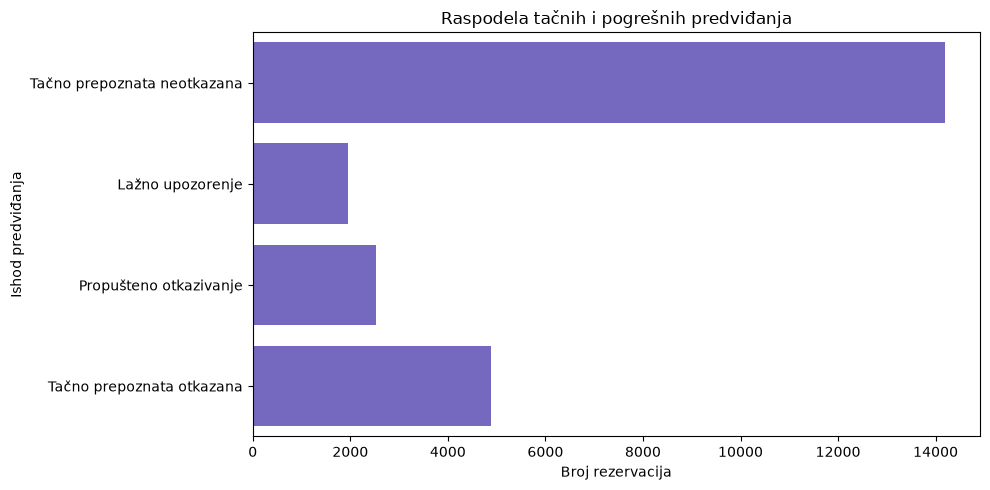

In [102]:
error_group_summary = (
    error_analysis_df["Ishod predviđanja"]
    .value_counts()
    .reindex(error_labels)
    .rename_axis("Ishod predviđanja")
    .reset_index(name="Broj rezervacija")
)

error_group_summary["Udeo u test skupu (%)"] = (
    error_group_summary["Broj rezervacija"]
    / len(error_analysis_df) * 100
).round(2)

display(error_group_summary)

plt.figure(figsize=(10, 5))
sb.barplot(
    data=error_group_summary,
    x="Broj rezervacija",
    y="Ishod predviđanja",
    color="slateblue"
)
plt.title("Raspodela tačnih i pogrešnih predviđanja")
plt.xlabel("Broj rezervacija")
plt.ylabel("Ishod predviđanja")
plt.tight_layout()
plt.show()

Tabela prikazuje broj i udeo tačnih i pogrešnih predviđanja konačnog modela u budućem test periodu. Broj tačnih predviđanja treba posmatrati zajedno sa lažnim upozorenjima i propuštenim otkazivanjima.


#### 15.10.2. Verovatnoće kod tačnih i pogrešnih predviđanja

Kod rezervacija koje se nalaze blizu praga od 0,5 model je manje siguran kojoj klasi pripadaju. Poređenjem procenjenih verovatnoća može se proveriti da li su pogrešna predviđanja uglavnom nastala kod takvih graničnih slučajeva ili je model kod nekih grešaka bio izrazito siguran.


,Ishod predviđanja,count,mean,median,min,max
0,Tačno prepoznata neotkazana,14200,0.1165,0.0576,0.0000,0.4998
1,Lažno upozorenje,1945,0.6817,0.6827,0.5003,0.9970
2,Propušteno otkazivanje,2521,0.2995,0.3107,0.0023,0.4999
3,Tačno prepoznata otkazana,4889,0.7936,0.7937,0.5002,0.9998


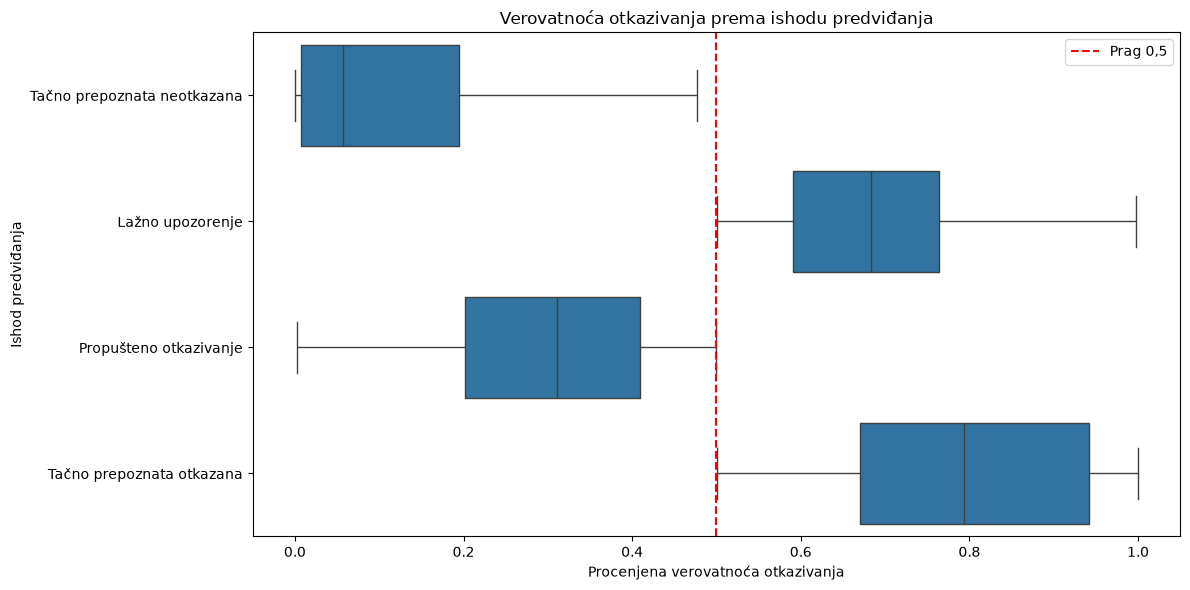

In [103]:
probability_by_outcome = (
    error_analysis_df
    .groupby("Ishod predviđanja", observed=True)
    ["Verovatnoća otkazivanja"]
    .agg(["count", "mean", "median", "min", "max"])
    .reindex(error_labels)
    .reset_index()
)

probability_by_outcome[[
    "mean", "median", "min", "max"
]] = probability_by_outcome[[
    "mean", "median", "min", "max"
]].round(4)

display(probability_by_outcome)

plt.figure(figsize=(12, 6))
sb.boxplot(
    data=error_analysis_df,
    x="Verovatnoća otkazivanja",
    y="Ishod predviđanja",
    order=error_labels,
    showfliers=False
)
plt.axvline(0.5, color="red", linestyle="--", label="Prag 0,5")
plt.title("Verovatnoća otkazivanja prema ishodu predviđanja")
plt.xlabel("Procenjena verovatnoća otkazivanja")
plt.ylabel("Ishod predviđanja")
plt.legend()
plt.tight_layout()
plt.show()

Prikazane verovatnoće pokazuju koliko je model bio siguran kod tačnih i pogrešnih predviđanja. Greške bliže pragu od 0,5 predstavljaju slučajeve kod kojih je model bio manje siguran.


#### 15.10.3. Greške prema odabranim grupama rezervacija

Posmatrane grupe nemaju isti broj rezervacija, zbog čega samo poređenje ukupnog broja grešaka ne bi bilo dovoljno. Zato se računa procenat stvarno otkazanih rezervacija koje model nije prepoznao, kao i procenat neotkazanih rezervacija koje je pogrešno označio kao otkazane.

Rezultati se porede prema tipu hotela, vrsti depozita, tržišnom segmentu i grupama promenljive `lead_time`. Ove promenljive su izabrane jer su se tokom eksplorativne analize i analize važnosti pokazale kao značajne za predviđanje otkazivanja.


In [104]:
def create_model_error_summary(data, column):
    summaries = []

    for value, group in data.groupby(column, observed=True):
        actual_canceled = (group["Stvarna klasa"] == 1).sum()
        actual_not_canceled = (group["Stvarna klasa"] == 0).sum()
        missed_cancellations = (
            (group["Stvarna klasa"] == 1)
            & (group["Predviđena klasa"] == 0)
        ).sum()
        false_alarms = (
            (group["Stvarna klasa"] == 0)
            & (group["Predviđena klasa"] == 1)
        ).sum()

        summaries.append({
            "Grupa": value,
            "Broj rezervacija": len(group),
            "Stvarno otkazane": actual_canceled,
            "Propuštena otkazivanja": missed_cancellations,
            "Stopa propuštenih otkazivanja (%)": (
                missed_cancellations / actual_canceled * 100
                if actual_canceled > 0 else np.nan
            ),
            "Stvarno neotkazane": actual_not_canceled,
            "Lažna upozorenja": false_alarms,
            "Stopa lažnih upozorenja (%)": (
                false_alarms / actual_not_canceled * 100
                if actual_not_canceled > 0 else np.nan
            )
        })

    result = pd.DataFrame(summaries)
    percentage_columns = [
        "Stopa propuštenih otkazivanja (%)",
        "Stopa lažnih upozorenja (%)"
    ]
    result[percentage_columns] = result[percentage_columns].round(2)

    return result

In [105]:
error_group_columns = [
    "hotel",
    "deposit_type",
    "market_segment",
    "lead_time_group"
]

model_error_summaries = {}

for column in error_group_columns:
    summary = create_model_error_summary(
        error_analysis_df,
        column
    )
    model_error_summaries[column] = summary

    print("Greške prema promenljivoj:", column)
    display(summary)

Greške prema promenljivoj: hotel


,Grupa,Broj rezervacija,Stvarno otkazane,Propuštena otkazivanja,Stopa propuštenih otkazivanja (%),Stvarno neotkazane,Lažna upozorenja,Stopa lažnih upozorenja (%)
0,City Hotel,15648,5411,1754,32.42,10237,1546,15.10
1,Resort Hotel,7907,1999,767,38.37,5908,399,6.75


Greške prema promenljivoj: deposit_type


,Grupa,Broj rezervacija,Stvarno otkazane,Propuštena otkazivanja,Stopa propuštenih otkazivanja (%),Stvarno neotkazane,Lažna upozorenja,Stopa lažnih upozorenja (%)
0,No Deposit,22368,6227,2516,40.40,16141,1945,12.05
1,Non Refund,1172,1169,0,0.00,3,0,0.00
2,Refundable,15,14,5,35.71,1,0,0.00


Greške prema promenljivoj: market_segment


,Grupa,Broj rezervacija,Stvarno otkazane,Propuštena otkazivanja,Stopa propuštenih otkazivanja (%),Stvarno neotkazane,Lažna upozorenja,Stopa lažnih upozorenja (%)
0,Aviation,108,23,22,95.65,85,5,5.88
1,Complementary,194,27,25,92.59,167,2,1.20
2,Corporate,1264,255,111,43.53,1009,18,1.78
3,Direct,3534,501,401,80.04,3033,39,1.29
4,Groups,1510,850,96,11.29,660,94,14.24
5,Offline TA/TO,2974,830,189,22.77,2144,80,3.73
6,Online TA,13971,4924,1677,34.06,9047,1707,18.87


Greške prema promenljivoj: lead_time_group


,Grupa,Broj rezervacija,Stvarno otkazane,Propuštena otkazivanja,Stopa propuštenih otkazivanja (%),Stvarno neotkazane,Lažna upozorenja,Stopa lažnih upozorenja (%)
0,0-30 dana,10816,2148,1266,58.94,8668,422,4.87
1,31-90 dana,6408,2570,705,27.43,3838,659,17.17
2,91-180 dana,5483,2369,478,20.18,3114,695,22.32
3,181-365 dana,848,323,72,22.29,525,169,32.19


Tabele iznad prikazuju kako se stope propuštenih otkazivanja i lažnih upozorenja razlikuju prema tipu hotela, depozitu, tržišnom segmentu i grupi `lead_time`. Kategorije sa malim brojem rezervacija treba tumačiti oprezno.


#### 15.10.4. Tabela TP, TN, FP i FN

Radi jasnijeg pregleda, rezultati se prikazuju i pomoću standardnih oznaka matrice konfuzije. TP i TN predstavljaju tačna predviđanja, dok FP označava lažno upozorenje, a FN propušteno otkazivanje.


In [106]:
confusion_counts = {
    "TP": (
        (error_analysis_df["Stvarna klasa"] == 1)
        & (error_analysis_df["Predviđena klasa"] == 1)
    ).sum(),
    "TN": (
        (error_analysis_df["Stvarna klasa"] == 0)
        & (error_analysis_df["Predviđena klasa"] == 0)
    ).sum(),
    "FP": (
        (error_analysis_df["Stvarna klasa"] == 0)
        & (error_analysis_df["Predviđena klasa"] == 1)
    ).sum(),
    "FN": (
        (error_analysis_df["Stvarna klasa"] == 1)
        & (error_analysis_df["Predviđena klasa"] == 0)
    ).sum()
}

confusion_error_table = pd.DataFrame([
    ["TP", "Tačno prepoznata otkazana", 1, 1, confusion_counts["TP"]],
    ["TN", "Tačno prepoznata neotkazana", 0, 0, confusion_counts["TN"]],
    ["FP", "Lažno upozorenje", 0, 1, confusion_counts["FP"]],
    ["FN", "Propušteno otkazivanje", 1, 0, confusion_counts["FN"]]
], columns=[
    "Oznaka",
    "Značenje",
    "Stvarna klasa",
    "Predviđena klasa",
    "Broj rezervacija"
])

confusion_error_table["Udeo u test skupu (%)"] = (
    confusion_error_table["Broj rezervacija"]
    / len(error_analysis_df) * 100
).round(2)

assert confusion_error_table["Broj rezervacija"].sum() == len(error_analysis_df)

print(confusion_error_table.to_string(index=False))


Oznaka                    Značenje  Stvarna klasa  Predviđena klasa  Broj rezervacija  Udeo u test skupu (%)
    TP   Tačno prepoznata otkazana              1                 1              4889                  20.76
    TN Tačno prepoznata neotkazana              0                 0             14200                  60.28
    FP            Lažno upozorenje              0                 1              1945                   8.26
    FN      Propušteno otkazivanje              1                 0              2521                  10.70


Tabela iznad sadrži sveže izračunate TP, TN, FP i FN vrednosti za ceo budući test period. Propuštena otkazivanja i lažna upozorenja predstavljaju različite poslovne troškove i zato se prikazuju odvojeno.


#### 15.10.5. Primeri FP i FN grešaka

U nastavku je prikazano po pet primera grešaka kod kojih je model bio najsigurniji u pogrešnu odluku. Za FP primere biraju se najveće procenjene verovatnoće otkazivanja, a za FN primere najmanje. Ovi primeri služe za ilustraciju i ne predstavljaju prosečnu grešku modela.


In [107]:
example_columns = [
    "hotel",
    "market_segment",
    "deposit_type",
    "lead_time",
    "Stvarna klasa",
    "Predviđena klasa",
    "Verovatnoća otkazivanja"
]

example_column_names = {
    "hotel": "Tip hotela",
    "market_segment": "Tržišni segment",
    "deposit_type": "Tip depozita",
    "lead_time": "Lead time"
}

false_positive_examples = (
    error_analysis_df.loc[
        (error_analysis_df["Stvarna klasa"] == 0)
        & (error_analysis_df["Predviđena klasa"] == 1),
        example_columns
    ]
    .sort_values(
        "Verovatnoća otkazivanja",
        ascending=False,
        kind="stable"
    )
    .head(5)
    .copy()
)

false_negative_examples = (
    error_analysis_df.loc[
        (error_analysis_df["Stvarna klasa"] == 1)
        & (error_analysis_df["Predviđena klasa"] == 0),
        example_columns
    ]
    .sort_values(
        "Verovatnoća otkazivanja",
        ascending=True,
        kind="stable"
    )
    .head(5)
    .copy()
)

class_names = {
    0: "Nije otkazana",
    1: "Otkazana"
}

for examples in [false_positive_examples, false_negative_examples]:
    examples.insert(0, "Indeks rezervacije", examples.index)
    examples.rename(columns=example_column_names, inplace=True)
    examples["Stvarna klasa"] = examples["Stvarna klasa"].map(class_names)
    examples["Predviđena klasa"] = examples["Predviđena klasa"].map(class_names)
    examples["Verovatnoća otkazivanja"] = examples[
        "Verovatnoća otkazivanja"
    ].round(4)

print("Pet FP primera sa najvećom procenjenom verovatnoćom otkazivanja:")
print(false_positive_examples.reset_index(drop=True).to_string(index=False))

print("\nPet FN primera sa najmanjom procenjenom verovatnoćom otkazivanja:")
print(false_negative_examples.reset_index(drop=True).to_string(index=False))


Pet FP primera sa najvećom procenjenom verovatnoćom otkazivanja:
 Indeks rezervacije   Tip hotela Tržišni segment Tip depozita  Lead time Stvarna klasa Predviđena klasa  Verovatnoća otkazivanja
              14182 Resort Hotel          Direct   No Deposit         80 Nije otkazana         Otkazana                   0.9970
             105525   City Hotel       Online TA   No Deposit          5 Nije otkazana         Otkazana                   0.9552
             117815   City Hotel       Online TA   No Deposit        143 Nije otkazana         Otkazana                   0.9433
             113664   City Hotel       Online TA   No Deposit         82 Nije otkazana         Otkazana                   0.9356
              36937 Resort Hotel       Online TA   No Deposit         71 Nije otkazana         Otkazana                   0.9355

Pet FN primera sa najmanjom procenjenom verovatnoćom otkazivanja:
 Indeks rezervacije   Tip hotela Tržišni segment Tip depozita  Lead time Stvarna klasa Predviđ

Primeri pokazuju da model ponekad može biti veoma siguran i kada pogreši. Zbog toga procenjenu verovatnoću ne treba posmatrati kao garanciju, već kao procenu rizika koja se koristi zajedno sa drugim informacijama o rezervaciji.


#### 15.10.6. Poređenje prema tipu hotela i tržišnom segmentu

Gradski hotel ima veći apsolutni broj obe vrste grešaka jer u test periodu ima više rezervacija. Stopa propuštenih otkazivanja viša je kod resort hotela (38,37%) nego kod gradskog hotela (32,42%), dok je stopa lažnih upozorenja viša kod gradskog hotela (15,10% prema 6,75%).

Segment `Online TA` ima najveći apsolutni broj propuštenih otkazivanja i lažnih upozorenja. Segment `Direct` ima visoku stopu propuštenih otkazivanja, dok procente u malim segmentima kao što su `Aviation` i `Complementary` treba tumačiti oprezno. Ovi nalazi služe samo analizi već dobijenih test predviđanja.


#### 15.10.7. Praktične posledice FP i FN grešaka

**FP greška** nastaje kada model predvidi otkazivanje, a gost ipak dođe. Reakcija bez dodatne provere može izazvati nepotreban kontakt sa gostom ili pogrešno planiranje prebukiranosti.

**FN greška** nastaje kada model očekuje realizaciju rezervacije, a ona se ipak otkaže. Hotel tada može propustiti priliku da sobu ponudi drugom gostu. U budućem test periodu bilo je 2.521 FN i 1.945 FP grešaka. Ovaj odnos služi završnom tumačenju; klasifikacioni prag nije naknadno prilagođavan na test podacima.


#### 15.10.8. Zaključak analize grešaka

Konačni model pravilno je klasifikovao 19.089 od 23.555 rezervacija u budućem test periodu. Zabeleženo je 1.945 lažnih upozorenja i 2.521 propušteno otkazivanje, pa su FN greške bile češće.

Greške nisu jednako raspoređene kroz tipove hotela, tržišne segmente i `lead_time` intervale. Ovi nalazi pomažu da se razume ponašanje modela, ali nisu korišćeni za promenu modela, praga, feature selection-a ili hiperparametara nakon test evaluacije.


## 16. Zaključak


### 16.1. Cilj i sprovedena analiza

Cilj ovog rada bio je da se ispita da li se na osnovu podataka dostupnih u trenutku rezervisanja može predvideti kasnije otkazivanje rezervacije. Podaci su najpre pregledani i očišćeni, a zatim su analizirani najvažniji obrasci povezani sa otkazivanjem. Napravljene su i dodatne promenljive koje opisuju karakteristike rezervacije i prethodno ponašanje gosta.


### 16.2. Rezultati modeliranja

Baseline modeli, varijante feature selection-a i hiperparametri ocenjeni su isključivo kroz pet istih hronoloških expanding-window foldova trening perioda. U svakom foldu stariji podaci služe za treniranje, a neposredno naredni period za validaciju. Imputacija, skaliranje, enkodovanje i selekcija promenljivih fituju se unutar pipeline-a samo na starijem delu folda.

Konačni model i njegove aktuelne metrike određeni su programatski u prethodnim ćelijama. Tek nakon završetka izbora model je fitovan na celom trening periodu i ocenjen na poslednjih približno 20% rezervacija po `booking_date`. Test predstavlja potpuno izdvojeni budući period i nije korišćen za izbor modela, promenljivih, hiperparametara ili klasifikacionog praga.


### 16.3. Najvažniji nalazi

Feature selection je pokazao da smanjenje sa 34 na 20 ili 10 promenljivih ne poboljšava XGBoost, pa konačni model koristi svih 34 dozvoljenih prediktora. Ugrađena i permutaciona važnost saglasno izdvajaju `deposit_type` i `country`, dok se kao važni pojavljuju i `agent`, `market_segment`, `lead_time` i podaci o posebnim zahtevima.

Analiza grešaka pokazuje kod kojih vrsta rezervacija model ima više poteškoća. Ovi nalazi pomažu u tumačenju modela, ali ne dokazuju da posmatrane promenljive direktno izazivaju otkazivanje.


### 16.4. Konačni zaključak

Rezultati pokazuju u kojoj meri se na osnovu informacija dostupnih odmah nakon kreiranja rezervacije može proceniti rizik od kasnijeg otkazivanja. Hronološki dizajn daje realističniju procenu od nasumične podele, jer model uči iz starijih i predviđa kasnije rezervacije. Njegova predviđanja mogu biti podrška planiranju kapaciteta, ali ne treba da budu jedini osnov za poslovne odluke.

Skup obuhvata dva hotela i ograničen istorijski period. Pre praktične primene model treba proveriti na novijim podacima i u drugim hotelima, redovno pratiti promene raspodele i periodično ponavljati vremensku validaciju i treniranje.
